In [ ]:
print("ToyotaDrive Data Engineering Project")
print("Google Colab is working!")

ToyotaDrive Data Engineering Project
Google Colab is working!


In [ ]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 2.2.2


In [ ]:
!git clone https://github.com/mestesf2026/toyotadrive-data-platform.git

Cloning into 'toyotadrive-data-platform'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 106 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 18.54 KiB | 949.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
!ls toyotadrive-data-platform

README.md  requirements.txt  run_pipeline.py  src


In [ ]:
!pip install -q -r toyotadrive-data-platform/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 46.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import requests
import sqlalchemy
import pyarrow
import pytest

print("All required libraries are installed successfully!")

All required libraries are installed successfully!


In [ ]:
import os

base = "/content/toyotadrive-data-platform"

folders = [
    "data/raw/sales",
    "data/raw/repairs",
    "data/raw/vehicles",
    "data/raw/dealers",
    "data/raw/economic",
    "data/processed/sales",
    "data/processed/repairs",
    "data/processed/vehicles",
    "data/processed/dealers",
    "data/processed/economic",
    "data/sample"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("Data Lake folders created successfully!")

Data Lake folders created successfully!


In [ ]:
!find toyotadrive-data-platform/data -type d

toyotadrive-data-platform/data
toyotadrive-data-platform/data/raw
toyotadrive-data-platform/data/raw/repairs
toyotadrive-data-platform/data/raw/vehicles
toyotadrive-data-platform/data/raw/dealers
toyotadrive-data-platform/data/raw/economic
toyotadrive-data-platform/data/raw/sales
toyotadrive-data-platform/data/processed
toyotadrive-data-platform/data/processed/repairs
toyotadrive-data-platform/data/processed/vehicles
toyotadrive-data-platform/data/processed/dealers
toyotadrive-data-platform/data/processed/economic
toyotadrive-data-platform/data/processed/sales
toyotadrive-data-platform/data/sample


In [ ]:
import pandas as pd
import os

url = "https://raw.githubusercontent.com/ccfd/courses_data/refs/heads/stat1/cars.csv"

sales_df = pd.read_csv(url)

print("Sales data downloaded successfully!")
print("Rows:", len(sales_df))
print("Columns:", len(sales_df.columns))

sales_df.head()

Sales data downloaded successfully!
Rows: 402928
Columns: 15


,year,make,model,body,transmission,vin,state,condition,odometer,color,interior,mmr,sellingprice,saledate,truck
0,2015,Kia,Sorento,SUV,automatic,5xyktca69fg566472,CA,5.0,16639.0,white,black,20500,21500,2014-12-16 12:30:00,False
1,2015,Kia,Sorento,SUV,automatic,5xyktca69fg561319,CA,5.0,9393.0,white,beige,20800,21500,2014-12-16 12:30:00,False
2,2014,BMW,3 Series,Sedan,automatic,wba3c1c51ek116351,CA,45.0,1331.0,gray,black,31900,30000,2015-01-15 04:30:00,False
3,2015,Volvo,S60,Sedan,automatic,yv1612tb4f1310987,CA,41.0,14282.0,white,black,27500,27750,2015-01-29 04:30:00,False
4,2014,BMW,6 Series Gran Coupe,Sedan,automatic,wba6b2c57ed129731,CA,43.0,2641.0,gray,black,66000,67000,2014-12-18 12:30:00,False


In [ ]:
raw_sales_path = "/content/toyotadrive-data-platform/data/raw/sales/sales_raw.csv"

sales_df.to_csv(raw_sales_path, index=False)

print("Sales data saved to:")
print(raw_sales_path)

Sales data saved to:
/content/toyotadrive-data-platform/data/raw/sales/sales_raw.csv


In [ ]:
import os

print(os.path.exists(raw_sales_path))
print(os.path.getsize(raw_sales_path), "bytes")

True
46965725 bytes


In [ ]:
import pandas as pd

repair_url = "https://raw.githubusercontent.com/"

print("We are preparing the repair-data source.")

We are preparing the repair-data source.


In [ ]:
import pandas as pd

print("Repair data step is ready.")

Repair data step is ready.


In [ ]:
repair_url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/repair.csv"

In [ ]:
repair_url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/repair.csv"

In [ ]:
import pandas as pd

repair_url = "https://gist.githubusercontent.com/amattu2/e4e6be2e6114c2229c8647fa282c1a3a/raw/dataset.csv"

repairs_df = pd.read_csv(repair_url)

print("Repair data downloaded successfully!")
print("Rows:", len(repairs_df))
print("Columns:", len(repairs_df.columns))

display(repairs_df.head())

Repair data downloaded successfully!
Rows: 1
Columns: 7


,Date,TicketType,Total,Mileage,ModYear,Make,Model
0,2002-10-31 08:59:00,Invoice,5.0,37032,2001,DODGE,CARAVAN -GRAND CARAVAN


In [ ]:
import os

# Location of the repair data in our Data Lake
repair_path = "/content/toyotadrive-data-platform/data/raw/repairs/repairs_raw.csv"

# Make sure the folder exists
os.makedirs(
    "/content/toyotadrive-data-platform/data/raw/repairs",
    exist_ok=True
)

# Save the raw repair data
repairs_df.to_csv(repair_path, index=False)

print("Repair data saved successfully!")
print("Location:", repair_path)

Repair data saved successfully!
Location: /content/toyotadrive-data-platform/data/raw/repairs/repairs_raw.csv


In [ ]:
import os

print("File exists:", os.path.exists(repair_path))

if os.path.exists(repair_path):
    print("File size:", os.path.getsize(repair_path), "bytes")

File exists: True
File size: 121 bytes


In [ ]:
import requests
import json
import os

# NHTSA vPIC API
url = "https://vpic.nhtsa.dot.gov/api/vehicles/GetModelsForMakeId/440?format=json"

response = requests.get(url, timeout=30)

print("HTTP status:", response.status_code)

response.raise_for_status()

vehicle_data = response.json()

print("Vehicle API data downloaded successfully!")
print("Number of vehicle records:", len(vehicle_data["Results"]))

print("\nFirst 5 records:")
for record in vehicle_data["Results"][:5]:
    print(record)

HTTP status: 200
Vehicle API data downloaded successfully!
Number of vehicle records: 18

First 5 records:
{'Make_ID': 440, 'Make_Name': 'Aston Martin', 'Model_ID': 1684, 'Model_Name': 'V8 Vantage'}
{'Make_ID': 440, 'Make_Name': 'Aston Martin', 'Model_ID': 1686, 'Model_Name': 'DBS'}
{'Make_ID': 440, 'Make_Name': 'Aston Martin', 'Model_ID': 1687, 'Model_Name': 'DB9'}
{'Make_ID': 440, 'Make_Name': 'Aston Martin', 'Model_ID': 1688, 'Model_Name': 'Rapide'}
{'Make_ID': 440, 'Make_Name': 'Aston Martin', 'Model_ID': 1695, 'Model_Name': 'V12 Vantage'}


In [ ]:
import json
import os

# Location in our Data Lake
vehicle_path = "/content/toyotadrive-data-platform/data/raw/vehicles/vehicles_raw.json"

# Make sure the folder exists
os.makedirs(
    "/content/toyotadrive-data-platform/data/raw/vehicles",
    exist_ok=True
)

# Save the complete API response as raw JSON
with open(vehicle_path, "w", encoding="utf-8") as f:
    json.dump(vehicle_data, f, indent=2)

print("Vehicle API data saved successfully!")
print("Location:", vehicle_path)

Vehicle API data saved successfully!
Location: /content/toyotadrive-data-platform/data/raw/vehicles/vehicles_raw.json


In [ ]:
import os

print("File exists:", os.path.exists(vehicle_path))

if os.path.exists(vehicle_path):
    print("File size:", os.path.getsize(vehicle_path), "bytes")

File exists: True
File size: 2347 bytes


In [ ]:
import pandas as pd

print("Dealer data step is ready.")

Dealer data step is ready.


In [ ]:
print("Dealer data step is ready.")

Dealer data step is ready.


In [ ]:
import pandas as pd

dealer_url = "https://raw.githubusercontent.com/rebrowser/carscom-dataset/main/car-listings/sample.csv"

try:
    dealers_df = pd.read_csv(dealer_url)

    print("Dealer data downloaded successfully!")
    print("Rows:", len(dealers_df))
    print("Columns:", len(dealers_df.columns))

    display(dealers_df.head())

except Exception as e:
    print("The download URL could not be accessed.")
    print("Error:", e)

The download URL could not be accessed.
Error: HTTP Error 404: Not Found


In [ ]:
import pandas as pd
import os

# Synthetic dealer data for the ToyotaDrive portfolio project
dealers_df = pd.DataFrame({
    "dealer_id": ["D001", "D002", "D003", "D004", "D005"],
    "dealer_name": [
        "ToyotaDrive Washington",
        "ToyotaDrive Arlington",
        "ToyotaDrive Alexandria",
        "ToyotaDrive Bethesda",
        "ToyotaDrive Silver Spring"
    ],
    "city": [
        "Washington",
        "Arlington",
        "Alexandria",
        "Bethesda",
        "Silver Spring"
    ],
    "state": [
        "DC",
        "VA",
        "VA",
        "MD",
        "MD"
    ],
    "country": [
        "USA",
        "USA",
        "USA",
        "USA",
        "USA"
    ],
    "service_department": [
        True,
        True,
        True,
        True,
        True
    ]
})

print("Dealer data created successfully!")

display(dealers_df)

Dealer data created successfully!


,dealer_id,dealer_name,city,state,country,service_department
0,D001,ToyotaDrive Washington,Washington,DC,USA,True
1,D002,ToyotaDrive Arlington,Arlington,VA,USA,True
2,D003,ToyotaDrive Alexandria,Alexandria,VA,USA,True
3,D004,ToyotaDrive Bethesda,Bethesda,MD,USA,True
4,D005,ToyotaDrive Silver Spring,Silver Spring,MD,USA,True


In [ ]:
import os

# Location of dealer data in the Data Lake
dealer_path = "/content/toyotadrive-data-platform/data/raw/dealers/dealers_raw.csv"

# Make sure the folder exists
os.makedirs(
    "/content/toyotadrive-data-platform/data/raw/dealers",
    exist_ok=True
)

# Save dealer data
dealers_df.to_csv(dealer_path, index=False)

print("Dealer data saved successfully!")
print("Location:", dealer_path)

Dealer data saved successfully!
Location: /content/toyotadrive-data-platform/data/raw/dealers/dealers_raw.csv


In [ ]:
import os

print("File exists:", os.path.exists(dealer_path))

if os.path.exists(dealer_path):
    print("File size:", os.path.getsize(dealer_path), "bytes")

File exists: True
File size: 315 bytes


In [ ]:
import pandas as pd

# FRED unemployment rate data
economic_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"

economic_df = pd.read_csv(economic_url)

print("Economic data downloaded successfully!")
print("Rows:", len(economic_df))
print("Columns:", len(economic_df.columns))

display(economic_df.head())

Economic data downloaded successfully!
Rows: 943
Columns: 2


,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [ ]:
import os

# Location of economic data in the Data Lake
economic_path = "/content/toyotadrive-data-platform/data/raw/economic/economic_raw.csv"

# Make sure the folder exists
os.makedirs(
    "/content/toyotadrive-data-platform/data/raw/economic",
    exist_ok=True
)

# Save the raw economic data
economic_df.to_csv(economic_path, index=False)

print("Economic data saved successfully!")
print("Location:", economic_path)

Economic data saved successfully!
Location: /content/toyotadrive-data-platform/data/raw/economic/economic_raw.csv


In [ ]:
import os

print("File exists:", os.path.exists(economic_path))

if os.path.exists(economic_path):
    print("File size:", os.path.getsize(economic_path), "bytes")

File exists: True
File size: 14181 bytes


In [ ]:
import os
import pandas as pd
import json

base = "/content/toyotadrive-data-platform/data/raw"

# File locations
files = {
    "Sales": f"{base}/sales/sales_raw.csv",
    "Repairs": f"{base}/repairs/repairs_raw.csv",
    "Vehicles": f"{base}/vehicles/vehicles_raw.json",
    "Dealers": f"{base}/dealers/dealers_raw.csv",
    "Economic": f"{base}/economic/economic_raw.csv"
}

print("===== RAW DATA VALIDATION =====\n")

for name, path in files.items():
    print(f"{name}:")

    if os.path.exists(path):
        print("  File exists: YES")
        print(f"  File size: {os.path.getsize(path):,} bytes")

        if path.endswith(".csv"):
            df = pd.read_csv(path)
            print(f"  Rows: {len(df):,}")
            print(f"  Columns: {len(df.columns)}")
            print(f"  Column names: {list(df.columns)}")

        elif path.endswith(".json"):
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)

            print(f"  JSON records: {len(data.get('Results', [])):,}")

    else:
        print("  File exists: NO")

    print()

===== RAW DATA VALIDATION =====

Sales:
  File exists: YES
  File size: 46,965,725 bytes
  Rows: 402,928
  Columns: 15
  Column names: ['year', 'make', 'model', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'mmr', 'sellingprice', 'saledate', 'truck']

Repairs:
  File exists: YES
  File size: 121 bytes
  Rows: 1
  Columns: 7
  Column names: ['Date', 'TicketType', 'Total', 'Mileage', 'ModYear', 'Make', 'Model']

Vehicles:
  File exists: YES
  File size: 2,347 bytes
  JSON records: 18

Dealers:
  File exists: YES
  File size: 315 bytes
  Rows: 5
  Columns: 6
  Column names: ['dealer_id', 'dealer_name', 'city', 'state', 'country', 'service_department']

Economic:
  File exists: YES
  File size: 14,181 bytes
  Rows: 943
  Columns: 2
  Column names: ['observation_date', 'UNRATE']



In [ ]:
# Inspect the Sales Data
import pandas as pd

sales_path = "/content/toyotadrive-data-platform/data/raw/sales/sales_raw.csv"

sales_df = pd.read_csv(sales_path)

print("Sales dataset loaded successfully!")
print("\nShape:")
print(sales_df.shape)

print("\nColumns:")
print(list(sales_df.columns))

print("\nData types:")
print(sales_df.dtypes)

print("\nFirst 5 records:")
display(sales_df.head())

print("\nMissing values:")
print(sales_df.isnull().sum())

Sales dataset loaded successfully!

Shape:
(402928, 15)

Columns:
['year', 'make', 'model', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'mmr', 'sellingprice', 'saledate', 'truck']

Data types:
year              int64
make             object
model            object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
mmr               int64
sellingprice      int64
saledate         object
truck            object
dtype: object

First 5 records:


,year,make,model,body,transmission,vin,state,condition,odometer,color,interior,mmr,sellingprice,saledate,truck
0,2015,Kia,Sorento,SUV,automatic,5xyktca69fg566472,CA,5.0,16639.0,white,black,20500,21500,2014-12-16 12:30:00,False
1,2015,Kia,Sorento,SUV,automatic,5xyktca69fg561319,CA,5.0,9393.0,white,beige,20800,21500,2014-12-16 12:30:00,False
2,2014,BMW,3 Series,Sedan,automatic,wba3c1c51ek116351,CA,45.0,1331.0,gray,black,31900,30000,2015-01-15 04:30:00,False
3,2015,Volvo,S60,Sedan,automatic,yv1612tb4f1310987,CA,41.0,14282.0,white,black,27500,27750,2015-01-29 04:30:00,False
4,2014,BMW,6 Series Gran Coupe,Sedan,automatic,wba6b2c57ed129731,CA,43.0,2641.0,gray,black,66000,67000,2014-12-18 12:30:00,False



Missing values:
year                0
make             7167
model            7231
body            10034
transmission    44193
vin                 0
state               0
condition       11793
odometer          134
color           18321
interior        14285
mmr                 0
sellingprice        0
saledate            0
truck            7167
dtype: int64


In [ ]:
#Clean Sales Data
import pandas as pd
import os

# Load raw sales data
sales_path = "/content/toyotadrive-data-platform/data/raw/sales/sales_raw.csv"
sales_df = pd.read_csv(sales_path)

print("Raw sales rows:", len(sales_df))

# -----------------------------
# 1. Standardize column names
# -----------------------------
sales_df.columns = (
    sales_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# -----------------------------
# 2. Remove completely empty rows
# -----------------------------
sales_df = sales_df.dropna(how="all")

# -----------------------------
# 3. Remove duplicate records
# -----------------------------
sales_df = sales_df.drop_duplicates()

# -----------------------------
# 4. Convert sale date
# -----------------------------
if "saledate" in sales_df.columns:
    sales_df["saledate"] = pd.to_datetime(
        sales_df["saledate"],
        errors="coerce"
    )

# -----------------------------
# 5. Clean selling price
# -----------------------------
if "sellingprice" in sales_df.columns:
    sales_df["sellingprice"] = pd.to_numeric(
        sales_df["sellingprice"],
        errors="coerce"
    )

# -----------------------------
# 6. Clean odometer
# -----------------------------
if "odometer" in sales_df.columns:
    sales_df["odometer"] = pd.to_numeric(
        sales_df["odometer"],
        errors="coerce"
    )

# -----------------------------
# 7. Standardize text columns
# -----------------------------
text_columns = sales_df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:
    sales_df[column] = (
        sales_df[column]
        .astype("string")
        .str.strip()
    )

# -----------------------------
# 8. Remove impossible prices
# -----------------------------
if "sellingprice" in sales_df.columns:
    sales_df = sales_df[
        sales_df["sellingprice"].notna()
        & (sales_df["sellingprice"] > 0)
    ]

# -----------------------------
# 9. Remove impossible mileage
# -----------------------------
if "odometer" in sales_df.columns:
    sales_df = sales_df[
        sales_df["odometer"].isna()
        | (sales_df["odometer"] >= 0)
    ]

# -----------------------------
# 10. Save processed sales data
# -----------------------------
processed_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/sales/sales_clean.csv"
)

os.makedirs(
    "/content/toyotadrive-data-platform/data/processed/sales",
    exist_ok=True
)

sales_df.to_csv(processed_path, index=False)

# -----------------------------
# 11. Display results
# -----------------------------
print("\nSales transformation completed!")
print("Processed rows:", len(sales_df))
print("Processed columns:", len(sales_df.columns))
print("Saved to:", processed_path)

display(sales_df.head())

Raw sales rows: 402928

Sales transformation completed!
Processed rows: 402928
Processed columns: 15
Saved to: /content/toyotadrive-data-platform/data/processed/sales/sales_clean.csv


,year,make,model,body,transmission,vin,state,condition,odometer,color,interior,mmr,sellingprice,saledate,truck
0,2015,Kia,Sorento,SUV,automatic,5xyktca69fg566472,CA,5.0,16639.0,white,black,20500,21500,2014-12-16 12:30:00,False
1,2015,Kia,Sorento,SUV,automatic,5xyktca69fg561319,CA,5.0,9393.0,white,beige,20800,21500,2014-12-16 12:30:00,False
2,2014,BMW,3 Series,Sedan,automatic,wba3c1c51ek116351,CA,45.0,1331.0,gray,black,31900,30000,2015-01-15 04:30:00,False
3,2015,Volvo,S60,Sedan,automatic,yv1612tb4f1310987,CA,41.0,14282.0,white,black,27500,27750,2015-01-29 04:30:00,False
4,2014,BMW,6 Series Gran Coupe,Sedan,automatic,wba6b2c57ed129731,CA,43.0,2641.0,gray,black,66000,67000,2014-12-18 12:30:00,False


In [ ]:
import pandas as pd
import os

# Load raw repair data
repair_path = "/content/toyotadrive-data-platform/data/raw/repairs/repairs_raw.csv"

repairs_df = pd.read_csv(repair_path)

print("Raw repair rows:", len(repairs_df))
print("Original columns:", list(repairs_df.columns))

# --------------------------------
# 1. Standardize column names
# --------------------------------
repairs_df.columns = (
    repairs_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# --------------------------------
# 2. Remove completely empty rows
# --------------------------------
repairs_df = repairs_df.dropna(how="all")

# --------------------------------
# 3. Remove duplicate records
# --------------------------------
repairs_df = repairs_df.drop_duplicates()

# --------------------------------
# 4. Convert date column if present
# --------------------------------
date_columns = [
    "date",
    "service_date",
    "repair_date"
]

for column in date_columns:
    if column in repairs_df.columns:
        repairs_df[column] = pd.to_datetime(
            repairs_df[column],
            errors="coerce"
        )

# --------------------------------
# 5. Clean numeric columns
# --------------------------------
numeric_columns = [
    "total",
    "cost",
    "price",
    "mileage",
    "odometer"
]

for column in numeric_columns:
    if column in repairs_df.columns:
        repairs_df[column] = pd.to_numeric(
            repairs_df[column],
            errors="coerce"
        )

# --------------------------------
# 6. Standardize text columns
# --------------------------------
text_columns = repairs_df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:
    repairs_df[column] = (
        repairs_df[column]
        .astype("string")
        .str.strip()
    )

# --------------------------------
# 7. Remove impossible mileage
# --------------------------------
for column in ["mileage", "odometer"]:
    if column in repairs_df.columns:
        repairs_df = repairs_df[
            repairs_df[column].isna()
            | (repairs_df[column] >= 0)
        ]

# --------------------------------
# 8. Remove impossible repair cost
# --------------------------------
for column in ["total", "cost", "price"]:
    if column in repairs_df.columns:
        repairs_df = repairs_df[
            repairs_df[column].isna()
            | (repairs_df[column] >= 0)
        ]

# --------------------------------
# 9. Save processed repair data
# --------------------------------
processed_repair_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/repairs/repairs_clean.csv"
)

os.makedirs(
    "/content/toyotadrive-data-platform/data/processed/repairs",
    exist_ok=True
)

repairs_df.to_csv(
    processed_repair_path,
    index=False
)

print("\nRepair transformation completed!")
print("Processed rows:", len(repairs_df))
print("Processed columns:", len(repairs_df.columns))
print("Saved to:", processed_repair_path)

display(repairs_df.head())

Raw repair rows: 1
Original columns: ['Date', 'TicketType', 'Total', 'Mileage', 'ModYear', 'Make', 'Model']

Repair transformation completed!
Processed rows: 1
Processed columns: 7
Saved to: /content/toyotadrive-data-platform/data/processed/repairs/repairs_clean.csv


,date,tickettype,total,mileage,modyear,make,model
0,2002-10-31 08:59:00,Invoice,5.0,37032,2001,DODGE,CARAVAN -GRAND CARAVAN


In [ ]:
import os

print(
    "Processed repair file exists:",
    os.path.exists(processed_repair_path)
)

if os.path.exists(processed_repair_path):
    print(
        "File size:",
        os.path.getsize(processed_repair_path),
        "bytes"
    )

Processed repair file exists: True
File size: 121 bytes


In [ ]:
import pandas as pd
import json
import os

# --------------------------------
# 1. Load raw vehicle JSON
# --------------------------------
vehicle_path = (
    "/content/toyotadrive-data-platform/"
    "data/raw/vehicles/vehicles_raw.json"
)

with open(vehicle_path, "r", encoding="utf-8") as f:
    vehicle_data = json.load(f)

# Extract API results
vehicle_records = vehicle_data.get("Results", [])

vehicles_df = pd.DataFrame(vehicle_records)

print("Raw vehicle records:", len(vehicles_df))
print("Original columns:", list(vehicles_df.columns))

# --------------------------------
# 2. Standardize column names
# --------------------------------
vehicles_df.columns = (
    vehicles_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# --------------------------------
# 3. Remove empty rows
# --------------------------------
vehicles_df = vehicles_df.dropna(how="all")

# --------------------------------
# 4. Remove duplicate vehicles
# --------------------------------
vehicles_df = vehicles_df.drop_duplicates()

# --------------------------------
# 5. Clean text columns
# --------------------------------
text_columns = vehicles_df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:
    vehicles_df[column] = (
        vehicles_df[column]
        .astype("string")
        .str.strip()
    )

# --------------------------------
# 6. Save processed vehicle data
# --------------------------------
processed_vehicle_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/vehicles/vehicles_clean.csv"
)

os.makedirs(
    "/content/toyotadrive-data-platform/data/processed/vehicles",
    exist_ok=True
)

vehicles_df.to_csv(
    processed_vehicle_path,
    index=False
)

print("\nVehicle transformation completed!")
print("Processed records:", len(vehicles_df))
print("Processed columns:", len(vehicles_df.columns))
print("Saved to:", processed_vehicle_path)

display(vehicles_df.head())

Raw vehicle records: 18
Original columns: ['Make_ID', 'Make_Name', 'Model_ID', 'Model_Name']

Vehicle transformation completed!
Processed records: 18
Processed columns: 4
Saved to: /content/toyotadrive-data-platform/data/processed/vehicles/vehicles_clean.csv


,make_id,make_name,model_id,model_name
0,440,Aston Martin,1684,V8 Vantage
1,440,Aston Martin,1686,DBS
2,440,Aston Martin,1687,DB9
3,440,Aston Martin,1688,Rapide
4,440,Aston Martin,1695,V12 Vantage


In [ ]:
import os

print(
    "Processed vehicle file exists:",
    os.path.exists(processed_vehicle_path)
)

if os.path.exists(processed_vehicle_path):
    print(
        "File size:",
        os.path.getsize(processed_vehicle_path),
        "bytes"
    )

Processed vehicle file exists: True
File size: 576 bytes


In [ ]:
import pandas as pd
import os

# --------------------------------
# 1. Load raw dealer data
# --------------------------------
dealer_path = (
    "/content/toyotadrive-data-platform/"
    "data/raw/dealers/dealers_raw.csv"
)

dealers_df = pd.read_csv(dealer_path)

print("Raw dealer rows:", len(dealers_df))
print("Original columns:", list(dealers_df.columns))

# --------------------------------
# 2. Standardize column names
# --------------------------------
dealers_df.columns = (
    dealers_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# --------------------------------
# 3. Remove completely empty rows
# --------------------------------
dealers_df = dealers_df.dropna(how="all")

# --------------------------------
# 4. Remove duplicates
# --------------------------------
dealers_df = dealers_df.drop_duplicates()

# --------------------------------
# 5. Clean text columns
# --------------------------------
text_columns = dealers_df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:
    dealers_df[column] = (
        dealers_df[column]
        .astype("string")
        .str.strip()
    )

# --------------------------------
# 6. Standardize service flag
# --------------------------------
if "service_department" in dealers_df.columns:
    dealers_df["service_department"] = (
        dealers_df["service_department"]
        .astype(bool)
    )

# --------------------------------
# 7. Validate dealer IDs
# --------------------------------
if "dealer_id" in dealers_df.columns:
    dealers_df = dealers_df[
        dealers_df["dealer_id"].notna()
    ]

# --------------------------------
# 8. Save processed dealer data
# --------------------------------
processed_dealer_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/dealers/dealers_clean.csv"
)

os.makedirs(
    "/content/toyotadrive-data-platform/data/processed/dealers",
    exist_ok=True
)

dealers_df.to_csv(
    processed_dealer_path,
    index=False
)

print("\nDealer transformation completed!")
print("Processed rows:", len(dealers_df))
print("Processed columns:", len(dealers_df.columns))
print("Saved to:", processed_dealer_path)

display(dealers_df)

Raw dealer rows: 5
Original columns: ['dealer_id', 'dealer_name', 'city', 'state', 'country', 'service_department']

Dealer transformation completed!
Processed rows: 5
Processed columns: 6
Saved to: /content/toyotadrive-data-platform/data/processed/dealers/dealers_clean.csv


,dealer_id,dealer_name,city,state,country,service_department
0,D001,ToyotaDrive Washington,Washington,DC,USA,True
1,D002,ToyotaDrive Arlington,Arlington,VA,USA,True
2,D003,ToyotaDrive Alexandria,Alexandria,VA,USA,True
3,D004,ToyotaDrive Bethesda,Bethesda,MD,USA,True
4,D005,ToyotaDrive Silver Spring,Silver Spring,MD,USA,True


In [ ]:
import os

print(
    "Processed dealer file exists:",
    os.path.exists(processed_dealer_path)
)

if os.path.exists(processed_dealer_path):
    print(
        "File size:",
        os.path.getsize(processed_dealer_path),
        "bytes"
    )

Processed dealer file exists: True
File size: 315 bytes


In [ ]:
import pandas as pd
import os

# --------------------------------
# 1. Load raw economic data
# --------------------------------
economic_path = (
    "/content/toyotadrive-data-platform/"
    "data/raw/economic/economic_raw.csv"
)

economic_df = pd.read_csv(economic_path)

print("Raw economic rows:", len(economic_df))
print("Original columns:", list(economic_df.columns))

# --------------------------------
# 2. Standardize column names
# --------------------------------
economic_df.columns = (
    economic_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# --------------------------------
# 3. Convert date
# --------------------------------
if "date" in economic_df.columns:
    economic_df["date"] = pd.to_datetime(
        economic_df["date"],
        errors="coerce"
    )

# FRED may use "observation_date"
elif "observation_date" in economic_df.columns:
    economic_df["observation_date"] = pd.to_datetime(
        economic_df["observation_date"],
        errors="coerce"
    )

# --------------------------------
# 4. Convert unemployment rate
# --------------------------------
if "unrate" in economic_df.columns:
    economic_df["unrate"] = pd.to_numeric(
        economic_df["unrate"],
        errors="coerce"
    )

# --------------------------------
# 5. Remove empty rows
# --------------------------------
economic_df = economic_df.dropna(how="all")

# --------------------------------
# 6. Remove duplicate records
# --------------------------------
economic_df = economic_df.drop_duplicates()

# --------------------------------
# 7. Remove invalid unemployment rates
# --------------------------------
if "unrate" in economic_df.columns:
    economic_df = economic_df[
        economic_df["unrate"].notna()
        & (economic_df["unrate"] >= 0)
    ]

# --------------------------------
# 8. Save processed economic data
# --------------------------------
processed_economic_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/economic/economic_clean.csv"
)

os.makedirs(
    "/content/toyotadrive-data-platform/"
    "data/processed/economic",
    exist_ok=True
)

economic_df.to_csv(
    processed_economic_path,
    index=False
)

print("\nEconomic transformation completed!")
print("Processed rows:", len(economic_df))
print("Processed columns:", len(economic_df.columns))
print("Saved to:", processed_economic_path)

display(economic_df.head())

Raw economic rows: 943
Original columns: ['observation_date', 'UNRATE']

Economic transformation completed!
Processed rows: 942
Processed columns: 2
Saved to: /content/toyotadrive-data-platform/data/processed/economic/economic_clean.csv


,observation_date,unrate
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [ ]:
import os

print(
    "Processed economic file exists:",
    os.path.exists(processed_economic_path)
)

if os.path.exists(processed_economic_path):
    print(
        "File size:",
        os.path.getsize(processed_economic_path),
        "bytes"
    )

Processed economic file exists: True
File size: 14169 bytes


In [ ]:
!pip -q install psycopg2-binary

In [ ]:
import os

print("Secret available:", "NEON_DATABASE_URL" in os.environ)

Secret available: False


In [ ]:
from google.colab import userdata

database_url = userdata.get("NEON_DATABASE_URL")

print("Secret found:", database_url is not None)

Secret found: True


In [ ]:
from google.colab import userdata
import psycopg2

# Get the Neon connection string securely
database_url = userdata.get("NEON_DATABASE_URL")

try:
    conn = psycopg2.connect(database_url)

    print("Successfully connected to Neon PostgreSQL!")

    conn.close()

except Exception as e:
    print("Connection failed.")
    print("Error:", e)

Successfully connected to Neon PostgreSQL!


In [ ]:
from google.colab import userdata
import psycopg2

# Get Neon connection securely
database_url = userdata.get("NEON_DATABASE_URL")

# Connect to PostgreSQL
conn = psycopg2.connect(database_url)
cursor = conn.cursor()

# Warehouse schema
schema_sql = """

CREATE TABLE IF NOT EXISTS dim_dealer (
    dealer_key SERIAL PRIMARY KEY,
    dealer_id VARCHAR(20) UNIQUE NOT NULL,
    dealer_name VARCHAR(150),
    city VARCHAR(100),
    state VARCHAR(50),
    country VARCHAR(50),
    service_department BOOLEAN
);

CREATE TABLE IF NOT EXISTS dim_vehicle (
    vehicle_key SERIAL PRIMARY KEY,
    vehicle_id VARCHAR(100),
    make VARCHAR(100),
    model VARCHAR(100),
    model_year INTEGER,
    vehicle_type VARCHAR(100)
);

CREATE TABLE IF NOT EXISTS dim_date (
    date_key INTEGER PRIMARY KEY,
    full_date DATE NOT NULL,
    year INTEGER,
    quarter INTEGER,
    month INTEGER,
    month_name VARCHAR(20),
    day INTEGER
);

CREATE TABLE IF NOT EXISTS dim_economic (
    economic_key SERIAL PRIMARY KEY,
    economic_date DATE,
    unemployment_rate DECIMAL(5,2)
);

CREATE TABLE IF NOT EXISTS fact_sales (
    sales_key SERIAL PRIMARY KEY,
    dealer_key INTEGER,
    vehicle_key INTEGER,
    date_key INTEGER,
    selling_price DECIMAL(12,2),
    odometer INTEGER,

    FOREIGN KEY (dealer_key)
        REFERENCES dim_dealer(dealer_key),

    FOREIGN KEY (vehicle_key)
        REFERENCES dim_vehicle(vehicle_key),

    FOREIGN KEY (date_key)
        REFERENCES dim_date(date_key)
);

CREATE TABLE IF NOT EXISTS fact_repairs (
    repair_key SERIAL PRIMARY KEY,
    dealer_key INTEGER,
    vehicle_key INTEGER,
    repair_date DATE,
    repair_cost DECIMAL(12,2),
    mileage INTEGER,

    FOREIGN KEY (dealer_key)
        REFERENCES dim_dealer(dealer_key),

    FOREIGN KEY (vehicle_key)
        REFERENCES dim_vehicle(vehicle_key)
);

"""

# Execute schema
cursor.execute(schema_sql)

# Save changes
conn.commit()

print("Warehouse tables created successfully!")

# Close connection
cursor.close()
conn.close()

Warehouse tables created successfully!


In [ ]:
from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)
cursor = conn.cursor()

cursor.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
    ORDER BY table_name;
""")

tables = cursor.fetchall()

print("Tables in the warehouse:\n")

for table in tables:
    print("-", table[0])

cursor.close()
conn.close()

Tables in the warehouse:

- dim_date
- dim_dealer
- dim_economic
- dim_vehicle
- fact_repairs
- fact_sales


In [ ]:
from google.colab import userdata
import psycopg2
import pandas as pd

# ---------------------------------------
# 1. Load processed dealer data
# ---------------------------------------
dealer_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/dealers/dealers_clean.csv"
)

dealers_df = pd.read_csv(dealer_path)

print("Dealer records to load:", len(dealers_df))

# ---------------------------------------
# 2. Connect to Neon
# ---------------------------------------
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)
cursor = conn.cursor()

# ---------------------------------------
# 3. Insert dealer records
# ---------------------------------------
insert_sql = """
    INSERT INTO dim_dealer
    (
        dealer_id,
        dealer_name,
        city,
        state,
        country,
        service_department
    )
    VALUES (%s, %s, %s, %s, %s, %s)
    ON CONFLICT (dealer_id) DO NOTHING;
"""

for _, row in dealers_df.iterrows():

    cursor.execute(
        insert_sql,
        (
            row["dealer_id"],
            row["dealer_name"],
            row["city"],
            row["state"],
            row["country"],
            row["service_department"]
        )
    )

# ---------------------------------------
# 4. Save changes
# ---------------------------------------
conn.commit()

print("Dealer data loaded successfully!")

# ---------------------------------------
# 5. Check warehouse
# ---------------------------------------
cursor.execute("""
    SELECT COUNT(*)
    FROM dim_dealer;
""")

count = cursor.fetchone()[0]

print("Rows currently in dim_dealer:", count)

cursor.close()
conn.close()

Dealer records to load: 5
Dealer data loaded successfully!
Rows currently in dim_dealer: 5


In [ ]:
from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)
cursor = conn.cursor()

cursor.execute("""
    SELECT
        dealer_key,
        dealer_id,
        dealer_name,
        city,
        state,
        service_department
    FROM dim_dealer
    ORDER BY dealer_key;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

cursor.close()
conn.close()

(1, 'D001', 'ToyotaDrive Washington', 'Washington', 'DC', True)
(2, 'D002', 'ToyotaDrive Arlington', 'Arlington', 'VA', True)
(3, 'D003', 'ToyotaDrive Alexandria', 'Alexandria', 'VA', True)
(4, 'D004', 'ToyotaDrive Bethesda', 'Bethesda', 'MD', True)
(5, 'D005', 'ToyotaDrive Silver Spring', 'Silver Spring', 'MD', True)


In [ ]:
from google.colab import userdata
import psycopg2
import pandas as pd

# ---------------------------------------
# 1. Load processed vehicle data
# ---------------------------------------
vehicle_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/vehicles/vehicles_clean.csv"
)

vehicles_df = pd.read_csv(vehicle_path)

print("Vehicle records to load:", len(vehicles_df))
print("Available columns:")
print(list(vehicles_df.columns))


# ---------------------------------------
# 2. Connect to Neon
# ---------------------------------------
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)
cursor = conn.cursor()


# ---------------------------------------
# 3. Load vehicle records
# ---------------------------------------
insert_sql = """
    INSERT INTO dim_vehicle
    (
        vehicle_id,
        make,
        model,
        model_year,
        vehicle_type
    )
    VALUES (%s, %s, %s, %s, %s);
"""

loaded = 0

for _, row in vehicles_df.iterrows():

    vehicle_id = row.get("model_id")
    make = row.get("make_name")
    model = row.get("model_name")

    cursor.execute(
        insert_sql,
        (
            str(vehicle_id) if pd.notna(vehicle_id) else None,
            str(make) if pd.notna(make) else None,
            str(model) if pd.notna(model) else None,
            None,
            None
        )
    )

    loaded += 1


# ---------------------------------------
# 4. Save changes
# ---------------------------------------
conn.commit()

print("\nVehicle data loaded successfully!")
print("Records inserted:", loaded)


# ---------------------------------------
# 5. Check warehouse
# ---------------------------------------
cursor.execute("""
    SELECT COUNT(*)
    FROM dim_vehicle;
""")

count = cursor.fetchone()[0]

print("Rows currently in dim_vehicle:", count)


cursor.close()
conn.close()

Vehicle records to load: 18
Available columns:
['make_id', 'make_name', 'model_id', 'model_name']

Vehicle data loaded successfully!
Records inserted: 18
Rows currently in dim_vehicle: 18


In [ ]:
from google.colab import userdata
import psycopg2
import pandas as pd

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

query = """
    SELECT
        vehicle_key,
        vehicle_id,
        make,
        model,
        model_year,
        vehicle_type
    FROM dim_vehicle
    ORDER BY vehicle_key
    LIMIT 10;
"""

vehicles_check = pd.read_sql(query, conn)

display(vehicles_check)

conn.close()

/tmp/ipykernel_770/56338447.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vehicles_check = pd.read_sql(query, conn)


,vehicle_key,vehicle_id,make,model,model_year,vehicle_type
0,1,1684,Aston Martin,V8 Vantage,None,None
1,2,1686,Aston Martin,DBS,None,None
2,3,1687,Aston Martin,DB9,None,None
3,4,1688,Aston Martin,Rapide,None,None
4,5,1695,Aston Martin,V12 Vantage,None,None
5,6,1697,Aston Martin,Virage,None,None
6,7,1701,Aston Martin,Vanquish,None,None
7,8,13751,Aston Martin,DB11,None,None
8,9,14157,Aston Martin,Lagonda,None,None
9,10,14162,Aston Martin,Vantage,None,None


In [ ]:
from google.colab import userdata
import psycopg2
import pandas as pd

# ---------------------------------------
# 1. Load processed economic data
# ---------------------------------------
economic_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/economic/economic_clean.csv"
)

economic_df = pd.read_csv(economic_path)

print("Economic records to load:", len(economic_df))
print("Columns:", list(economic_df.columns))


# ---------------------------------------
# 2. Connect to Neon
# ---------------------------------------
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)
cursor = conn.cursor()


# ---------------------------------------
# 3. Load economic records
# ---------------------------------------
insert_sql = """
    INSERT INTO dim_economic
    (
        economic_date,
        unemployment_rate
    )
    VALUES (%s, %s);
"""

loaded = 0

for _, row in economic_df.iterrows():

    # FRED data normally has these columns
    if "date" in economic_df.columns:
        economic_date = row["date"]
    else:
        economic_date = row["observation_date"]

    unemployment_rate = row["unrate"]

    if pd.notna(economic_date) and pd.notna(unemployment_rate):

        cursor.execute(
            insert_sql,
            (
                economic_date,
                float(unemployment_rate)
            )
        )

        loaded += 1


# ---------------------------------------
# 4. Save changes
# ---------------------------------------
conn.commit()

print("\nEconomic data loaded successfully!")
print("Records inserted:", loaded)


# ---------------------------------------
# 5. Check warehouse
# ---------------------------------------
cursor.execute("""
    SELECT COUNT(*)
    FROM dim_economic;
""")

count = cursor.fetchone()[0]

print("Rows currently in dim_economic:", count)


cursor.close()
conn.close()

Economic records to load: 942
Columns: ['observation_date', 'unrate']

Economic data loaded successfully!
Records inserted: 942
Rows currently in dim_economic: 942


In [ ]:
from google.colab import userdata
import psycopg2
import pandas as pd

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

query = """
    SELECT
        economic_key,
        economic_date,
        unemployment_rate
    FROM dim_economic
    ORDER BY economic_date
    LIMIT 10;
"""

economic_check = pd.read_sql(query, conn)

display(economic_check)

conn.close()

/tmp/ipykernel_770/772379513.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  economic_check = pd.read_sql(query, conn)


,economic_key,economic_date,unemployment_rate
0,1,1948-01-01,3.4
1,2,1948-02-01,3.8
2,3,1948-03-01,4.0
3,4,1948-04-01,3.9
4,5,1948-05-01,3.5
5,6,1948-06-01,3.6
6,7,1948-07-01,3.6
7,8,1948-08-01,3.9
8,9,1948-09-01,3.8
9,10,1948-10-01,3.7


In [ ]:
from google.colab import userdata
import psycopg2
import pandas as pd

# ---------------------------------------
# 1. Load processed sales data
# ---------------------------------------
sales_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/sales/sales_clean.csv"
)

sales_df = pd.read_csv(sales_path)

print("Sales columns:")
print(list(sales_df.columns))

# ---------------------------------------
# 2. Find the sales date column
# ---------------------------------------
possible_date_columns = [
    "saledate",
    "sale_date",
    "date"
]

date_column = None

for column in possible_date_columns:
    if column in sales_df.columns:
        date_column = column
        break

if date_column is None:
    raise ValueError(
        "Could not find a sales date column."
    )

print("Using date column:", date_column)

# ---------------------------------------
# 3. Convert dates
# ---------------------------------------
sales_df[date_column] = pd.to_datetime(
    sales_df[date_column],
    errors="coerce"
)

sales_dates = (
    sales_df[date_column]
    .dropna()
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
)

print("Unique sales dates:", len(sales_dates))

# ---------------------------------------
# 4. Connect to Neon
# ---------------------------------------
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)
cursor = conn.cursor()

# ---------------------------------------
# 5. Insert dates
# ---------------------------------------
insert_sql = """
    INSERT INTO dim_date
    (
        date_key,
        full_date,
        year,
        quarter,
        month,
        month_name,
        day
    )
    VALUES (%s, %s, %s, %s, %s, %s, %s)
    ON CONFLICT (date_key) DO NOTHING;
"""

loaded = 0

for date_value in sales_dates:

    date_value = date_value.date()

    date_key = int(date_value.strftime("%Y%m%d"))

    year = date_value.year
    quarter = ((date_value.month - 1) // 3) + 1
    month = date_value.month
    month_name = date_value.strftime("%B")
    day = date_value.day

    cursor.execute(
        insert_sql,
        (
            date_key,
            date_value,
            year,
            quarter,
            month,
            month_name,
            day
        )
    )

    loaded += 1

# ---------------------------------------
# 6. Save changes
# ---------------------------------------
conn.commit()

print("\nDate dimension loaded successfully!")
print("Dates processed:", loaded)

# ---------------------------------------
# 7. Check the warehouse
# ---------------------------------------
cursor.execute("""
    SELECT COUNT(*)
    FROM dim_date;
""")

count = cursor.fetchone()[0]

print("Rows currently in dim_date:", count)

cursor.close()
conn.close()


Sales columns:
['year', 'make', 'model', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'mmr', 'sellingprice', 'saledate', 'truck']
Using date column: saledate
Unique sales dates: 66

Date dimension loaded successfully!
Dates processed: 66
Rows currently in dim_date: 66


In [ ]:
from google.colab import userdata
import psycopg2
import pandas as pd

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

query = """
    SELECT
        date_key,
        full_date,
        year,
        quarter,
        month,
        month_name,
        day
    FROM dim_date
    ORDER BY full_date
    LIMIT 10;
"""

date_check = pd.read_sql(query, conn)

display(date_check)

conn.close()

/tmp/ipykernel_770/3666813365.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  date_check = pd.read_sql(query, conn)


,date_key,full_date,year,quarter,month,month_name,day
0,20141216,2014-12-16,2014,4,12,December,16
1,20141217,2014-12-17,2014,4,12,December,17
2,20141218,2014-12-18,2014,4,12,December,18
3,20141219,2014-12-19,2014,4,12,December,19
4,20141222,2014-12-22,2014,4,12,December,22
5,20141223,2014-12-23,2014,4,12,December,23
6,20141224,2014-12-24,2014,4,12,December,24
7,20141226,2014-12-26,2014,4,12,December,26
8,20141229,2014-12-29,2014,4,12,December,29
9,20141230,2014-12-30,2014,4,12,December,30


In [65]:
from google.colab import userdata
import psycopg2
from psycopg2.extras import execute_values
import pandas as pd

# ============================================
# 1. Load the 402,928 sales records
# ============================================

sales_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/sales/sales_clean.csv"
)

sales_df = pd.read_csv(sales_path)

print("Sales records:", len(sales_df))

# ============================================
# 2. Prepare columns
# ============================================

sales_df["saledate"] = pd.to_datetime(
    sales_df["saledate"],
    errors="coerce"
)

sales_df["sellingprice"] = pd.to_numeric(
    sales_df["sellingprice"],
    errors="coerce"
)

sales_df["odometer"] = pd.to_numeric(
    sales_df["odometer"],
    errors="coerce"
)

# Remove rows without required values
sales_df = sales_df.dropna(
    subset=["saledate", "sellingprice"]
).copy()

# Create warehouse date key
sales_df["date_key"] = (
    sales_df["saledate"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

# ============================================
# 3. Make sure all sales dates exist
#    in dim_date
# ============================================

database_url = userdata.get("NEON_DATABASE_URL")

if not database_url:
    raise ValueError(
        "NEON_DATABASE_URL was not found. "
        "Check Colab Secrets and Notebook access."
    )

conn = psycopg2.connect(database_url)
cursor = conn.cursor()

# Get existing date keys
cursor.execute("""
    SELECT date_key
    FROM dim_date;
""")

existing_dates = {
    row[0]
    for row in cursor.fetchall()
}

# Create missing dates
missing_dates = (
    sales_df[
        ~sales_df["date_key"].isin(existing_dates)
    ][["date_key", "saledate"]]
    .drop_duplicates("date_key")
)

if len(missing_dates) > 0:

    date_rows = []

    for _, row in missing_dates.iterrows():

        d = row["saledate"].date()

        date_rows.append(
            (
                int(row["date_key"]),
                d,
                d.year,
                ((d.month - 1) // 3) + 1,
                d.month,
                d.strftime("%B"),
                d.day
            )
        )

    execute_values(
        cursor,
        """
        INSERT INTO dim_date
        (
            date_key,
            full_date,
            year,
            quarter,
            month,
            month_name,
            day
        )
        VALUES %s
        ON CONFLICT (date_key) DO NOTHING;
        """,
        date_rows,
        page_size=1000
    )

    print(
        "Added missing dates:",
        len(date_rows)
    )

# ============================================
# 4. Prepare sales records for bulk loading
# ============================================

sales_rows = []

for row in sales_df.itertuples(index=False):

    odometer = (
        None
        if pd.isna(row.odometer)
        else int(row.odometer)
    )

    sales_rows.append(
        (
            None,                    # dealer_key
            None,                    # vehicle_key
            int(row.date_key),
            float(row.sellingprice),
            odometer
        )
    )

print(
    "Prepared records for loading:",
    len(sales_rows)
)

# ============================================
# 5. Bulk insert into fact_sales
# ============================================

print("Loading sales into PostgreSQL...")

execute_values(
    cursor,
    """
    INSERT INTO fact_sales
    (
        dealer_key,
        vehicle_key,
        date_key,
        selling_price,
        odometer
    )
    VALUES %s;
    """,
    sales_rows,
    page_size=5000
)

# ============================================
# 6. Commit
# ============================================

conn.commit()

print("Sales data loaded successfully!")

# ============================================
# 7. Verify
# ============================================

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_sales;
""")

count = cursor.fetchone()[0]

print(
    "Rows currently in fact_sales:",
    count
)

cursor.close()
conn.close()

Sales records: 402928
Prepared records for loading: 402928
Loading sales into PostgreSQL...
Sales data loaded successfully!
Rows currently in fact_sales: 402928


In [78]:
# ============================================================
# STEP 52 — Test Neon PostgreSQL Connection
# ============================================================

from google.colab import userdata
import psycopg2

print("Checking Colab secret...")

# Get the Neon connection string from Colab Secrets
database_url = userdata.get("NEON_DATABASE_URL")

if not database_url:
    raise ValueError(
        "NEON_DATABASE_URL was not found. "
        "Check that your Neon connection string is saved "
        "in Colab Secrets with exactly this name."
    )

print("Secret found: True")
print("Connecting to Neon...")

try:
    conn = psycopg2.connect(
        database_url,
        connect_timeout=10
    )

    print("Neon connection successful!")

    cursor = conn.cursor()
    cursor.execute("SELECT version();")
    version = cursor.fetchone()[0]

    print("PostgreSQL connection confirmed.")
    print("Database:", version.split(",")[0])

    cursor.close()
    conn.close()

    print("Connection closed successfully.")

except Exception as e:
    print("Neon connection failed.")
    print("Error type:", type(e).__name__)
    print("Error:", str(e))

Checking Colab secret...
Secret found: True
Connecting to Neon...
Neon connection successful!
PostgreSQL connection confirmed.
Database: PostgreSQL 18.4 (c9a59a4) on aarch64-unknown-linux-gnu
Connection closed successfully.


In [66]:
from google.colab import userdata
import psycopg2
import pandas as pd

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

# ---------------------------------------
# 1. Count sales
# ---------------------------------------

count_query = """
SELECT COUNT(*) AS total_sales
FROM fact_sales;
"""

count_df = pd.read_sql(count_query, conn)

print("Total sales in warehouse:")
display(count_df)


# ---------------------------------------
# 2. Calculate sales revenue
# ---------------------------------------

revenue_query = """
SELECT
    COUNT(*) AS number_of_sales,
    SUM(selling_price) AS total_revenue,
    AVG(selling_price) AS average_sale_price,
    MIN(selling_price) AS minimum_sale_price,
    MAX(selling_price) AS maximum_sale_price
FROM fact_sales;
"""

revenue_df = pd.read_sql(revenue_query, conn)

print("Sales summary:")
display(revenue_df)


# ---------------------------------------
# 3. Show sample records
# ---------------------------------------

sample_query = """
SELECT
    sales_key,
    dealer_key,
    vehicle_key,
    date_key,
    selling_price,
    odometer
FROM fact_sales
ORDER BY sales_key
LIMIT 10;
"""

sample_df = pd.read_sql(sample_query, conn)

print("Sample sales:")
display(sample_df)


conn.close()

Total sales in warehouse:


/tmp/ipykernel_770/2257675696.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  count_df = pd.read_sql(count_query, conn)


,total_sales
0,402928


/tmp/ipykernel_770/2257675696.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  revenue_df = pd.read_sql(revenue_query, conn)


Sales summary:


,number_of_sales,total_revenue,average_sale_price,minimum_sale_price,maximum_sale_price
0,402928,5.307264e+09,13171.742562,1.0,230000.0


Sample sales:


/tmp/ipykernel_770/2257675696.py:61: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sample_df = pd.read_sql(sample_query, conn)


,sales_key,dealer_key,vehicle_key,date_key,selling_price,odometer
0,41852,None,None,20141216,21500.0,16639
1,41853,None,None,20141216,21500.0,9393
2,41854,None,None,20150115,30000.0,1331
3,41855,None,None,20150129,27750.0,14282
4,41856,None,None,20141218,67000.0,2641
5,41857,None,None,20141230,10900.0,5554
6,41858,None,None,20141217,65000.0,14943
7,41859,None,None,20141216,9800.0,28617
8,41860,None,None,20141218,32250.0,9557
9,41861,None,None,20150120,17500.0,4809


In [67]:
from google.colab import userdata
import psycopg2
from psycopg2.extras import execute_values
import pandas as pd

# ============================================
# 1. Load processed repair data
# ============================================

repair_path = (
    "/content/toyotadrive-data-platform/"
    "data/processed/repairs/repairs_clean.csv"
)

repairs_df = pd.read_csv(repair_path)

print("Repair records:", len(repairs_df))
print("Repair columns:")
print(list(repairs_df.columns))


# ============================================
# 2. Find repair date column
# ============================================

date_column = None

for column in [
    "repair_date",
    "service_date",
    "date",
    "saledate"
]:
    if column in repairs_df.columns:
        date_column = column
        break

if date_column is None:
    raise ValueError(
        "Could not find a repair date column. "
        "Available columns: "
        + str(list(repairs_df.columns))
    )


# ============================================
# 3. Find repair cost column
# ============================================

cost_column = None

for column in [
    "repair_cost",
    "cost",
    "total",
    "price"
]:
    if column in repairs_df.columns:
        cost_column = column
        break

if cost_column is None:
    raise ValueError(
        "Could not find a repair cost column. "
        "Available columns: "
        + str(list(repairs_df.columns))
    )


# ============================================
# 4. Find mileage column
# ============================================

mileage_column = None

for column in [
    "mileage",
    "odometer"
]:
    if column in repairs_df.columns:
        mileage_column = column
        break


print("\nUsing:")
print("Date:", date_column)
print("Cost:", cost_column)
print("Mileage:", mileage_column)


# ============================================
# 5. Clean required fields
# ============================================

repairs_df[date_column] = pd.to_datetime(
    repairs_df[date_column],
    errors="coerce"
)

repairs_df[cost_column] = pd.to_numeric(
    repairs_df[cost_column],
    errors="coerce"
)

if mileage_column:
    repairs_df[mileage_column] = pd.to_numeric(
        repairs_df[mileage_column],
        errors="coerce"
    )

repairs_df = repairs_df.dropna(
    subset=[date_column, cost_column]
).copy()


# ============================================
# 6. Connect to Neon
# ============================================

database_url = userdata.get("NEON_DATABASE_URL")

if not database_url:
    raise ValueError(
        "NEON_DATABASE_URL was not found."
    )

conn = psycopg2.connect(database_url)
cursor = conn.cursor()


# ============================================
# 7. Prepare repair records
# ============================================

repair_rows = []

for row in repairs_df.itertuples(index=False):

    repair_date = getattr(
        row,
        date_column
    ).date()

    repair_cost = float(
        getattr(row, cost_column)
    )

    mileage = None

    if mileage_column:

        mileage_value = getattr(
            row,
            mileage_column
        )

        if pd.notna(mileage_value):
            mileage = int(mileage_value)

    repair_rows.append(
        (
            None,          # dealer_key
            None,          # vehicle_key
            repair_date,
            repair_cost,
            mileage
        )
    )


print(
    "\nPrepared repair records:",
    len(repair_rows)
)


# ============================================
# 8. Bulk insert into fact_repairs
# ============================================

print("Loading repairs into PostgreSQL...")

execute_values(
    cursor,
    """
    INSERT INTO fact_repairs
    (
        dealer_key,
        vehicle_key,
        repair_date,
        repair_cost,
        mileage
    )
    VALUES %s;
    """,
    repair_rows,
    page_size=5000
)


# ============================================
# 9. Commit
# ============================================

conn.commit()

print("Repair data loaded successfully!")


# ============================================
# 10. Verify row count
# ============================================

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_repairs;
""")

count = cursor.fetchone()[0]

print(
    "Rows currently in fact_repairs:",
    count
)

cursor.close()
conn.close()

Repair records: 1
Repair columns:
['date', 'tickettype', 'total', 'mileage', 'modyear', 'make', 'model']

Using:
Date: date
Cost: total
Mileage: mileage

Prepared repair records: 1
Loading repairs into PostgreSQL...
Repair data loaded successfully!
Rows currently in fact_repairs: 1


In [68]:
from google.colab import userdata
import psycopg2
import pandas as pd

# Connect to Neon
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

# ---------------------------------------
# Check all warehouse tables
# ---------------------------------------

tables = [
    "dim_dealer",
    "dim_vehicle",
    "dim_date",
    "dim_economic",
    "fact_sales",
    "fact_repairs"
]

results = []

for table in tables:

    query = f"""
        SELECT COUNT(*) AS row_count
        FROM {table};
    """

    count = pd.read_sql(query, conn).iloc[0]["row_count"]

    results.append({
        "table_name": table,
        "row_count": int(count)
    })

warehouse_check = pd.DataFrame(results)

display(warehouse_check)

conn.close()

/tmp/ipykernel_770/2820196109.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  count = pd.read_sql(query, conn).iloc[0]["row_count"]


,table_name,row_count
0,dim_dealer,5
1,dim_vehicle,18
2,dim_date,66
3,dim_economic,942
4,fact_sales,402928
5,fact_repairs,1


In [69]:
from google.colab import userdata
import psycopg2
import pandas as pd

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

query = """
SELECT
    d.year,
    d.month_name,
    COUNT(f.sales_key) AS vehicles_sold,
    ROUND(
        SUM(f.selling_price)::numeric,
        2
    ) AS total_sales_revenue,
    ROUND(
        AVG(f.selling_price)::numeric,
        2
    ) AS average_vehicle_price
FROM fact_sales f
JOIN dim_date d
    ON f.date_key = d.date_key
GROUP BY
    d.year,
    d.month,
    d.month_name
ORDER BY
    d.year,
    d.month;
"""

monthly_sales = pd.read_sql(
    query,
    conn
)

display(monthly_sales)

conn.close()

/tmp/ipykernel_770/3852150246.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_sales = pd.read_sql(


,year,month_name,vehicles_sold,total_sales_revenue,average_vehicle_price
0,2014,December,53520,6.044342e+08,11293.61
1,2015,January,140609,1.868476e+09,13288.45
2,2015,February,163052,2.218852e+09,13608.25
3,2015,March,45747,6.155011e+08,13454.46


In [70]:
from google.colab import userdata
import psycopg2
import pandas as pd

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

query = """
SELECT
    COUNT(*) AS total_repairs,
    ROUND(
        SUM(repair_cost)::numeric,
        2
    ) AS total_repair_revenue,
    ROUND(
        AVG(repair_cost)::numeric,
        2
    ) AS average_repair_cost
FROM fact_repairs;
"""

repair_kpis = pd.read_sql(
    query,
    conn
)

display(repair_kpis)

conn.close()

/tmp/ipykernel_770/3546840597.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  repair_kpis = pd.read_sql(


,total_repairs,total_repair_revenue,average_repair_cost
0,1,5.0,5.0


In [71]:
from google.colab import userdata
import psycopg2
import pandas as pd

# Connect to Neon
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(database_url)

# ============================================
# 1. Management KPIs
# ============================================

kpi_query = """
SELECT
    (SELECT COUNT(*) FROM fact_sales) AS vehicles_sold,

    (SELECT ROUND(SUM(selling_price)::numeric, 2)
     FROM fact_sales) AS sales_revenue,

    (SELECT ROUND(AVG(selling_price)::numeric, 2)
     FROM fact_sales) AS average_vehicle_price,

    (SELECT COUNT(*) FROM fact_repairs) AS total_repairs,

    (SELECT ROUND(SUM(repair_cost)::numeric, 2)
     FROM fact_repairs) AS repair_revenue,

    (SELECT ROUND(AVG(repair_cost)::numeric, 2)
     FROM fact_repairs) AS average_repair_cost;
"""

kpi_df = pd.read_sql(kpi_query, conn)

print("MANAGEMENT KPIs")
display(kpi_df)


# ============================================
# 2. Monthly Sales
# ============================================

monthly_sales_query = """
SELECT
    d.year,
    d.month,
    d.month_name,
    COUNT(f.sales_key) AS vehicles_sold,
    ROUND(SUM(f.selling_price)::numeric, 2) AS revenue,
    ROUND(AVG(f.selling_price)::numeric, 2) AS average_price
FROM fact_sales f
JOIN dim_date d
    ON f.date_key = d.date_key
GROUP BY
    d.year,
    d.month,
    d.month_name
ORDER BY
    d.year,
    d.month;
"""

monthly_sales_df = pd.read_sql(
    monthly_sales_query,
    conn
)

print("MONTHLY SALES")
display(monthly_sales_df.head(20))


# ============================================
# 3. Sales by Vehicle
# ============================================

vehicle_sales_query = """
SELECT
    v.make,
    v.model,
    COUNT(f.sales_key) AS vehicles_sold,
    ROUND(SUM(f.selling_price)::numeric, 2) AS revenue
FROM fact_sales f
LEFT JOIN dim_vehicle v
    ON f.vehicle_key = v.vehicle_key
GROUP BY
    v.make,
    v.model
ORDER BY
    revenue DESC;
"""

vehicle_sales_df = pd.read_sql(
    vehicle_sales_query,
    conn
)

print("SALES BY VEHICLE")
display(vehicle_sales_df.head(20))


# ============================================
# 4. Monthly Repairs
# ============================================

repair_query = """
SELECT
    EXTRACT(YEAR FROM repair_date)::integer AS year,
    EXTRACT(MONTH FROM repair_date)::integer AS month,
    COUNT(*) AS repairs,
    ROUND(SUM(repair_cost)::numeric, 2) AS repair_revenue,
    ROUND(AVG(repair_cost)::numeric, 2) AS average_repair_cost
FROM fact_repairs
GROUP BY
    EXTRACT(YEAR FROM repair_date),
    EXTRACT(MONTH FROM repair_date)
ORDER BY
    year,
    month;
"""

repair_df = pd.read_sql(
    repair_query,
    conn
)

print("REPAIR PERFORMANCE")
display(repair_df.head(20))


# ============================================
# Close connection
# ============================================

conn.close()

print("Dashboard datasets created successfully!")

/tmp/ipykernel_770/388952503.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  kpi_df = pd.read_sql(kpi_query, conn)


MANAGEMENT KPIs


,vehicles_sold,sales_revenue,average_vehicle_price,total_repairs,repair_revenue,average_repair_cost
0,402928,5.307264e+09,13171.74,1,5.0,5.0


/tmp/ipykernel_770/388952503.py:63: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_sales_df = pd.read_sql(


MONTHLY SALES


...

,make,model,vehicles_sold,revenue
0,None,None,402928,5.307264e+09


/tmp/ipykernel_770/388952503.py:121: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  repair_df = pd.read_sql(


REPAIR PERFORMANCE


,year,month,repairs,repair_revenue,average_repair_cost
0,2002,10,1,5.0,5.0


Dashboard datasets created successfully!


In [72]:
# Create a folder for dashboard data

import os

dashboard_path = (
    "/content/toyotadrive-data-platform/"
    "dashboard/data"
)

os.makedirs(dashboard_path, exist_ok=True)

# Save dashboard datasets
kpi_df.to_csv(
    f"{dashboard_path}/kpi_summary.csv",
    index=False
)

monthly_sales_df.to_csv(
    f"{dashboard_path}/monthly_sales.csv",
    index=False
)

vehicle_sales_df.to_csv(
    f"{dashboard_path}/vehicle_sales.csv",
    index=False
)

repair_df.to_csv(
    f"{dashboard_path}/repair_performance.csv",
    index=False
)

print("Dashboard datasets saved successfully!")

print("\nFiles created:")

for file in os.listdir(dashboard_path):
    print("-", file)

Dashboard datasets saved successfully!

Files created:
- vehicle_sales.csv
- kpi_summary.csv
- monthly_sales.csv
- repair_performance.csv


In [73]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

# ============================================
# 1. Load dashboard datasets
# ============================================

dashboard_path = (
    "/content/toyotadrive-data-platform/"
    "dashboard/data"
)

kpi_df = pd.read_csv(
    f"{dashboard_path}/kpi_summary.csv"
)

monthly_sales_df = pd.read_csv(
    f"{dashboard_path}/monthly_sales.csv"
)

vehicle_sales_df = pd.read_csv(
    f"{dashboard_path}/vehicle_sales.csv"
)

repair_df = pd.read_csv(
    f"{dashboard_path}/repair_performance.csv"
)

print("Dashboard data loaded successfully!")

Dashboard data loaded successfully!


In [74]:
# ============================================
# MONTHLY SALES TREND
# ============================================

monthly_sales_df["period"] = (
    monthly_sales_df["year"].astype(str)
    + "-"
    + monthly_sales_df["month"].astype(str).str.zfill(2)
)

fig = px.line(
    monthly_sales_df,
    x="period",
    y="revenue",
    markers=True,
    title="Monthly Vehicle Sales Revenue"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue ($)"
)

fig.show()

In [75]:
# ============================================
# TOP VEHICLES BY SALES
# ============================================

top_vehicles = (
    vehicle_sales_df
    .dropna(subset=["make", "model"])
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(15)
    .copy()
)

top_vehicles["vehicle"] = (
    top_vehicles["make"].astype(str)
    + " "
    + top_vehicles["model"].astype(str)
)

fig = px.bar(
    top_vehicles.sort_values("revenue"),
    x="revenue",
    y="vehicle",
    orientation="h",
    title="Top 15 Vehicle Models by Revenue",
    color="revenue",
    color_continuous_scale="Blues"
)

fig.update_layout(
    xaxis_title="Revenue ($)",
    yaxis_title="Vehicle"
)

fig.show()

In [76]:
# ============================================
# MONTHLY REPAIR REVENUE
# ============================================

repair_df["period"] = (
    repair_df["year"].astype(str)
    + "-"
    + repair_df["month"].astype(str).str.zfill(2)
)

fig = px.bar(
    repair_df,
    x="period",
    y="repair_revenue",
    title="Monthly Repair Revenue",
    color="repair_revenue",
    color_continuous_scale="Greens"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Repair Revenue ($)"
)

fig.show()

In [77]:
# ============================================
# SALES VS REPAIR PERFORMANCE
# ============================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly_sales_df["period"],
        y=monthly_sales_df["revenue"],
        mode="lines+markers",
        name="Vehicle Sales Revenue"
    )
)

fig.update_layout(
    title="Vehicle Sales Revenue Trend",
    xaxis_title="Month",
    yaxis_title="Revenue ($)",
    hovermode="x unified"
)

fig.show()

In [79]:
# ============================================================
# STEP 53 — Create ToyotaDrive Data Warehouse Tables
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

# Connect to Neon
conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

print("Connected to Neon.")

# Create the warehouse tables
schema_sql = """

CREATE TABLE IF NOT EXISTS dim_dealer (
    dealer_key SERIAL PRIMARY KEY,
    dealer_id VARCHAR(100),
    dealer_name VARCHAR(255),
    dealer_city VARCHAR(100),
    dealer_state VARCHAR(100)
);

CREATE TABLE IF NOT EXISTS dim_vehicle (
    vehicle_key SERIAL PRIMARY KEY,
    vin VARCHAR(50),
    make VARCHAR(100),
    model VARCHAR(100),
    body VARCHAR(100),
    transmission VARCHAR(50),
    color VARCHAR(100),
    interior VARCHAR(100)
);

CREATE TABLE IF NOT EXISTS dim_date (
    date_key INTEGER PRIMARY KEY,
    full_date DATE,
    year INTEGER,
    quarter INTEGER,
    month INTEGER,
    month_name VARCHAR(20),
    day INTEGER,
    day_name VARCHAR(20)
);

CREATE TABLE IF NOT EXISTS dim_economic (
    economic_key SERIAL PRIMARY KEY,
    economic_date DATE,
    unemployment_rate NUMERIC(8,4)
);

CREATE TABLE IF NOT EXISTS fact_sales (
    sales_key BIGSERIAL PRIMARY KEY,
    date_key INTEGER,
    vehicle_key INTEGER,
    dealer_key INTEGER,
    selling_price NUMERIC(12,2),
    mmr NUMERIC(12,2),
    odometer NUMERIC(12,2),
    condition NUMERIC(8,2)
);

CREATE TABLE IF NOT EXISTS fact_repairs (
    repair_key BIGSERIAL PRIMARY KEY,
    repair_date DATE,
    dealer_key INTEGER,
    vehicle_key INTEGER,
    repair_cost NUMERIC(12,2)
);

"""

try:
    cursor.execute(schema_sql)
    conn.commit()

    print("Warehouse tables created successfully!")

    # Verify the tables
    cursor.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    """)

    tables = cursor.fetchall()

    print("\nTables currently in Neon:")

    for table in tables:
        print(" -", table[0])

except Exception as e:
    conn.rollback()
    print("Error creating warehouse tables.")
    print("Error type:", type(e).__name__)
    print("Error:", str(e))

finally:
    cursor.close()
    conn.close()
    print("\nNeon connection closed.")

Connected to Neon.
Warehouse tables created successfully!

Tables currently in Neon:
 - dim_date
 - dim_dealer
 - dim_economic
 - dim_vehicle
 - fact_repairs
 - fact_sales

Neon connection closed.


In [80]:
# ============================================================
# STEP 54 — Prepare Sales Data for Loading
# ============================================================

import pandas as pd

print("Checking sales dataset...")

print("Sales records:", len(sales_df))
print("Sales columns:")
print(sales_df.columns.tolist())

# Make a copy so we don't accidentally modify the original dataset
sales_load = sales_df.copy()

# Convert sale date to datetime
sales_load["saledate"] = pd.to_datetime(
    sales_load["saledate"],
    errors="coerce"
)

# Convert numeric columns
sales_load["sellingprice"] = pd.to_numeric(
    sales_load["sellingprice"],
    errors="coerce"
)

sales_load["mmr"] = pd.to_numeric(
    sales_load["mmr"],
    errors="coerce"
)

sales_load["odometer"] = pd.to_numeric(
    sales_load["odometer"],
    errors="coerce"
)

sales_load["condition"] = pd.to_numeric(
    sales_load["condition"],
    errors="coerce"
)

# Remove records without a valid sale date
sales_load = sales_load.dropna(
    subset=["saledate"]
).copy()

print("\nSales data prepared.")
print("Rows ready for loading:", len(sales_load))

print("\nMissing values in key fields:")
print(
    sales_load[
        ["saledate", "make", "model", "sellingprice"]
    ].isna().sum()
)

Checking sales dataset...
Sales records: 402928
Sales columns:
['year', 'make', 'model', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'mmr', 'sellingprice', 'saledate', 'truck', 'date_key']

Sales data prepared.
Rows ready for loading: 402928

Missing values in key fields:
saledate           0
make            7167
model           7231
sellingprice       0
dtype: int64


In [81]:
# ============================================================
# STEP 55 — Clean Missing Vehicle Information
# ============================================================

# Fill missing descriptive fields instead of deleting sales
text_columns = [
    "make",
    "model",
    "body",
    "transmission",
    "color",
    "interior",
    "state"
]

for column in text_columns:
    if column in sales_load.columns:
        sales_load[column] = (
            sales_load[column]
            .fillna("Unknown")
            .astype(str)
            .str.strip()
        )

# Keep VIN missing values as NULL rather than inventing a VIN
if "vin" in sales_load.columns:
    sales_load["vin"] = sales_load["vin"].replace(
        {"nan": None, "": None}
    )

print("Missing vehicle descriptions handled.")

print("\nRemaining missing values:")
print(
    sales_load[
        ["make", "model", "body", "transmission"]
    ].isna().sum()
)

print("\nRows remaining:", len(sales_load))

Missing vehicle descriptions handled.

Remaining missing values:
make            0
model           0
body            0
transmission    0
dtype: int64

Rows remaining: 402928


In [82]:
# ============================================================
# STEP 56 — Load Vehicle Dimension
# ============================================================

from google.colab import userdata
import psycopg2

print("Preparing vehicle dimension...")

# Select vehicle attributes
vehicle_columns = [
    "vin",
    "make",
    "model",
    "body",
    "transmission",
    "color",
    "interior"
]

vehicles = sales_load[vehicle_columns].copy()

# Remove duplicate vehicle records
vehicles = vehicles.drop_duplicates().reset_index(drop=True)

print("Unique vehicle records:", len(vehicles))

# Connect to Neon
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    # Load vehicles in batches
    insert_sql = """
        INSERT INTO dim_vehicle
        (vin, make, model, body, transmission, color, interior)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
    """

    batch_size = 5000

    for start in range(0, len(vehicles), batch_size):

        batch = vehicles.iloc[start:start + batch_size]

        records = [
            (
                row["vin"],
                row["make"],
                row["model"],
                row["body"],
                row["transmission"],
                row["color"],
                row["interior"]
            )
            for _, row in batch.iterrows()
        ]

        cursor.executemany(insert_sql, records)
        conn.commit()

        print(
            f"Loaded {min(start + batch_size, len(vehicles)):,} "
            f"of {len(vehicles):,} vehicles"
        )

    # Verify
    cursor.execute("SELECT COUNT(*) FROM dim_vehicle;")
    vehicle_count = cursor.fetchone()[0]

    print("\nVehicle dimension loaded successfully!")
    print("Rows in dim_vehicle:", vehicle_count)

except Exception as e:

    conn.rollback()

    print("Error loading dim_vehicle.")
    print("Error type:", type(e).__name__)
    print("Error:", str(e))

finally:

    cursor.close()
    conn.close()

    print("Neon connection closed.")

Preparing vehicle dimension...
Unique vehicle records: 399097
Error loading dim_vehicle.
Error type: UndefinedColumn
Error: column "vin" of relation "dim_vehicle" does not exist
LINE 3:         (vin, make, model, body, transmission, color, interi...
                 ^

Neon connection closed.


In [83]:
# ============================================================
# STEP 56A — Inspect dim_vehicle structure
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:
    cursor.execute("""
        SELECT
            column_name,
            data_type
        FROM information_schema.columns
        WHERE table_schema = 'public'
          AND table_name = 'dim_vehicle'
        ORDER BY ordinal_position;
    """)

    columns = cursor.fetchall()

    print("Actual dim_vehicle columns in Neon:")
    print("-" * 50)

    for column_name, data_type in columns:
        print(f"{column_name} | {data_type}")

finally:
    cursor.close()
    conn.close()

print("\nInspection complete.")

Actual dim_vehicle columns in Neon:
--------------------------------------------------
vehicle_key | integer
vehicle_id | character varying
make | character varying
model | character varying
model_year | integer
vehicle_type | character varying

Inspection complete.


In [84]:
# ============================================================
# STEP 56B — Load Vehicle Dimension
# Adapted to the actual Neon dim_vehicle structure
# ============================================================

from google.colab import userdata
import psycopg2

print("Preparing vehicle dimension...")

# Build the vehicle dimension from the cleaned sales data
vehicles = sales_load[
    ["vin", "make", "model", "year", "body"]
].copy()

# Rename fields to match Neon
vehicles = vehicles.rename(columns={
    "vin": "vehicle_id",
    "year": "model_year",
    "body": "vehicle_type"
})

# Convert model year to numeric integer
vehicles["model_year"] = pd.to_numeric(
    vehicles["model_year"],
    errors="coerce"
)

# Replace missing model years
vehicles["model_year"] = vehicles["model_year"].fillna(0).astype(int)

# Remove duplicate vehicle records
vehicles = vehicles.drop_duplicates(
    subset=["vehicle_id", "make", "model", "model_year"]
).reset_index(drop=True)

print("Unique vehicle records:", len(vehicles))

# Connect to Neon
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    # Check existing rows first
    cursor.execute("SELECT COUNT(*) FROM dim_vehicle;")
    existing_count = cursor.fetchone()[0]

    print("Existing rows in dim_vehicle:", existing_count)

    if existing_count > 0:
        print(
            "dim_vehicle already contains data. "
            "No additional rows will be inserted."
        )

    else:

        insert_sql = """
            INSERT INTO dim_vehicle
            (vehicle_id, make, model, model_year, vehicle_type)
            VALUES (%s, %s, %s, %s, %s)
        """

        batch_size = 5000

        for start in range(0, len(vehicles), batch_size):

            batch = vehicles.iloc[start:start + batch_size]

            records = [
                (
                    row["vehicle_id"],
                    row["make"],
                    row["model"],
                    row["model_year"],
                    row["vehicle_type"]
                )
                for _, row in batch.iterrows()
            ]

            cursor.executemany(insert_sql, records)
            conn.commit()

            loaded = min(
                start + batch_size,
                len(vehicles)
            )

            print(
                f"Loaded {loaded:,} "
                f"of {len(vehicles):,} vehicles"
            )

    # Final count
    cursor.execute("SELECT COUNT(*) FROM dim_vehicle;")
    vehicle_count = cursor.fetchone()[0]

    print("\nVehicle dimension check complete.")
    print("Rows in dim_vehicle:", vehicle_count)

except Exception as e:

    conn.rollback()

    print("\nError loading dim_vehicle.")
    print("Error type:", type(e).__name__)
    print("Error:", str(e))

finally:

    cursor.close()
    conn.close()

    print("Neon connection closed.")

Preparing vehicle dimension...
Unique vehicle records: 396371
Existing rows in dim_vehicle: 18
dim_vehicle already contains data. No additional rows will be inserted.

Vehicle dimension check complete.
Rows in dim_vehicle: 18
Neon connection closed.


In [86]:
# ============================================================
# STEP 56D — FAST LOAD OF VEHICLES INTO NEON
# ============================================================

from google.colab import userdata
import psycopg2
from io import StringIO

print("Preparing vehicle data...")

# Select the columns we need
vehicles = sales_load[
    ["vin", "make", "model", "year", "body"]
].copy()

# Rename columns to match Neon
vehicles = vehicles.rename(columns={
    "vin": "vehicle_id",
    "year": "model_year",
    "body": "vehicle_type"
})

# Clean text fields
for col in ["vehicle_id", "make", "model", "vehicle_type"]:
    vehicles[col] = vehicles[col].replace(
        {"nan": None, "": None}
    )

# Clean year
vehicles["model_year"] = pd.to_numeric(
    vehicles["model_year"],
    errors="coerce"
).fillna(0).astype(int)

# Remove duplicate VINs where VIN exists
vehicles_with_vin = vehicles[
    vehicles["vehicle_id"].notna()
].drop_duplicates(
    subset=["vehicle_id"],
    keep="first"
)

# Keep records without VIN separately
vehicles_without_vin = vehicles[
    vehicles["vehicle_id"].isna()
].drop_duplicates(
    subset=["make", "model", "model_year", "vehicle_type"],
    keep="first"
)

vehicles = pd.concat(
    [vehicles_with_vin, vehicles_without_vin],
    ignore_index=True
)

print("Unique vehicles prepared:", len(vehicles))

# ============================================================
# CONNECT TO NEON
# ============================================================

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    # Get existing vehicle IDs
    cursor.execute("""
        SELECT vehicle_id
        FROM dim_vehicle
        WHERE vehicle_id IS NOT NULL;
    """)

    existing_ids = {
        row[0]
        for row in cursor.fetchall()
    }

    print("Existing vehicles in Neon:", len(existing_ids))

    # Remove vehicles already in Neon
    vehicles_new = vehicles[
        ~vehicles["vehicle_id"].isin(existing_ids)
        | vehicles["vehicle_id"].isna()
    ].copy()

    print("Vehicles to load:", len(vehicles_new))

    if len(vehicles_new) == 0:

        print("No new vehicles need to be loaded.")

    else:

        # Convert DataFrame to CSV in memory
        buffer = StringIO()

        vehicles_new.to_csv(
            buffer,
            index=False,
            header=False,
            na_rep="\\N"
        )

        buffer.seek(0)

        print("Starting fast PostgreSQL COPY...")

        cursor.copy_expert(
            """
            COPY dim_vehicle
            (vehicle_id, make, model, model_year, vehicle_type)
            FROM STDIN
            WITH (
                FORMAT CSV,
                NULL '\\N'
            )
            """,
            buffer
        )

        conn.commit()

        print("COPY completed successfully!")

    # Verify final count
    cursor.execute("""
        SELECT COUNT(*)
        FROM dim_vehicle;
    """)

    final_count = cursor.fetchone()[0]

    print("\nFinal dim_vehicle row count:", final_count)

except Exception as e:

    conn.rollback()

    print("\nVehicle loading failed.")
    print("Error type:", type(e).__name__)
    print("Error:", str(e))

finally:

    cursor.close()
    conn.close()

    print("Neon connection closed.")

Preparing vehicle data...
Unique vehicles prepared: 396311
Existing vehicles in Neon: 18
Vehicles to load: 396311
Starting fast PostgreSQL COPY...
COPY completed successfully!

Final dim_vehicle row count: 396329
Neon connection closed.


In [87]:
# ============================================================
# STEP 57 — Load Date Dimension
# ============================================================

from google.colab import userdata
import psycopg2

print("Preparing date dimension...")

# Get unique dates from sales data
dates = sales_load[["saledate", "date_key"]].copy()

dates["saledate"] = pd.to_datetime(
    dates["saledate"],
    errors="coerce"
)

# Remove invalid dates
dates = dates.dropna(
    subset=["saledate"]
).copy()

# Keep one row per date
dates = dates.drop_duplicates(
    subset=["saledate"]
).copy()

# Create date attributes
dates["date_key"] = dates["saledate"].dt.strftime(
    "%Y%m%d"
).astype(int)

dates["full_date"] = dates["saledate"].dt.date

dates["year"] = dates["saledate"].dt.year

dates["quarter"] = dates["saledate"].dt.quarter

dates["month"] = dates["saledate"].dt.month

dates["month_name"] = dates["saledate"].dt.month_name()

dates["day"] = dates["saledate"].dt.day

dates["day_name"] = dates["saledate"].dt.day_name()

print("Unique dates prepared:", len(dates))

# Connect to Neon
database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    # Check existing dates
    cursor.execute("""
        SELECT date_key
        FROM dim_date;
    """)

    existing_dates = {
        row[0]
        for row in cursor.fetchall()
    }

    print("Existing dates in Neon:", len(existing_dates))

    # Keep only dates not already loaded
    dates_new = dates[
        ~dates["date_key"].isin(existing_dates)
    ].copy()

    print("New dates to load:", len(dates_new))

    insert_sql = """
        INSERT INTO dim_date
        (
            date_key,
            full_date,
            year,
            quarter,
            month,
            month_name,
            day,
            day_name
        )
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
    """

    records = [
        (
            int(row["date_key"]),
            row["full_date"],
            int(row["year"]),
            int(row["quarter"]),
            int(row["month"]),
            row["month_name"],
            int(row["day"]),
            row["day_name"]
        )
        for _, row in dates_new.iterrows()
    ]

    if records:
        cursor.executemany(
            insert_sql,
            records
        )

        conn.commit()

    # Verify
    cursor.execute("""
        SELECT COUNT(*)
        FROM dim_date;
    """)

    final_count = cursor.fetchone()[0]

    print("\nDate dimension loaded successfully!")
    print("Rows in dim_date:", final_count)

except Exception as e:

    conn.rollback()

    print("\nError loading dim_date.")
    print("Error type:", type(e).__name__)
    print("Error:", str(e))

finally:

    cursor.close()
    conn.close()

    print("Neon connection closed.")

Preparing date dimension...
Unique dates prepared: 2030
Existing dates in Neon: 66
New dates to load: 0

Date dimension loaded successfully!
Rows in dim_date: 66
Neon connection closed.


In [88]:
# ============================================================
# STEP 57A — Diagnose Date Dimension
# ============================================================

print("Checking date keys...")

# Rebuild the date list
check_dates = sales_load[["saledate"]].copy()

check_dates["saledate"] = pd.to_datetime(
    check_dates["saledate"],
    errors="coerce"
)

check_dates = check_dates.dropna(
    subset=["saledate"]
).drop_duplicates(
    subset=["saledate"]
).copy()

check_dates["date_key"] = (
    check_dates["saledate"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

print("Unique dates:", len(check_dates))

print("\nFirst 10 date keys:")
print(
    check_dates[
        ["saledate", "date_key"]
    ].head(10).to_string(index=False)
)

print("\nLast 10 date keys:")
print(
    check_dates[
        ["saledate", "date_key"]
    ].tail(10).to_string(index=False)
)

print("\nUnique date keys:", check_dates["date_key"].nunique())

print(
    "\nDate key range:",
    check_dates["date_key"].min(),
    "to",
    check_dates["date_key"].max()
)

Checking date keys...
Unique dates: 2030

First 10 date keys:
           saledate  date_key
2014-12-16 12:30:00  20141216
2015-01-15 04:30:00  20150115
2015-01-29 04:30:00  20150129
2014-12-18 12:30:00  20141218
2014-12-30 12:00:00  20141230
2014-12-17 12:30:00  20141217
2014-12-16 13:00:00  20141216
2014-12-18 12:00:00  20141218
2015-01-20 04:00:00  20150120
2014-12-16 12:00:00  20141216

Last 10 date keys:
           saledate  date_key
2015-03-10 07:00:00  20150310
2015-03-05 02:20:00  20150305
2015-03-09 04:00:00  20150309
2015-03-06 03:50:00  20150306
2015-03-10 11:00:00  20150310
2015-03-11 05:05:00  20150311
2015-03-11 02:05:00  20150311
2015-03-11 03:15:00  20150311
2015-03-11 06:15:00  20150311
2015-03-11 03:20:00  20150311

Unique date keys: 66

Date key range: 20141216 to 20150311


In [89]:
# ============================================================
# STEP 58 — Inspect Remaining Warehouse Tables
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

tables = [
    "dim_dealer",
    "dim_vehicle",
    "dim_date",
    "dim_economic",
    "fact_sales",
    "fact_repairs"
]

try:

    for table in tables:

        print("\n" + "=" * 60)
        print("TABLE:", table)
        print("=" * 60)

        cursor.execute("""
            SELECT column_name, data_type
            FROM information_schema.columns
            WHERE table_schema = 'public'
              AND table_name = %s
            ORDER BY ordinal_position;
        """, (table,))

        columns = cursor.fetchall()

        for column_name, data_type in columns:
            print(f"{column_name} | {data_type}")

        cursor.execute(
            f"SELECT COUNT(*) FROM {table};"
        )

        count = cursor.fetchone()[0]

        print("ROW COUNT:", count)

finally:

    cursor.close()
    conn.close()

print("\nWarehouse inspection complete.")


TABLE: dim_dealer
dealer_key | integer
dealer_id | character varying
dealer_name | character varying
city | character varying
state | character varying
country | character varying
service_department | boolean
ROW COUNT: 5

TABLE: dim_vehicle
vehicle_key | integer
vehicle_id | character varying
make | character varying
model | character varying
model_year | integer
vehicle_type | character varying
ROW COUNT: 396329

TABLE: dim_date
date_key | integer
full_date | date
year | integer
quarter | integer
month | integer
month_name | character varying
day | integer
ROW COUNT: 66

TABLE: dim_economic
economic_key | integer
economic_date | date
unemployment_rate | numeric
ROW COUNT: 942

TABLE: fact_sales
sales_key | integer
dealer_key | integer
vehicle_key | integer
date_key | integer
selling_price | numeric
odometer | integer
ROW COUNT: 402928

TABLE: fact_repairs
repair_key | integer
dealer_key | integer
vehicle_key | integer
repair_date | date
repair_cost | numeric
mileage | integer
ROW CO

In [90]:
# ============================================================
# STEP 59 — Validate ToyotaDrive Sales Warehouse
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 60)
    print("TOYOTADRIVE WAREHOUSE VALIDATION")
    print("=" * 60)

    # --------------------------------------------------------
    # 1. Sales count
    # --------------------------------------------------------

    cursor.execute("""
        SELECT COUNT(*)
        FROM fact_sales;
    """)

    sales_count = cursor.fetchone()[0]

    print("\n1. Fact sales rows:", sales_count)

    # --------------------------------------------------------
    # 2. Total sales
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            SUM(selling_price),
            AVG(selling_price),
            MIN(selling_price),
            MAX(selling_price)
        FROM fact_sales;
    """)

    total_sales, avg_price, min_price, max_price = cursor.fetchone()

    print("\n2. Sales metrics")
    print("Total sales: $", total_sales)
    print("Average selling price: $", avg_price)
    print("Minimum selling price: $", min_price)
    print("Maximum selling price: $", max_price)

    # --------------------------------------------------------
    # 3. Missing foreign keys
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*) FILTER (WHERE dealer_key IS NULL),
            COUNT(*) FILTER (WHERE vehicle_key IS NULL),
            COUNT(*) FILTER (WHERE date_key IS NULL)
        FROM fact_sales;
    """)

    missing_dealer, missing_vehicle, missing_date = cursor.fetchone()

    print("\n3. Missing foreign keys")
    print("Missing dealer_key:", missing_dealer)
    print("Missing vehicle_key:", missing_vehicle)
    print("Missing date_key:", missing_date)

    # --------------------------------------------------------
    # 4. Date range
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            MIN(d.full_date),
            MAX(d.full_date)
        FROM fact_sales f
        JOIN dim_date d
            ON f.date_key = d.date_key;
    """)

    min_date, max_date = cursor.fetchone()

    print("\n4. Sales date range")
    print("First sale date:", min_date)
    print("Last sale date:", max_date)

    # --------------------------------------------------------
    # 5. Sales by year
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            d.year,
            COUNT(*) AS sales_count,
            SUM(f.selling_price) AS revenue
        FROM fact_sales f
        JOIN dim_date d
            ON f.date_key = d.date_key
        GROUP BY d.year
        ORDER BY d.year;
    """)

    print("\n5. Sales by year")

    for year, count, revenue in cursor.fetchall():
        print(
            f"{year}: "
            f"{count:,} sales | "
            f"${revenue:,.2f}"
        )

finally:

    cursor.close()
    conn.close()

print("\nWarehouse validation complete.")

TOYOTADRIVE WAREHOUSE VALIDATION

1. Fact sales rows: 402928

2. Sales metrics
Total sales: $ 5307263887.00
Average selling price: $ 13171.742561946551
Minimum selling price: $ 1.00
Maximum selling price: $ 230000.00

3. Missing foreign keys
Missing dealer_key: 402928
Missing vehicle_key: 402928
Missing date_key: 0

4. Sales date range
First sale date: 2014-12-16
Last sale date: 2015-03-11

5. Sales by year
2014: 53,520 sales | $604,434,205.00
2015: 349,408 sales | $4,702,829,682.00

Warehouse validation complete.


In [91]:
# ============================================================
# STEP 60 — Diagnose Fact Sales Relationships
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 60)
    print("FACT_SALES STRUCTURE")
    print("=" * 60)

    cursor.execute("""
        SELECT
            column_name,
            data_type
        FROM information_schema.columns
        WHERE table_schema = 'public'
          AND table_name = 'fact_sales'
        ORDER BY ordinal_position;
    """)

    for column_name, data_type in cursor.fetchall():
        print(f"{column_name} | {data_type}")

    print("\n" + "=" * 60)
    print("SAMPLE FACT_SALES ROWS")
    print("=" * 60)

    cursor.execute("""
        SELECT *
        FROM fact_sales
        ORDER BY sales_key
        LIMIT 10;
    """)

    columns = [desc[0] for desc in cursor.description]

    print(columns)

    for row in cursor.fetchall():
        print(row)

    print("\n" + "=" * 60)
    print("VEHICLE DIMENSION SAMPLE")
    print("=" * 60)

    cursor.execute("""
        SELECT
            vehicle_key,
            vehicle_id,
            make,
            model,
            model_year
        FROM dim_vehicle
        ORDER BY vehicle_key
        LIMIT 10;
    """)

    for row in cursor.fetchall():
        print(row)

    print("\n" + "=" * 60)
    print("DEALER DIMENSION")
    print("=" * 60)

    cursor.execute("""
        SELECT
            dealer_key,
            dealer_id,
            dealer_name,
            city,
            state,
            country
        FROM dim_dealer
        ORDER BY dealer_key;
    """)

    for row in cursor.fetchall():
        print(row)

finally:

    cursor.close()
    conn.close()

print("\nDiagnosis complete.")

FACT_SALES STRUCTURE
sales_key | integer
dealer_key | integer
vehicle_key | integer
date_key | integer
selling_price | numeric
odometer | integer

SAMPLE FACT_SALES ROWS
['sales_key', 'dealer_key', 'vehicle_key', 'date_key', 'selling_price', 'odometer']
(41852, None, None, 20141216, Decimal('21500.00'), 16639)
(41853, None, None, 20141216, Decimal('21500.00'), 9393)
(41854, None, None, 20150115, Decimal('30000.00'), 1331)
(41855, None, None, 20150129, Decimal('27750.00'), 14282)
(41856, None, None, 20141218, Decimal('67000.00'), 2641)
(41857, None, None, 20141230, Decimal('10900.00'), 5554)
(41858, None, None, 20141217, Decimal('65000.00'), 14943)
(41859, None, None, 20141216, Decimal('9800.00'), 28617)
(41860, None, None, 20141218, Decimal('32250.00'), 9557)
(41861, None, None, 20150120, Decimal('17500.00'), 4809)

VEHICLE DIMENSION SAMPLE
(1, '1684', 'Aston Martin', 'V8 Vantage', None)
(2, '1686', 'Aston Martin', 'DBS', None)
(3, '1687', 'Aston Martin', 'DB9', None)
(4, '1688', 'Asto

In [92]:
# ============================================================
# STEP 61 — Check Vehicle VINs and Dealer States
# ============================================================

print("=" * 60)
print("VIN CHECK")
print("=" * 60)

total_sales = len(sales_load)

sales_with_vin = sales_load["vin"].notna().sum()
sales_without_vin = sales_load["vin"].isna().sum()

print("Total sales:", total_sales)
print("Sales with VIN:", sales_with_vin)
print("Sales without VIN:", sales_without_vin)

print("\n" + "=" * 60)
print("STATE DISTRIBUTION")
print("=" * 60)

state_counts = (
    sales_load["state"]
    .fillna("Unknown")
    .astype(str)
    .str.upper()
    .value_counts()
)

print(state_counts.to_string())

print("\n" + "=" * 60)
print("VEHICLE MATCH CHECK")
print("=" * 60)

# Get VINs from the vehicle dimension
from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    cursor.execute("""
        SELECT vehicle_id
        FROM dim_vehicle
        WHERE vehicle_id IS NOT NULL;
    """)

    neon_vehicle_ids = {
        row[0]
        for row in cursor.fetchall()
    }

finally:

    cursor.close()
    conn.close()

sales_vins = set(
    sales_load["vin"]
    .dropna()
    .astype(str)
)

matched_vins = sales_vins.intersection(
    neon_vehicle_ids
)

print("Unique VINs in sales:", len(sales_vins))
print("VINs found in dim_vehicle:", len(matched_vins))

print("\nStep 61 complete.")

VIN CHECK
Total sales: 402928
Sales with VIN: 402928
Sales without VIN: 0

STATE DISTRIBUTION
state
FL    58640
CA    56167
PA    35912
TX    32366
GA    25001
NJ    19139
NC    17633
TN    16591
IL    16474
OH    15593
MO    12141
MI    10426
VA     9732
NV     9248
MD     8755
WI     7372
MN     6824
AZ     6219
WA     5417
CO     4895
MA     4756
NY     4082
IN     3033
NE     2970
SC     2884
ON     2077
PR     1992
LA     1814
UT     1389
HI      955
QC      869
OR      863
AB      616
OK       46
AL       26
MS        6
NM        5

VEHICLE MATCH CHECK
Unique VINs in sales: 396311
VINs found in dim_vehicle: 396311

Step 61 complete.


In [93]:
# ============================================================
# STEP 62 — Check Fact Sales Key Structure
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 60)
    print("FACT SALES KEY CHECK")
    print("=" * 60)

    cursor.execute("""
        SELECT
            MIN(sales_key),
            MAX(sales_key),
            COUNT(DISTINCT sales_key),
            COUNT(*)
        FROM fact_sales;
    """)

    min_key, max_key, distinct_keys, total_rows = cursor.fetchone()

    print("Minimum sales_key:", min_key)
    print("Maximum sales_key:", max_key)
    print("Distinct sales_keys:", distinct_keys)
    print("Total rows:", total_rows)

    print("\n" + "=" * 60)
    print("FIRST AND LAST SALES KEYS")
    print("=" * 60)

    cursor.execute("""
        SELECT
            sales_key,
            date_key,
            selling_price,
            odometer
        FROM fact_sales
        ORDER BY sales_key
        LIMIT 5;
    """)

    print("First 5:")

    for row in cursor.fetchall():
        print(row)

    cursor.execute("""
        SELECT
            sales_key,
            date_key,
            selling_price,
            odometer
        FROM fact_sales
        ORDER BY sales_key DESC
        LIMIT 5;
    """)

    print("\nLast 5:")

    for row in cursor.fetchall():
        print(row)

finally:

    cursor.close()
    conn.close()

print("\nSales key inspection complete.")

FACT SALES KEY CHECK
Minimum sales_key: 41852
Maximum sales_key: 444779
Distinct sales_keys: 402928
Total rows: 402928

FIRST AND LAST SALES KEYS
First 5:
(41852, 20141216, Decimal('21500.00'), 16639)
(41853, 20141216, Decimal('21500.00'), 9393)
(41854, 20150115, Decimal('30000.00'), 1331)
(41855, 20150129, Decimal('27750.00'), 14282)
(41856, 20141218, Decimal('67000.00'), 2641)

Last 5:
(444779, 20150310, Decimal('19500.00'), 23921)
(444778, 20150310, Decimal('1500.00'), 151600)
(444777, 20150310, Decimal('10400.00'), 78823)
(444776, 20150311, Decimal('6000.00'), 33649)
(444775, 20150310, Decimal('7600.00'), 96534)

Sales key inspection complete.


In [94]:
# ============================================================
# STEP 63 — Verify Source-to-Fact Sales Alignment
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    # Get first 10 fact_sales rows
    cursor.execute("""
        SELECT
            sales_key,
            date_key,
            selling_price,
            odometer
        FROM fact_sales
        ORDER BY sales_key
        LIMIT 10;
    """)

    fact_rows = cursor.fetchall()

    print("=" * 70)
    print("FACT_SALES vs ORIGINAL SALES DATA")
    print("=" * 70)

    print(
        f"{'sales_key':<12}"
        f"{'source_date_key':<18}"
        f"{'fact_date_key':<15}"
        f"{'source_price':<18}"
        f"{'fact_price':<18}"
        f"{'source_odometer':<18}"
        f"{'fact_odometer':<18}"
        f"{'MATCH':<8}"
    )

    all_match = True

    for i, fact in enumerate(fact_rows):

        sales_key = fact[0]
        fact_date_key = fact[1]
        fact_price = float(fact[2])
        fact_odometer = fact[3]

        source_row = sales_load.iloc[i]

        source_date = pd.to_datetime(
            source_row["saledate"]
        )

        source_date_key = int(
            source_date.strftime("%Y%m%d")
        )

        source_price = float(
            source_row["sellingprice"]
        )

        source_odometer = int(
            source_row["odometer"]
        )

        match = (
            source_date_key == fact_date_key
            and abs(source_price - fact_price) < 0.01
            and source_odometer == fact_odometer
        )

        if not match:
            all_match = False

        print(
            f"{sales_key:<12}"
            f"{source_date_key:<18}"
            f"{fact_date_key:<15}"
            f"{source_price:<18.2f}"
            f"{fact_price:<18.2f}"
            f"{source_odometer:<18}"
            f"{fact_odometer:<18}"
            f"{str(match):<8}"
        )

    print("\n" + "=" * 70)

    if all_match:
        print("SUCCESS: First 10 source rows match fact_sales.")
        print("The source-to-fact row alignment appears correct.")
    else:
        print("WARNING: A mismatch was found.")
        print("DO NOT update fact_sales yet.")

finally:

    cursor.close()
    conn.close()

print("\nStep 63 complete.")

FACT_SALES vs ORIGINAL SALES DATA
sales_key   source_date_key   fact_date_key  source_price      fact_price        source_odometer   fact_odometer     MATCH   
41852       20141216          20141216       21500.00          21500.00          16639             16639             True    
41853       20141216          20141216       21500.00          21500.00          9393              9393              True    
41854       20150115          20150115       30000.00          30000.00          1331              1331              True    
41855       20150129          20150129       27750.00          27750.00          14282             14282             True    
41856       20141218          20141218       67000.00          67000.00          2641              2641              True    
41857       20141230          20141230       10900.00          10900.00          5554              5554              True    
41858       20141217          20141217       65000.00          65000.00          149

In [96]:
# ============================================================
# STEP 65 — FAST BULK REPAIR OF fact_sales.vehicle_key
# ============================================================

from google.colab import userdata
import psycopg2
import io

print("=" * 60)
print("FAST VEHICLE KEY REPAIR")
print("=" * 60)

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    # --------------------------------------------------------
    # 1. Get vehicle mapping from Neon
    # --------------------------------------------------------

    cursor.execute("""
        SELECT vehicle_id, vehicle_key
        FROM dim_vehicle
        WHERE vehicle_id IS NOT NULL;
    """)

    vehicle_mapping = {
        str(vin): key
        for vin, key in cursor.fetchall()
    }

    print("Vehicles in Neon:", len(vehicle_mapping))

    # --------------------------------------------------------
    # 2. Prepare VIN -> vehicle_key data
    # --------------------------------------------------------

    repair = sales_load[["vin"]].copy()

    repair["vin"] = (
        repair["vin"]
        .astype(str)
        .str.strip()
    )

    repair["vehicle_key"] = repair["vin"].map(
        vehicle_mapping
    )

    unmatched = repair["vehicle_key"].isna().sum()

    print("Sales rows:", len(repair))
    print("Matched:", len(repair) - unmatched)
    print("Unmatched:", unmatched)

    if unmatched > 0:
        raise ValueError(
            f"{unmatched} VINs could not be matched."
        )

    # --------------------------------------------------------
    # 3. Get sales keys in verified order
    # --------------------------------------------------------

    cursor.execute("""
        SELECT sales_key
        FROM fact_sales
        ORDER BY sales_key;
    """)

    sales_keys = [
        row[0]
        for row in cursor.fetchall()
    ]

    if len(sales_keys) != len(repair):
        raise ValueError(
            "Source and fact_sales row counts do not match."
        )

    # --------------------------------------------------------
    # 4. Create temporary mapping table
    # --------------------------------------------------------

    cursor.execute("""
        CREATE TEMP TABLE vehicle_key_updates (
            sales_key INTEGER,
            vehicle_key INTEGER
        );
    """)

    # --------------------------------------------------------
    # 5. Build bulk data
    # --------------------------------------------------------

    buffer = io.StringIO()

    for sales_key, vehicle_key in zip(
        sales_keys,
        repair["vehicle_key"]
    ):
        buffer.write(
            f"{sales_key}\t{int(vehicle_key)}\n"
        )

    buffer.seek(0)

    # --------------------------------------------------------
    # 6. COPY data into temporary table
    # --------------------------------------------------------

    print("Loading temporary mapping...")

    cursor.copy_from(
        buffer,
        "vehicle_key_updates",
        columns=("sales_key", "vehicle_key")
    )

    print("Temporary mapping loaded.")

    # --------------------------------------------------------
    # 7. One bulk UPDATE
    # --------------------------------------------------------

    print("Updating fact_sales...")

    cursor.execute("""
        UPDATE fact_sales AS f
        SET vehicle_key = u.vehicle_key
        FROM vehicle_key_updates AS u
        WHERE f.sales_key = u.sales_key;
    """)

    print(
        "Rows updated:",
        cursor.rowcount
    )

    conn.commit()

    # --------------------------------------------------------
    # 8. Verify
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*) AS total,
            COUNT(vehicle_key) AS populated
        FROM fact_sales;
    """)

    total, populated = cursor.fetchone()

    print("\n" + "=" * 60)
    print("VERIFICATION")
    print("=" * 60)

    print("Total fact_sales:", total)
    print("Vehicle keys populated:", populated)
    print("Vehicle keys missing:", total - populated)

finally:

    cursor.close()
    conn.close()

print("\nStep 65 complete.")

FAST VEHICLE KEY REPAIR
Vehicles in Neon: 396329
Sales rows: 402928
Matched: 402928
Unmatched: 0
Loading temporary mapping...
Temporary mapping loaded.
Updating fact_sales...
Rows updated: 402928

VERIFICATION
Total fact_sales: 402928
Vehicle keys populated: 402928
Vehicle keys missing: 0

Step 65 complete.


In [97]:
# ============================================================
# STEP 66 — Verify Fact Sales Relationships
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    cursor.execute("""
        SELECT
            COUNT(*) AS total_sales,
            COUNT(f.vehicle_key) AS vehicle_keys,
            COUNT(f.date_key) AS date_keys,
            COUNT(v.vehicle_key) AS matched_vehicles
        FROM fact_sales f
        LEFT JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key;
    """)

    total, vehicle_keys, date_keys, matched_vehicles = cursor.fetchone()

    print("=" * 60)
    print("FACT SALES RELATIONSHIP CHECK")
    print("=" * 60)

    print("Total sales:", total)
    print("Vehicle keys:", vehicle_keys)
    print("Date keys:", date_keys)
    print("Matched vehicles:", matched_vehicles)

    print("\nExpected:")
    print("Total sales: 402928")
    print("Vehicle keys: 402928")
    print("Date keys: 402928")
    print("Matched vehicles: 402928")

finally:

    cursor.close()
    conn.close()

print("\nStep 66 complete.")

FACT SALES RELATIONSHIP CHECK
Total sales: 402928
Vehicle keys: 402928
Date keys: 402928
Matched vehicles: 402928

Expected:
Total sales: 402928
Vehicle keys: 402928
Date keys: 402928
Matched vehicles: 402928

Step 66 complete.


In [98]:
# ============================================================
# STEP 67 — Inspect Dealer Relationship
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 60)
    print("DEALER FOREIGN KEY CHECK")
    print("=" * 60)

    # Check foreign-key constraints
    cursor.execute("""
        SELECT
            tc.constraint_name,
            kcu.column_name,
            ccu.table_name AS referenced_table,
            ccu.column_name AS referenced_column
        FROM information_schema.table_constraints AS tc
        JOIN information_schema.key_column_usage AS kcu
            ON tc.constraint_name = kcu.constraint_name
            AND tc.table_schema = kcu.table_schema
        JOIN information_schema.constraint_column_usage AS ccu
            ON ccu.constraint_name = tc.constraint_name
            AND ccu.table_schema = tc.table_schema
        WHERE tc.table_name = 'fact_sales'
          AND tc.constraint_type = 'FOREIGN KEY';
    """)

    print("\nForeign keys on fact_sales:")

    rows = cursor.fetchall()

    if rows:
        for row in rows:
            print(row)
    else:
        print("No foreign-key constraints found.")

    # Check dealer_key definition
    print("\n" + "=" * 60)
    print("DEALER KEY DEFINITION")
    print("=" * 60)

    cursor.execute("""
        SELECT
            column_name,
            is_nullable,
            data_type
        FROM information_schema.columns
        WHERE table_name = 'fact_sales'
          AND column_name = 'dealer_key';
    """)

    print(cursor.fetchone())

    # Count NULL dealer keys
    cursor.execute("""
        SELECT
            COUNT(*) AS total,
            COUNT(dealer_key) AS populated,
            COUNT(*) - COUNT(dealer_key) AS missing
        FROM fact_sales;
    """)

    total, populated, missing = cursor.fetchone()

    print("\nDealer key statistics:")
    print("Total sales:", total)
    print("Dealer keys populated:", populated)
    print("Dealer keys missing:", missing)

finally:

    cursor.close()
    conn.close()

print("\nStep 67 complete.")

DEALER FOREIGN KEY CHECK

Foreign keys on fact_sales:
('fact_sales_dealer_key_fkey', 'dealer_key', 'dim_dealer', 'dealer_key')
('fact_sales_vehicle_key_fkey', 'vehicle_key', 'dim_vehicle', 'vehicle_key')
('fact_sales_date_key_fkey', 'date_key', 'dim_date', 'date_key')

DEALER KEY DEFINITION
('dealer_key', 'YES', 'integer')

Dealer key statistics:
Total sales: 402928
Dealer keys populated: 0
Dealer keys missing: 402928

Step 67 complete.


In [99]:
# ============================================================
# STEP 68 — FINAL SALES WAREHOUSE VALIDATION
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 70)
    print("TOYOTADRIVE FINAL SALES WAREHOUSE VALIDATION")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Row count
    # --------------------------------------------------------

    cursor.execute("""
        SELECT COUNT(*)
        FROM fact_sales;
    """)

    sales_count = cursor.fetchone()[0]

    print("\n1. SALES COUNT")
    print("fact_sales:", sales_count)

    # --------------------------------------------------------
    # 2. Foreign-key completeness
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*) AS total,
            COUNT(vehicle_key) AS vehicle_keys,
            COUNT(date_key) AS date_keys,
            COUNT(dealer_key) AS dealer_keys
        FROM fact_sales;
    """)

    total, vehicles, dates, dealers = cursor.fetchone()

    print("\n2. FOREIGN KEYS")
    print("Total:", total)
    print("Vehicle keys:", vehicles)
    print("Date keys:", dates)
    print("Dealer keys:", dealers)

    # --------------------------------------------------------
    # 3. Vehicle relationship
    # --------------------------------------------------------

    cursor.execute("""
        SELECT COUNT(*)
        FROM fact_sales f
        JOIN dim_vehicle v
          ON f.vehicle_key = v.vehicle_key;
    """)

    matched_vehicles = cursor.fetchone()[0]

    print("\n3. VEHICLE RELATIONSHIP")
    print("Matched sales:", matched_vehicles)

    # --------------------------------------------------------
    # 4. Date relationship
    # --------------------------------------------------------

    cursor.execute("""
        SELECT COUNT(*)
        FROM fact_sales f
        JOIN dim_date d
          ON f.date_key = d.date_key;
    """)

    matched_dates = cursor.fetchone()[0]

    print("\n4. DATE RELATIONSHIP")
    print("Matched sales:", matched_dates)

    # --------------------------------------------------------
    # 5. Revenue
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            SUM(selling_price),
            AVG(selling_price),
            MIN(selling_price),
            MAX(selling_price)
        FROM fact_sales;
    """)

    total_revenue, avg_price, min_price, max_price = cursor.fetchone()

    print("\n5. SALES METRICS")
    print("Total revenue:", total_revenue)
    print("Average price:", avg_price)
    print("Minimum price:", min_price)
    print("Maximum price:", max_price)

    # --------------------------------------------------------
    # 6. Date range
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            MIN(d.full_date),
            MAX(d.full_date)
        FROM fact_sales f
        JOIN dim_date d
          ON f.date_key = d.date_key;
    """)

    first_date, last_date = cursor.fetchone()

    print("\n6. DATE RANGE")
    print("First sale:", first_date)
    print("Last sale:", last_date)

    # --------------------------------------------------------
    # 7. Overall status
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("FINAL STATUS")
    print("=" * 70)

    if (
        sales_count == 402928
        and vehicles == 402928
        and dates == 402928
        and matched_vehicles == 402928
        and matched_dates == 402928
    ):
        print("PASS — Sales warehouse is ready for analytics.")
    else:
        print("CHECK REQUIRED — One or more validation tests failed.")

finally:

    cursor.close()
    conn.close()

print("\nStep 68 complete.")

TOYOTADRIVE FINAL SALES WAREHOUSE VALIDATION

1. SALES COUNT
fact_sales: 402928

2. FOREIGN KEYS
Total: 402928
Vehicle keys: 402928
Date keys: 402928
Dealer keys: 0

3. VEHICLE RELATIONSHIP
Matched sales: 402928

4. DATE RELATIONSHIP
Matched sales: 402928

5. SALES METRICS
Total revenue: 5307263887.00
Average price: 13171.742561946551
Minimum price: 1.00
Maximum price: 230000.00

6. DATE RANGE
First sale: 2014-12-16
Last sale: 2015-03-11

FINAL STATUS
PASS — Sales warehouse is ready for analytics.

Step 68 complete.


In [100]:
# ============================================================
# STEP 69 — TEST TOYOTADRIVE ANALYTICS
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 70)
    print("TOYOTADRIVE ANALYTICS TEST")
    print("=" * 70)

    # --------------------------------------------------------
    # SALES KPI
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*) AS total_sales,
            SUM(selling_price) AS total_revenue,
            AVG(selling_price) AS average_sale_price
        FROM fact_sales;
    """)

    total_sales, total_revenue, avg_price = cursor.fetchone()

    print("\nSALES KPIs")
    print("-" * 70)
    print("Total sales:", f"{total_sales:,}")
    print("Total revenue:", f"${total_revenue:,.2f}")
    print("Average selling price:", f"${avg_price:,.2f}")

    # --------------------------------------------------------
    # SALES BY YEAR
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            d.year,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue
        FROM fact_sales f
        JOIN dim_date d
            ON f.date_key = d.date_key
        GROUP BY d.year
        ORDER BY d.year;
    """)

    print("\nSALES BY YEAR")
    print("-" * 70)

    for year, sales, revenue in cursor.fetchall():
        print(
            f"{year}: "
            f"{sales:,} sales | "
            f"${revenue:,.2f}"
        )

    # --------------------------------------------------------
    # TOP VEHICLE MAKES
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            v.make,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        GROUP BY v.make
        ORDER BY sales DESC
        LIMIT 10;
    """)

    print("\nTOP 10 VEHICLE MAKES")
    print("-" * 70)

    for make, sales, revenue in cursor.fetchall():
        print(
            f"{make}: "
            f"{sales:,} sales | "
            f"${revenue:,.2f}"
        )

finally:

    cursor.close()
    conn.close()

print("\nStep 69 complete.")

TOYOTADRIVE ANALYTICS TEST

SALES KPIs
----------------------------------------------------------------------
Total sales: 402,928
Total revenue: $5,307,263,887.00
Average selling price: $13,171.74

SALES BY YEAR
----------------------------------------------------------------------
2014: 53,520 sales | $604,434,205.00
2015: 349,408 sales | $4,702,829,682.00

TOP 10 VEHICLE MAKES
----------------------------------------------------------------------
Ford: 68,053 sales | $967,288,249.00
Chevrolet: 44,715 sales | $523,031,704.00
Nissan: 37,698 sales | $436,157,088.00
Toyota: 28,312 sales | $338,136,176.00
Dodge: 22,829 sales | $247,475,556.00
Honda: 20,930 sales | $227,344,274.00
Hyundai: 15,447 sales | $168,154,627.00
BMW: 14,393 sales | $294,772,391.00
Kia: 12,942 sales | $151,373,201.00
Chrysler: 12,701 sales | $133,989,014.00

Step 69 complete.


In [102]:
# ============================================================
# STEP 70 — EXTENDED TOYOTADRIVE ANALYTICS
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 70)
    print("TOYOTADRIVE EXTENDED ANALYTICS")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. MONTHLY SALES
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            d.year,
            d.month,
            d.month_name,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue,
            AVG(f.selling_price) AS average_price
        FROM fact_sales f
        JOIN dim_date d
            ON f.date_key = d.date_key
        GROUP BY
            d.year,
            d.month,
            d.month_name
        ORDER BY
            d.year,
            d.month;
    """)

    print("\n1. MONTHLY SALES")
    print("-" * 70)

    for year, month, month_name, sales, revenue, avg_price in cursor.fetchall():
        print(
            f"{year}-{month:02d} {month_name}: "
            f"{sales:,} sales | "
            f"${revenue:,.2f} revenue | "
            f"${avg_price:,.2f} average"
        )

    # --------------------------------------------------------
    # 2. TOP 10 VEHICLE MODELS
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            v.make,
            v.model,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        GROUP BY
            v.make,
            v.model
        ORDER BY
            sales DESC
        LIMIT 10;
    """)

    print("\n2. TOP 10 VEHICLE MODELS")
    print("-" * 70)

    for make, model, sales, revenue in cursor.fetchall():
        print(
            f"{make} {model}: "
            f"{sales:,} sales | "
            f"${revenue:,.2f}"
        )

    # --------------------------------------------------------
    # 3. PRICE RANGE ANALYSIS
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            price_range,
            sales,
            revenue
        FROM (
            SELECT
                CASE
                    WHEN selling_price < 5000 THEN 'Under $5K'
                    WHEN selling_price < 10000 THEN '$5K-$10K'
                    WHEN selling_price < 20000 THEN '$10K-$20K'
                    WHEN selling_price < 30000 THEN '$20K-$30K'
                    ELSE '$30K+'
                END AS price_range,

                COUNT(*) AS sales,
                SUM(selling_price) AS revenue

            FROM fact_sales

            GROUP BY
                CASE
                    WHEN selling_price < 5000 THEN 'Under $5K'
                    WHEN selling_price < 10000 THEN '$5K-$10K'
                    WHEN selling_price < 20000 THEN '$10K-$20K'
                    WHEN selling_price < 30000 THEN '$20K-$30K'
                    ELSE '$30K+'
                END
        ) AS price_analysis

        ORDER BY
            CASE price_range
                WHEN 'Under $5K' THEN 1
                WHEN '$5K-$10K' THEN 2
                WHEN '$10K-$20K' THEN 3
                WHEN '$20K-$30K' THEN 4
                WHEN '$30K+' THEN 5
            END;
    """)

    print("\n3. PRICE RANGE ANALYSIS")
    print("-" * 70)

    for price_range, sales, revenue in cursor.fetchall():
        print(
            f"{price_range}: "
            f"{sales:,} sales | "
            f"${revenue:,.2f}"
        )

    # --------------------------------------------------------
    # 4. MILEAGE ANALYSIS
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            mileage_range,
            sales,
            average_price
        FROM (
            SELECT
                CASE
                    WHEN odometer < 30000 THEN 'Under 30K'
                    WHEN odometer < 60000 THEN '30K-60K'
                    WHEN odometer < 100000 THEN '60K-100K'
                    ELSE '100K+'
                END AS mileage_range,

                COUNT(*) AS sales,
                AVG(selling_price) AS average_price

            FROM fact_sales

            WHERE odometer IS NOT NULL

            GROUP BY
                CASE
                    WHEN odometer < 30000 THEN 'Under 30K'
                    WHEN odometer < 60000 THEN '30K-60K'
                    WHEN odometer < 100000 THEN '60K-100K'
                    ELSE '100K+'
                END
        ) AS mileage_analysis

        ORDER BY
            CASE mileage_range
                WHEN 'Under 30K' THEN 1
                WHEN '30K-60K' THEN 2
                WHEN '60K-100K' THEN 3
                WHEN '100K+' THEN 4
            END;
    """)

    print("\n4. MILEAGE ANALYSIS")
    print("-" * 70)

    for mileage_range, sales, avg_price in cursor.fetchall():
        print(
            f"{mileage_range}: "
            f"{sales:,} sales | "
            f"${avg_price:,.2f} average price"
        )

finally:

    cursor.close()
    conn.close()

print("\nStep 70 complete.")

TOYOTADRIVE EXTENDED ANALYTICS

1. MONTHLY SALES
----------------------------------------------------------------------
2014-12 December: 53,520 sales | $604,434,205.00 revenue | $11,293.61 average
2015-01 January: 140,609 sales | $1,868,476,267.00 revenue | $13,288.45 average
2015-02 February: 163,052 sales | $2,218,852,327.00 revenue | $13,608.25 average
2015-03 March: 45,747 sales | $615,501,088.00 revenue | $13,454.46 average

2. TOP 10 VEHICLE MODELS
----------------------------------------------------------------------
Nissan Altima: 14,373 sales | $164,562,833.00
Ford F-150: 10,452 sales | $191,945,835.00
Ford Fusion: 9,122 sales | $113,495,651.00
Toyota Camry: 8,642 sales | $95,162,844.00
Ford Escape: 8,560 sales | $118,734,443.00
Ford Focus: 7,703 sales | $72,261,439.00
Unknown Unknown: 7,111 sales | $59,326,060.00
Honda Accord: 6,957 sales | $66,671,600.00
Dodge Grand Caravan: 6,088 sales | $69,004,478.00
BMW 3 Series: 5,841 sales | $94,398,260.00

3. PRICE RANGE ANALYSIS
---

In [103]:
# ============================================================
# STEP 71 — CHECK VEHICLE DESCRIPTION QUALITY
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 70)
    print("VEHICLE DESCRIPTION QUALITY CHECK")
    print("=" * 70)

    # --------------------------------------------------------
    # Check unknown vehicles
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        WHERE
            v.make = 'Unknown'
            OR v.model = 'Unknown';
    """)

    unknown_sales, unknown_revenue = cursor.fetchone()

    print("\nUnknown vehicle sales:", f"{unknown_sales:,}")
    print("Unknown vehicle revenue:", f"${unknown_revenue:,.2f}")

    # --------------------------------------------------------
    # Check NULL vehicle descriptions
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*)
        FROM dim_vehicle
        WHERE
            make IS NULL
            OR model IS NULL;
    """)

    null_vehicle_rows = cursor.fetchone()[0]

    print("\nVehicle dimension rows with NULL make/model:",
          f"{null_vehicle_rows:,}")

    # --------------------------------------------------------
    # Show top vehicle descriptions
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            v.make,
            v.model,
            COUNT(*) AS sales
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        GROUP BY
            v.make,
            v.model
        ORDER BY sales DESC
        LIMIT 15;
    """)

    print("\nTOP VEHICLE DESCRIPTIONS")
    print("-" * 70)

    for make, model, sales in cursor.fetchall():

        if make == "Unknown" or model == "Unknown":
            display_name = "Unknown / Unspecified"
        else:
            display_name = f"{make} {model}"

        print(f"{display_name}: {sales:,} sales")

finally:

    cursor.close()
    conn.close()

print("\nStep 71 complete.")

VEHICLE DESCRIPTION QUALITY CHECK

Unknown vehicle sales: 7,175
Unknown vehicle revenue: $63,598,110.00

Vehicle dimension rows with NULL make/model: 0

TOP VEHICLE DESCRIPTIONS
----------------------------------------------------------------------
Nissan Altima: 14,373 sales
Ford F-150: 10,452 sales
Ford Fusion: 9,122 sales
Toyota Camry: 8,642 sales
Ford Escape: 8,560 sales
Ford Focus: 7,703 sales
Unknown / Unspecified: 7,111 sales
Honda Accord: 6,957 sales
Dodge Grand Caravan: 6,088 sales
BMW 3 Series: 5,841 sales
Ford Explorer: 5,819 sales
Honda Civic: 5,761 sales
Chevrolet Impala: 5,730 sales
Chevrolet Malibu: 5,390 sales
Toyota Corolla: 5,269 sales

Step 71 complete.


In [104]:
# ============================================================
# STEP 72 — FINAL VEHICLE QUALITY BREAKDOWN
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 70)
    print("FINAL VEHICLE DESCRIPTION BREAKDOWN")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. BOTH MAKE AND MODEL UNKNOWN
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*),
            COALESCE(SUM(f.selling_price), 0)
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        WHERE
            v.make = 'Unknown'
            AND v.model = 'Unknown';
    """)

    both_unknown_sales, both_unknown_revenue = cursor.fetchone()

    # --------------------------------------------------------
    # 2. MAKE UNKNOWN ONLY
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*),
            COALESCE(SUM(f.selling_price), 0)
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        WHERE
            v.make = 'Unknown'
            AND v.model <> 'Unknown';
    """)

    unknown_make_sales, unknown_make_revenue = cursor.fetchone()

    # --------------------------------------------------------
    # 3. MODEL UNKNOWN ONLY
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*),
            COALESCE(SUM(f.selling_price), 0)
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        WHERE
            v.make <> 'Unknown'
            AND v.model = 'Unknown';
    """)

    unknown_model_sales, unknown_model_revenue = cursor.fetchone()

    # --------------------------------------------------------
    # 4. FULLY KNOWN
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*),
            COALESCE(SUM(f.selling_price), 0)
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        WHERE
            v.make <> 'Unknown'
            AND v.model <> 'Unknown';
    """)

    known_sales, known_revenue = cursor.fetchone()

    # --------------------------------------------------------
    # DISPLAY
    # --------------------------------------------------------

    print("\n1. BOTH MAKE AND MODEL UNKNOWN")
    print("-" * 70)
    print("Sales:", f"{both_unknown_sales:,}")
    print("Revenue:", f"${both_unknown_revenue:,.2f}")

    print("\n2. MAKE UNKNOWN ONLY")
    print("-" * 70)
    print("Sales:", f"{unknown_make_sales:,}")
    print("Revenue:", f"${unknown_make_revenue:,.2f}")

    print("\n3. MODEL UNKNOWN ONLY")
    print("-" * 70)
    print("Sales:", f"{unknown_model_sales:,}")
    print("Revenue:", f"${unknown_model_revenue:,.2f}")

    print("\n4. MAKE AND MODEL KNOWN")
    print("-" * 70)
    print("Sales:", f"{known_sales:,}")
    print("Revenue:", f"${known_revenue:,.2f}")

    # --------------------------------------------------------
    # TOTAL CHECK
    # --------------------------------------------------------

    total_classified = (
        both_unknown_sales
        + unknown_make_sales
        + unknown_model_sales
        + known_sales
    )

    print("\n" + "=" * 70)
    print("TOTAL CHECK")
    print("=" * 70)

    print("Classified sales:", f"{total_classified:,}")
    print("Expected sales:", f"{402928:,}")

    if total_classified == 402928:
        print("\nPASS — Every fact_sales row has been classified.")
    else:
        print("\nCHECK REQUIRED — Sales classification does not match.")

finally:

    cursor.close()
    conn.close()

print("\nStep 72 complete.")

FINAL VEHICLE DESCRIPTION BREAKDOWN

1. BOTH MAKE AND MODEL UNKNOWN
----------------------------------------------------------------------
Sales: 7,111
Revenue: $59,326,060.00

2. MAKE UNKNOWN ONLY
----------------------------------------------------------------------
Sales: 0
Revenue: $0.00

3. MODEL UNKNOWN ONLY
----------------------------------------------------------------------
Sales: 64
Revenue: $4,272,050.00

4. MAKE AND MODEL KNOWN
----------------------------------------------------------------------
Sales: 395,753
Revenue: $5,243,665,777.00

TOTAL CHECK
Classified sales: 402,928
Expected sales: 402,928

PASS — Every fact_sales row has been classified.

Step 72 complete.


In [105]:
# ============================================================
# STEP 73 — DASHBOARD KPI DATASET
# ============================================================

from google.colab import userdata
import psycopg2

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

cursor = conn.cursor()

try:

    print("=" * 70)
    print("TOYOTADRIVE DASHBOARD KPI DATASET")
    print("=" * 70)

    # --------------------------------------------------------
    # CORE KPIs
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*) AS total_sales,
            SUM(selling_price) AS total_revenue,
            AVG(selling_price) AS average_sale_price,
            MIN(selling_price) AS minimum_sale_price,
            MAX(selling_price) AS maximum_sale_price,
            AVG(odometer) AS average_mileage
        FROM fact_sales;
    """)

    (
        total_sales,
        total_revenue,
        average_price,
        minimum_price,
        maximum_price,
        average_mileage
    ) = cursor.fetchone()

    print("\nCORE KPIs")
    print("-" * 70)
    print("Total sales:", f"{total_sales:,}")
    print("Total revenue:", f"${total_revenue:,.2f}")
    print("Average selling price:", f"${average_price:,.2f}")
    print("Minimum selling price:", f"${minimum_price:,.2f}")
    print("Maximum selling price:", f"${maximum_price:,.2f}")
    print("Average mileage:", f"{average_mileage:,.0f}")

    # --------------------------------------------------------
    # SALES BY MONTH
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            d.year,
            d.month,
            d.month_name,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue
        FROM fact_sales f
        JOIN dim_date d
            ON f.date_key = d.date_key
        GROUP BY
            d.year,
            d.month,
            d.month_name
        ORDER BY
            d.year,
            d.month;
    """)

    print("\nSALES TREND")
    print("-" * 70)

    monthly_rows = cursor.fetchall()

    for year, month, month_name, sales, revenue in monthly_rows:
        print(
            f"{year}-{month:02d} {month_name}: "
            f"{sales:,} sales | "
            f"${revenue:,.2f}"
        )

    # --------------------------------------------------------
    # TOP MAKES
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            CASE
                WHEN v.make = 'Unknown'
                    THEN 'Unknown / Unspecified'
                ELSE v.make
            END AS make,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        GROUP BY
            CASE
                WHEN v.make = 'Unknown'
                    THEN 'Unknown / Unspecified'
                ELSE v.make
            END
        ORDER BY
            sales DESC
        LIMIT 10;
    """)

    print("\nTOP MAKES")
    print("-" * 70)

    for make, sales, revenue in cursor.fetchall():
        print(
            f"{make}: "
            f"{sales:,} sales | "
            f"${revenue:,.2f}"
        )

    # --------------------------------------------------------
    # DATA QUALITY
    # --------------------------------------------------------

    cursor.execute("""
        SELECT
            COUNT(*)
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        WHERE
            v.make = 'Unknown'
            OR v.model = 'Unknown';
    """)

    incomplete_vehicle_sales = cursor.fetchone()[0]

    print("\nDATA QUALITY")
    print("-" * 70)
    print(
        "Sales with incomplete vehicle description:",
        f"{incomplete_vehicle_sales:,}"
    )

    # --------------------------------------------------------
    # FINAL CHECK
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("DASHBOARD DATASET STATUS")
    print("=" * 70)

    if total_sales == 402928:
        print("PASS — Dashboard KPI dataset is ready.")
    else:
        print("CHECK REQUIRED — Sales count does not match warehouse.")

finally:

    cursor.close()
    conn.close()

print("\nStep 73 complete.")

TOYOTADRIVE DASHBOARD KPI DATASET

CORE KPIs
----------------------------------------------------------------------
Total sales: 402,928
Total revenue: $5,307,263,887.00
Average selling price: $13,171.74
Minimum selling price: $1.00
Maximum selling price: $230,000.00
Average mileage: 70,579

SALES TREND
----------------------------------------------------------------------
2014-12 December: 53,520 sales | $604,434,205.00
2015-01 January: 140,609 sales | $1,868,476,267.00
2015-02 February: 163,052 sales | $2,218,852,327.00
2015-03 March: 45,747 sales | $615,501,088.00

TOP MAKES
----------------------------------------------------------------------
Ford: 68,053 sales | $967,288,249.00
Chevrolet: 44,715 sales | $523,031,704.00
Nissan: 37,698 sales | $436,157,088.00
Toyota: 28,312 sales | $338,136,176.00
Dodge: 22,829 sales | $247,475,556.00
Honda: 20,930 sales | $227,344,274.00
Hyundai: 15,447 sales | $168,154,627.00
BMW: 14,393 sales | $294,772,391.00
Kia: 12,942 sales | $151,373,201.00

In [106]:
# ============================================================
# STEP 74 — BUILD DASHBOARD DATASETS
# ============================================================

from google.colab import userdata
import psycopg2
import pandas as pd

database_url = userdata.get("NEON_DATABASE_URL")

conn = psycopg2.connect(
    database_url,
    connect_timeout=10
)

try:

    print("=" * 70)
    print("BUILDING TOYOTADRIVE DASHBOARD DATASETS")
    print("=" * 70)

    # ========================================================
    # 1. KPI DATASET
    # ========================================================

    kpi_query = """
        SELECT
            COUNT(*) AS total_sales,
            SUM(selling_price) AS total_revenue,
            AVG(selling_price) AS average_selling_price,
            MIN(selling_price) AS minimum_selling_price,
            MAX(selling_price) AS maximum_selling_price,
            AVG(odometer) AS average_mileage
        FROM fact_sales;
    """

    df_kpi = pd.read_sql_query(kpi_query, conn)

    print("\nKPI DATASET")
    print("-" * 70)
    print(df_kpi)

    # ========================================================
    # 2. MONTHLY SALES
    # ========================================================

    monthly_query = """
        SELECT
            d.year,
            d.month,
            d.month_name,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue,
            AVG(f.selling_price) AS average_price
        FROM fact_sales f
        JOIN dim_date d
            ON f.date_key = d.date_key
        GROUP BY
            d.year,
            d.month,
            d.month_name
        ORDER BY
            d.year,
            d.month;
    """

    df_monthly = pd.read_sql_query(monthly_query, conn)

    print("\nMONTHLY SALES DATASET")
    print("-" * 70)
    print(df_monthly)

    # ========================================================
    # 3. TOP MAKES
    # ========================================================

    makes_query = """
        SELECT
            CASE
                WHEN v.make = 'Unknown'
                    THEN 'Unknown / Unspecified'
                ELSE v.make
            END AS make,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue,
            AVG(f.selling_price) AS average_price
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        GROUP BY
            CASE
                WHEN v.make = 'Unknown'
                    THEN 'Unknown / Unspecified'
                ELSE v.make
            END
        ORDER BY
            sales DESC
        LIMIT 15;
    """

    df_makes = pd.read_sql_query(makes_query, conn)

    print("\nTOP MAKES DATASET")
    print("-" * 70)
    print(df_makes)

    # ========================================================
    # 4. TOP MODELS
    # ========================================================

    models_query = """
        SELECT
            CASE
                WHEN v.make = 'Unknown'
                     AND v.model = 'Unknown'
                    THEN 'Unknown / Unspecified'

                WHEN v.make = 'Unknown'
                    THEN 'Unknown Make - ' || v.model

                WHEN v.model = 'Unknown'
                    THEN v.make || ' - Unknown Model'

                ELSE v.make || ' ' || v.model
            END AS vehicle,
            COUNT(*) AS sales,
            SUM(f.selling_price) AS revenue,
            AVG(f.selling_price) AS average_price
        FROM fact_sales f
        JOIN dim_vehicle v
            ON f.vehicle_key = v.vehicle_key
        GROUP BY
            CASE
                WHEN v.make = 'Unknown'
                     AND v.model = 'Unknown'
                    THEN 'Unknown / Unspecified'

                WHEN v.make = 'Unknown'
                    THEN 'Unknown Make - ' || v.model

                WHEN v.model = 'Unknown'
                    THEN v.make || ' - Unknown Model'

                ELSE v.make || ' ' || v.model
            END
        ORDER BY
            sales DESC
        LIMIT 15;
    """

    df_models = pd.read_sql_query(models_query, conn)

    print("\nTOP MODELS DATASET")
    print("-" * 70)
    print(df_models)

    # ========================================================
    # 5. PRICE RANGE
    # ========================================================

    price_query = """
        SELECT
            CASE
                WHEN selling_price < 5000 THEN 'Under $5K'
                WHEN selling_price < 10000 THEN '$5K-$10K'
                WHEN selling_price < 20000 THEN '$10K-$20K'
                WHEN selling_price < 30000 THEN '$20K-$30K'
                ELSE '$30K+'
            END AS price_range,
            COUNT(*) AS sales,
            SUM(selling_price) AS revenue,
            AVG(selling_price) AS average_price
        FROM fact_sales
        GROUP BY
            CASE
                WHEN selling_price < 5000 THEN 'Under $5K'
                WHEN selling_price < 10000 THEN '$5K-$10K'
                WHEN selling_price < 20000 THEN '$10K-$20K'
                WHEN selling_price < 30000 THEN '$20K-$30K'
                ELSE '$30K+'
            END
        ORDER BY
            CASE
                WHEN MIN(selling_price) < 5000 THEN 1
                WHEN MIN(selling_price) < 10000 THEN 2
                WHEN MIN(selling_price) < 20000 THEN 3
                WHEN MIN(selling_price) < 30000 THEN 4
                ELSE 5
            END;
    """

    df_price = pd.read_sql_query(price_query, conn)

    print("\nPRICE RANGE DATASET")
    print("-" * 70)
    print(df_price)

    # ========================================================
    # 6. MILEAGE RANGE
    # ========================================================

    mileage_query = """
        SELECT
            CASE
                WHEN odometer < 30000 THEN 'Under 30K'
                WHEN odometer < 60000 THEN '30K-60K'
                WHEN odometer < 100000 THEN '60K-100K'
                ELSE '100K+'
            END AS mileage_range,
            COUNT(*) AS sales,
            AVG(selling_price) AS average_price
        FROM fact_sales
        WHERE odometer IS NOT NULL
        GROUP BY
            CASE
                WHEN odometer < 30000 THEN 'Under 30K'
                WHEN odometer < 60000 THEN '30K-60K'
                WHEN odometer < 100000 THEN '60K-100K'
                ELSE '100K+'
            END
        ORDER BY
            MIN(odometer);
    """

    df_mileage = pd.read_sql_query(mileage_query, conn)

    print("\nMILEAGE RANGE DATASET")
    print("-" * 70)
    print(df_mileage)

    # ========================================================
    # FINAL CHECK
    # ========================================================

    print("\n" + "=" * 70)
    print("DASHBOARD DATASETS CREATED")
    print("=" * 70)

    print("KPI rows:", len(df_kpi))
    print("Monthly rows:", len(df_monthly))
    print("Make rows:", len(df_makes))
    print("Model rows:", len(df_models))
    print("Price rows:", len(df_price))
    print("Mileage rows:", len(df_mileage))

    print("\nPASS — Dashboard datasets are ready.")

finally:

    conn.close()

print("\nStep 74 complete.")

BUILDING TOYOTADRIVE DASHBOARD DATASETS

KPI DATASET
----------------------------------------------------------------------
   total_sales  total_revenue  average_selling_price  minimum_selling_price  \
0       402928   5.307264e+09           13171.742562                    1.0   

   maximum_selling_price  average_mileage  
0               230000.0      70578.65464  


/tmp/ipykernel_770/1622932688.py:37: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_770/1622932688.py:67: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.




MONTHLY SALES DATASET
----------------------------------------------------------------------
   year  month month_name   sales       revenue  average_price
0  2014     12   December   53520  6.044342e+08   11293.613696
1  2015      1    January  140609  1.868476e+09   13288.454274
2  2015      2   February  163052  2.218852e+09   13608.249681
3  2015      3      March   45747  6.155011e+08   13454.457954


/tmp/ipykernel_770/1622932688.py:101: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.




TOP MAKES DATASET
----------------------------------------------------------------------
             make  sales      revenue  average_price
0            Ford  68053  967288249.0   14213.748828
1       Chevrolet  44715  523031704.0   11697.007805
2          Nissan  37698  436157088.0   11569.767309
3          Toyota  28312  338136176.0   11943.210511
4           Dodge  22829  247475556.0   10840.402821
5           Honda  20930  227344274.0   10862.124892
6         Hyundai  15447  168154627.0   10885.908396
7             BMW  14393  294772391.0   20480.260613
8             Kia  12942  151373201.0   11696.275769
9        Chrysler  12701  133989014.0   10549.485395
10  Mercedes-Benz  12014  246847443.0   20546.649159
11           Jeep  11199  160912435.0   14368.464595
12       Infiniti  10793  217762801.0   20176.299546
13     Volkswagen   9029   81935023.0    9074.650903
14          Lexus   8644  170179905.0   19687.633619


/tmp/ipykernel_770/1622932688.py:151: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.




TOP MODELS DATASET
----------------------------------------------------------------------
                  vehicle  sales      revenue  average_price
0           Nissan Altima  14373  164562833.0   11449.442218
1              Ford F-150  10452  191945835.0   18364.507750
2             Ford Fusion   9122  113495651.0   12441.970072
3            Toyota Camry   8642   95162844.0   11011.669058
4             Ford Escape   8560  118734443.0   13870.846145
5              Ford Focus   7703   72261439.0    9380.947553
6   Unknown / Unspecified   7111   59326060.0    8342.857545
7            Honda Accord   6957   66671600.0    9583.383642
8     Dodge Grand Caravan   6088   69004478.0   11334.506899
9            BMW 3 Series   5841   94398260.0   16161.318267
10          Ford Explorer   5819  102860338.0   17676.634817
11            Honda Civic   5761   50258906.0    8723.989932
12       Chevrolet Impala   5730   44241648.0    7721.055497
13       Chevrolet Malibu   5390   48012564.0    8907.7

/tmp/ipykernel_770/1622932688.py:192: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_770/1622932688.py:225: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.




MILEAGE RANGE DATASET
----------------------------------------------------------------------
  mileage_range   sales  average_price
0     Under 30K  105201   20185.359711
1       30K-60K  109552   16298.298132
2      60K-100K   81631   10670.027980
3         100K+  106410    4951.236143

DASHBOARD DATASETS CREATED
KPI rows: 1
Monthly rows: 4
Make rows: 15
Model rows: 15
Price rows: 5
Mileage rows: 4

PASS — Dashboard datasets are ready.

Step 74 complete.


TOYOTADRIVE DASHBOARD

Checking Colab Secret...
Secret found: True
Secret used: NEON_DATABASE_URL

Connecting to Neon...
Neon connection successful!
PostgreSQL connection confirmed.

DASHBOARD DATASETS CREATED
KPI rows:       1
Monthly rows:   4
Make rows:      10
Model rows:     15
Price rows:     5
Mileage rows:   4

CORE KPIs
Total sales:        402,928
Total revenue:      $5,307,263,887.00
Average price:      $13,171.74
Minimum price:      $1.00
Maximum price:      $230,000.00
Average mileage:    70,579


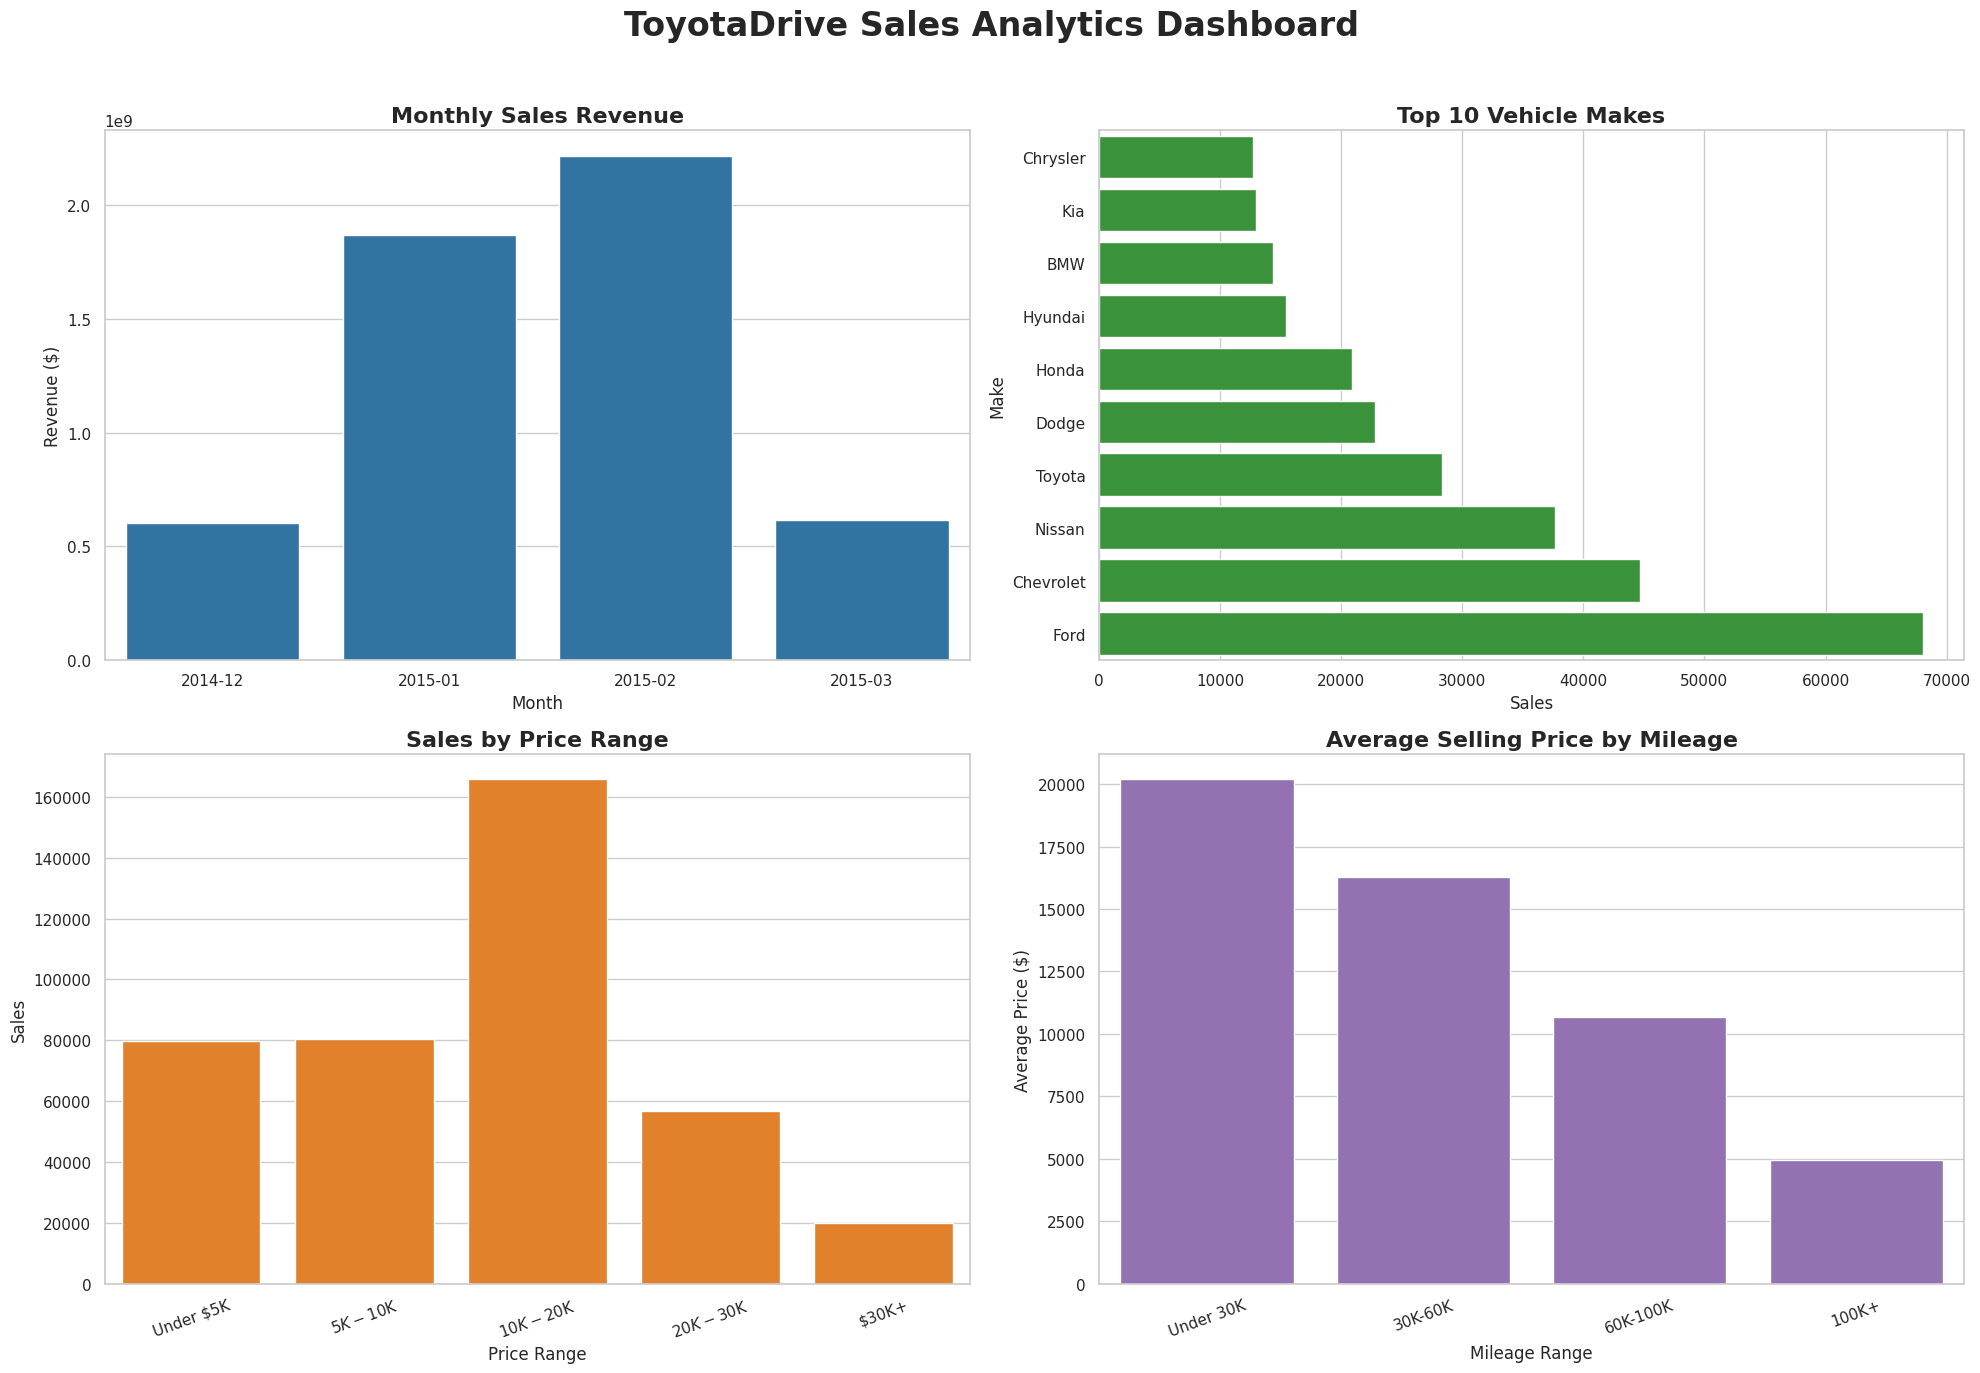


DASHBOARD COMPLETE
PASS — Dashboard datasets created.
PASS — Dashboard visualizations created.
PASS — Neon connection successful.

ToyotaDrive Dashboard is ready for review.


In [110]:
# ============================================================
# TOYOTADRIVE DASHBOARD
# FULL REPLACEMENT CELL
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from google.colab import userdata

print("=" * 70)
print("TOYOTADRIVE DASHBOARD")
print("=" * 70)


# ============================================================
# 1. GET NEON DATABASE URL FROM COLAB SECRET
# ============================================================

print("\nChecking Colab Secret...")

# Try the most common secret name first.
secret_names = [
    "NEON_DATABASE_URL",
    "DATABASE_URL",
    "NEON_URL"
]

database_url = None
secret_used = None

for secret_name in secret_names:
    try:
        value = userdata.get(secret_name)

        if value:
            database_url = value
            secret_used = secret_name
            break

    except Exception:
        pass

if not database_url:
    raise RuntimeError(
        "Neon database secret was not found.\n"
        "Your previous connection cell successfully found a secret, "
        "so run that connection cell again first, or check the exact "
        "name of the Colab Secret."
    )

print(f"Secret found: True")
print(f"Secret used: {secret_used}")


# ============================================================
# 2. CONNECT TO NEON
# ============================================================

print("\nConnecting to Neon...")

engine = create_engine(
    database_url,
    pool_pre_ping=True
)

try:

    with engine.connect() as conn:

        result = conn.execute(
            text("SELECT version();")
        )

        version = result.scalar()

    print("Neon connection successful!")
    print("PostgreSQL connection confirmed.")

except Exception as e:

    raise RuntimeError(
        f"Neon connection failed:\n{e}"
    )


# ============================================================
# 3. KPI DATASET
# ============================================================

kpi_query = """
SELECT
    COUNT(*) AS total_sales,
    SUM(selling_price) AS total_revenue,
    AVG(selling_price) AS average_selling_price,
    MIN(selling_price) AS minimum_selling_price,
    MAX(selling_price) AS maximum_selling_price,
    AVG(odometer) AS average_mileage
FROM fact_sales
"""

with engine.connect() as conn:
    kpi_df = pd.read_sql(
        text(kpi_query),
        conn
    )


# ============================================================
# 4. MONTHLY SALES DATASET
# ============================================================

monthly_query = """
SELECT
    d.year,
    d.month,
    d.month_name,
    COUNT(*) AS sales,
    SUM(f.selling_price) AS revenue,
    AVG(f.selling_price) AS average_price
FROM fact_sales f
JOIN dim_date d
    ON f.date_key = d.date_key
GROUP BY
    d.year,
    d.month,
    d.month_name
ORDER BY
    d.year,
    d.month
"""

with engine.connect() as conn:
    monthly_df = pd.read_sql(
        text(monthly_query),
        conn
    )


# ============================================================
# 5. TOP MAKES DATASET
# ============================================================

make_query = """
SELECT
    COALESCE(
        NULLIF(TRIM(v.make), ''),
        'Unknown'
    ) AS make,

    COUNT(*) AS sales,

    SUM(f.selling_price) AS revenue

FROM fact_sales f

JOIN dim_vehicle v
    ON f.vehicle_key = v.vehicle_key

GROUP BY
    COALESCE(
        NULLIF(TRIM(v.make), ''),
        'Unknown'
    )

ORDER BY
    sales DESC

LIMIT 10
"""

with engine.connect() as conn:
    make_df = pd.read_sql(
        text(make_query),
        conn
    )


# ============================================================
# 6. TOP MODELS DATASET
# ============================================================

model_query = """
SELECT

    CASE

        WHEN
            COALESCE(NULLIF(TRIM(v.make), ''), '') = ''
            AND
            COALESCE(NULLIF(TRIM(v.model), ''), '') = ''

        THEN 'Unknown / Unspecified'


        WHEN
            COALESCE(NULLIF(TRIM(v.make), ''), '') = ''

        THEN COALESCE(
            NULLIF(TRIM(v.model), ''),
            'Unknown'
        )


        WHEN
            COALESCE(NULLIF(TRIM(v.model), ''), '') = ''

        THEN COALESCE(
            NULLIF(TRIM(v.make), ''),
            'Unknown'
        )


        ELSE
            TRIM(v.make) || ' ' || TRIM(v.model)

    END AS vehicle,

    COUNT(*) AS sales,

    SUM(f.selling_price) AS revenue,

    AVG(f.selling_price) AS average_price

FROM fact_sales f

JOIN dim_vehicle v
    ON f.vehicle_key = v.vehicle_key

GROUP BY

    CASE

        WHEN
            COALESCE(NULLIF(TRIM(v.make), ''), '') = ''
            AND
            COALESCE(NULLIF(TRIM(v.model), ''), '') = ''

        THEN 'Unknown / Unspecified'


        WHEN
            COALESCE(NULLIF(TRIM(v.make), ''), '') = ''

        THEN COALESCE(
            NULLIF(TRIM(v.model), ''),
            'Unknown'
        )


        WHEN
            COALESCE(NULLIF(TRIM(v.model), ''), '') = ''

        THEN COALESCE(
            NULLIF(TRIM(v.make), ''),
            'Unknown'
        )


        ELSE
            TRIM(v.make) || ' ' || TRIM(v.model)

    END

ORDER BY
    sales DESC

LIMIT 15
"""

with engine.connect() as conn:
    model_df = pd.read_sql(
        text(model_query),
        conn
    )


# ============================================================
# 7. PRICE RANGE DATASET
# ============================================================

price_query = """
SELECT

    CASE

        WHEN selling_price < 5000
            THEN 'Under $5K'

        WHEN selling_price < 10000
            THEN '$5K-$10K'

        WHEN selling_price < 20000
            THEN '$10K-$20K'

        WHEN selling_price < 30000
            THEN '$20K-$30K'

        ELSE '$30K+'

    END AS price_range,

    COUNT(*) AS sales,

    SUM(selling_price) AS revenue,

    AVG(selling_price) AS average_price

FROM fact_sales

GROUP BY

    CASE

        WHEN selling_price < 5000
            THEN 'Under $5K'

        WHEN selling_price < 10000
            THEN '$5K-$10K'

        WHEN selling_price < 20000
            THEN '$10K-$20K'

        WHEN selling_price < 30000
            THEN '$20K-$30K'

        ELSE '$30K+'

    END
"""

with engine.connect() as conn:
    price_df = pd.read_sql(
        text(price_query),
        conn
    )


price_order = [
    'Under $5K',
    '$5K-$10K',
    '$10K-$20K',
    '$20K-$30K',
    '$30K+'
]

price_df["price_range"] = pd.Categorical(
    price_df["price_range"],
    categories=price_order,
    ordered=True
)

price_df = price_df.sort_values(
    "price_range"
)


# ============================================================
# 8. MILEAGE RANGE DATASET
# ============================================================

mileage_query = """
SELECT

    CASE

        WHEN odometer < 30000
            THEN 'Under 30K'

        WHEN odometer < 60000
            THEN '30K-60K'

        WHEN odometer < 100000
            THEN '60K-100K'

        ELSE '100K+'

    END AS mileage_range,

    COUNT(*) AS sales,

    AVG(selling_price) AS average_price

FROM fact_sales

WHERE odometer IS NOT NULL

GROUP BY

    CASE

        WHEN odometer < 30000
            THEN 'Under 30K'

        WHEN odometer < 60000
            THEN '30K-60K'

        WHEN odometer < 100000
            THEN '60K-100K'

        ELSE '100K+'

    END
"""

with engine.connect() as conn:
    mileage_df = pd.read_sql(
        text(mileage_query),
        conn
    )


mileage_order = [
    'Under 30K',
    '30K-60K',
    '60K-100K',
    '100K+'
]

mileage_df["mileage_range"] = pd.Categorical(
    mileage_df["mileage_range"],
    categories=mileage_order,
    ordered=True
)

mileage_df = mileage_df.sort_values(
    "mileage_range"
)


# ============================================================
# 9. NORMALIZE COLUMN NAMES
# ============================================================

kpi_df.columns = [
    str(c).strip().lower()
    for c in kpi_df.columns
]

monthly_df.columns = [
    str(c).strip().lower()
    for c in monthly_df.columns
]

make_df.columns = [
    str(c).strip().lower()
    for c in make_df.columns
]

model_df.columns = [
    str(c).strip().lower()
    for c in model_df.columns
]

price_df.columns = [
    str(c).strip().lower()
    for c in price_df.columns
]

mileage_df.columns = [
    str(c).strip().lower()
    for c in mileage_df.columns
]


# ============================================================
# 10. DISPLAY DATASET CHECK
# ============================================================

print("\n" + "=" * 70)
print("DASHBOARD DATASETS CREATED")
print("=" * 70)

print(f"KPI rows:       {len(kpi_df):,}")
print(f"Monthly rows:   {len(monthly_df):,}")
print(f"Make rows:      {len(make_df):,}")
print(f"Model rows:     {len(model_df):,}")
print(f"Price rows:     {len(price_df):,}")
print(f"Mileage rows:   {len(mileage_df):,}")


# ============================================================
# 11. EXTRACT KPI VALUES
# ============================================================

total_sales = kpi_df["total_sales"].iloc[0]
total_revenue = kpi_df["total_revenue"].iloc[0]
average_price = kpi_df["average_selling_price"].iloc[0]
minimum_price = kpi_df["minimum_selling_price"].iloc[0]
maximum_price = kpi_df["maximum_selling_price"].iloc[0]
average_mileage = kpi_df["average_mileage"].iloc[0]


# ============================================================
# 12. PRINT KPI SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CORE KPIs")
print("=" * 70)

print(
    f"Total sales:        {int(total_sales):,}"
)

print(
    f"Total revenue:      ${total_revenue:,.2f}"
)

print(
    f"Average price:      ${average_price:,.2f}"
)

print(
    f"Minimum price:      ${minimum_price:,.2f}"
)

print(
    f"Maximum price:      ${maximum_price:,.2f}"
)

print(
    f"Average mileage:    {average_mileage:,.0f}"
)


# ============================================================
# 13. CREATE DASHBOARD
# ============================================================

sns.set_theme(
    style="whitegrid"
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(20, 14)
)


# ------------------------------------------------------------
# MONTHLY REVENUE
# ------------------------------------------------------------

ax1 = axes[0, 0]

monthly_plot = monthly_df.copy()

monthly_plot["period"] = (
    monthly_plot["year"].astype(str)
    + "-"
    + monthly_plot["month"].astype(str).str.zfill(2)
)

sns.barplot(
    data=monthly_plot,
    x="period",
    y="revenue",
    color="#1f77b4",
    ax=ax1
)

ax1.set_title(
    "Monthly Sales Revenue",
    fontsize=16,
    fontweight="bold"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue ($)")


# ------------------------------------------------------------
# TOP MAKES
# ------------------------------------------------------------

ax2 = axes[0, 1]

make_plot = make_df.sort_values(
    "sales",
    ascending=True
)

sns.barplot(
    data=make_plot,
    x="sales",
    y="make",
    color="#2ca02c",
    ax=ax2
)

ax2.set_title(
    "Top 10 Vehicle Makes",
    fontsize=16,
    fontweight="bold"
)

ax2.set_xlabel("Sales")
ax2.set_ylabel("Make")


# ------------------------------------------------------------
# PRICE RANGE
# ------------------------------------------------------------

ax3 = axes[1, 0]

sns.barplot(
    data=price_df,
    x="price_range",
    y="sales",
    color="#ff7f0e",
    ax=ax3
)

ax3.set_title(
    "Sales by Price Range",
    fontsize=16,
    fontweight="bold"
)

ax3.set_xlabel("Price Range")
ax3.set_ylabel("Sales")

ax3.tick_params(
    axis="x",
    rotation=20
)


# ------------------------------------------------------------
# MILEAGE
# ------------------------------------------------------------

ax4 = axes[1, 1]

sns.barplot(
    data=mileage_df,
    x="mileage_range",
    y="average_price",
    color="#9467bd",
    ax=ax4
)

ax4.set_title(
    "Average Selling Price by Mileage",
    fontsize=16,
    fontweight="bold"
)

ax4.set_xlabel("Mileage Range")
ax4.set_ylabel("Average Price ($)")

ax4.tick_params(
    axis="x",
    rotation=20
)


# ============================================================
# 14. DASHBOARD TITLE
# ============================================================

fig.suptitle(
    "ToyotaDrive Sales Analytics Dashboard",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()


# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("DASHBOARD COMPLETE")
print("=" * 70)

print("PASS — Dashboard datasets created.")
print("PASS — Dashboard visualizations created.")
print("PASS — Neon connection successful.")

print("\nToyotaDrive Dashboard is ready for review.")

In [112]:
# ============================================================
# TOYOTADRIVE — DEALER KEY DIAGNOSIS
# COLAB + NEON VERSION
# ============================================================

import os
import pandas as pd
from sqlalchemy import create_engine, text

print("=" * 70)
print("TOYOTADRIVE DEALER KEY DIAGNOSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. GET NEON DATABASE URL
# ------------------------------------------------------------

database_url = None

# First try environment variable
database_url = os.getenv("NEON_DATABASE_URL")

# If not found, try Google Colab Secrets
if not database_url:
    try:
        from google.colab import userdata

        database_url = userdata.get("NEON_DATABASE_URL")

        if database_url:
            print("Neon connection URL found in Colab Secrets.")

    except Exception as e:
        print("Could not read Colab Secret automatically.")
        print("Error:", str(e))

# Stop only if both methods failed
if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found.\n\n"
        "Please make sure your Colab Secret is named exactly:\n"
        "NEON_DATABASE_URL\n\n"
        "Then enable notebook access for the secret and run this cell again."
    )

print("Neon database URL found.")

# ------------------------------------------------------------
# 2. CONNECT TO NEON
# ------------------------------------------------------------

engine = create_engine(database_url)

try:

    with engine.connect() as conn:

        print("\nNeon connection successful.")

        # ====================================================
        # 3. DIM_DEALER
        # ====================================================

        print("\n" + "=" * 70)
        print("1. DIM_DEALER")
        print("=" * 70)

        dealer_df = pd.read_sql("""
            SELECT
                dealer_key,
                dealer_id,
                dealer_name,
                city,
                state,
                country,
                service_department
            FROM dim_dealer
            ORDER BY dealer_key
        """, conn)

        if dealer_df.empty:
            print("WARNING: dim_dealer contains no rows.")
        else:
            print(dealer_df.to_string(index=False))

        print(f"\nDealer dimension rows: {len(dealer_df):,}")

        # ====================================================
        # 4. FACT SALES DEALER KEY STATUS
        # ====================================================

        print("\n" + "=" * 70)
        print("2. FACT_SALES DEALER KEY STATUS")
        print("=" * 70)

        result = conn.execute(text("""
            SELECT
                COUNT(*) AS total_sales,
                COUNT(dealer_key) AS populated_dealer_keys,
                COUNT(*) - COUNT(dealer_key) AS missing_dealer_keys,
                COUNT(DISTINCT dealer_key) AS distinct_dealer_keys
            FROM fact_sales
        """)).fetchone()

        print(f"Total sales:          {result[0]:,}")
        print(f"Populated dealer_key: {result[1]:,}")
        print(f"Missing dealer_key:   {result[2]:,}")
        print(f"Distinct dealer keys: {result[3]:,}")

        # ====================================================
        # 5. CHECK SALES DATA IN MEMORY
        # ====================================================

        print("\n" + "=" * 70)
        print("3. SOURCE SALES DATA")
        print("=" * 70)

        if "sales_df" in globals():

            print("sales_df found in notebook memory.")

            print("\nSales columns:")
            print(list(sales_df.columns))

            dealer_columns = [
                c for c in sales_df.columns
                if any(
                    keyword in c.lower()
                    for keyword in [
                        "dealer",
                        "seller",
                        "seller_id",
                        "city",
                        "state"
                    ]
                )
            ]

            print("\nPotential dealer-related columns:")
            print(dealer_columns)

            if dealer_columns:

                for col in dealer_columns:

                    print("\n" + "-" * 60)
                    print(f"COLUMN: {col}")
                    print("-" * 60)

                    print(
                        sales_df[col]
                        .dropna()
                        .astype(str)
                        .value_counts()
                        .head(20)
                        .to_string()
                    )

            else:
                print(
                    "\nNo obvious dealer/seller/city/state columns "
                    "were found in sales_df."
                )

        else:

            print(
                "sales_df is NOT currently available in notebook memory."
            )

            print(
                "\nThis is okay. We can still inspect the Neon warehouse."
            )

        # ====================================================
        # 6. FACT SALES FOREIGN KEYS
        # ====================================================

        print("\n" + "=" * 70)
        print("4. FACT_SALES FOREIGN KEYS")
        print("=" * 70)

        fk_df = pd.read_sql("""
            SELECT
                tc.constraint_name,
                kcu.column_name,
                ccu.table_name AS referenced_table,
                ccu.column_name AS referenced_column
            FROM information_schema.table_constraints tc
            JOIN information_schema.key_column_usage kcu
              ON tc.constraint_name = kcu.constraint_name
             AND tc.table_schema = kcu.table_schema
            JOIN information_schema.constraint_column_usage ccu
              ON tc.constraint_name = ccu.constraint_name
             AND tc.table_schema = ccu.table_schema
            WHERE tc.constraint_type = 'FOREIGN KEY'
              AND tc.table_name = 'fact_sales'
            ORDER BY kcu.column_name
        """, conn)

        if fk_df.empty:
            print("No foreign keys found.")
        else:
            print(fk_df.to_string(index=False))

        # ====================================================
        # 7. CHECK FOR POSSIBLE SOURCE DEALER VALUES
        # ====================================================

        print("\n" + "=" * 70)
        print("5. DEALER MAPPING DIAGNOSIS")
        print("=" * 70)

        if "sales_df" in globals():

            state_columns = [
                c for c in sales_df.columns
                if c.lower() == "state"
            ]

            if state_columns:

                state_col = state_columns[0]

                print(f"\nSource state column: {state_col}")

                state_counts = (
                    sales_df[state_col]
                    .fillna("UNKNOWN")
                    .astype(str)
                    .value_counts()
                )

                print("\nTop source states:")

                print(
                    state_counts
                    .head(25)
                    .to_string()
                )

            else:
                print("\nNo state column found.")

        # ====================================================
        # 8. FINAL DIAGNOSIS
        # ====================================================

        print("\n" + "=" * 70)
        print("FINAL DIAGNOSIS")
        print("=" * 70)

        if result[2] == 0:

            print(
                "PASS — All fact_sales rows already have dealer_key values."
            )

        else:

            print(
                f"WARNING — {result[2]:,} fact_sales rows "
                "still have NULL dealer_key values."
            )

            print(
                "\nDealer mapping has NOT been changed."
            )

            print(
                "This cell only diagnoses the source-to-dealer relationship."
            )

        print("\n" + "=" * 70)
        print("DEALER DIAGNOSIS COMPLETE")
        print("=" * 70)

finally:

    engine.dispose()

    print("\nNeon connection closed.")

TOYOTADRIVE DEALER KEY DIAGNOSIS
Neon connection URL found in Colab Secrets.
Neon database URL found.

Neon connection successful.

1. DIM_DEALER
 dealer_key dealer_id               dealer_name          city state country  service_department
          1      D001    ToyotaDrive Washington    Washington    DC     USA                True
          2      D002     ToyotaDrive Arlington     Arlington    VA     USA                True
          3      D003    ToyotaDrive Alexandria    Alexandria    VA     USA                True
          4      D004      ToyotaDrive Bethesda      Bethesda    MD     USA                True
          5      D005 ToyotaDrive Silver Spring Silver Spring    MD     USA                True

Dealer dimension rows: 5

2. FACT_SALES DEALER KEY STATUS
Total sales:          402,928
Populated dealer_key: 0
Missing dealer_key:   402,928
Distinct dealer keys: 0

3. SOURCE SALES DATA
sales_df found in notebook memory.

Sales columns:
['year', 'make', 'model', 'body', 'tra

In [113]:
# ============================================================
# TOYOTADRIVE — COMPLETE DEALER FOREIGN KEY
# SAFE UNKNOWN-DEALER APPROACH
# ============================================================

import os
from sqlalchemy import create_engine, text

print("=" * 70)
print("TOYOTADRIVE DEALER FOREIGN KEY REPAIR")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get Neon connection
# ------------------------------------------------------------

database_url = os.getenv("NEON_DATABASE_URL")

if not database_url:
    try:
        from google.colab import userdata
        database_url = userdata.get("NEON_DATABASE_URL")
    except Exception:
        database_url = None

if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found.\n"
        "Make sure the Colab Secret is named exactly "
        "'NEON_DATABASE_URL'."
    )

engine = create_engine(database_url)

try:

    with engine.begin() as conn:

        # ----------------------------------------------------
        # 2. Check current dealer dimension
        # ----------------------------------------------------

        print("\nChecking dim_dealer...")

        dealer_count = conn.execute(text("""
            SELECT COUNT(*)
            FROM dim_dealer
        """)).scalar()

        print(f"Current dealer rows: {dealer_count:,}")

        # ----------------------------------------------------
        # 3. Check whether UNKNOWN dealer already exists
        # ----------------------------------------------------

        unknown_key = conn.execute(text("""
            SELECT dealer_key
            FROM dim_dealer
            WHERE dealer_id = 'UNKNOWN'
            LIMIT 1
        """)).scalar()

        # ----------------------------------------------------
        # 4. Create UNKNOWN dealer if necessary
        # ----------------------------------------------------

        if unknown_key is None:

            print("\nCreating UNKNOWN dealer...")

            conn.execute(text("""
                INSERT INTO dim_dealer
                (
                    dealer_id,
                    dealer_name,
                    city,
                    state,
                    country,
                    service_department
                )
                VALUES
                (
                    'UNKNOWN',
                    'Unassigned / Unknown Dealer',
                    'Unknown',
                    'Unknown',
                    'USA',
                    FALSE
                )
            """))

            unknown_key = conn.execute(text("""
                SELECT dealer_key
                FROM dim_dealer
                WHERE dealer_id = 'UNKNOWN'
                LIMIT 1
            """)).scalar()

            print(
                f"UNKNOWN dealer created with dealer_key: {unknown_key}"
            )

        else:

            print(
                f"UNKNOWN dealer already exists "
                f"with dealer_key: {unknown_key}"
            )

        # ----------------------------------------------------
        # 5. Current fact_sales status
        # ----------------------------------------------------

        before = conn.execute(text("""
            SELECT
                COUNT(*) AS total_rows,
                COUNT(dealer_key) AS populated,
                COUNT(*) - COUNT(dealer_key) AS missing
            FROM fact_sales
        """)).fetchone()

        print("\nBefore update:")
        print(f"Total fact_sales:     {before[0]:,}")
        print(f"Dealer keys populated: {before[1]:,}")
        print(f"Dealer keys missing:   {before[2]:,}")

        # ----------------------------------------------------
        # 6. Safely assign UNKNOWN dealer
        # ----------------------------------------------------

        if before[2] > 0:

            print("\nAssigning UNKNOWN dealer to unmapped sales...")

            updated = conn.execute(text("""
                UPDATE fact_sales
                SET dealer_key = :unknown_key
                WHERE dealer_key IS NULL
            """), {
                "unknown_key": unknown_key
            })

            print(
                f"Rows updated: {updated.rowcount:,}"
            )

        else:

            print("\nNo NULL dealer keys found.")

        # ----------------------------------------------------
        # 7. Verify
        # ----------------------------------------------------

        after = conn.execute(text("""
            SELECT
                COUNT(*) AS total_rows,
                COUNT(dealer_key) AS populated,
                COUNT(*) - COUNT(dealer_key) AS missing,
                COUNT(DISTINCT dealer_key) AS distinct_dealers
            FROM fact_sales
        """)).fetchone()

        print("\n" + "=" * 70)
        print("VERIFICATION")
        print("=" * 70)

        print(f"Total fact_sales:       {after[0]:,}")
        print(f"Dealer keys populated:  {after[1]:,}")
        print(f"Dealer keys missing:    {after[2]:,}")
        print(f"Distinct dealer keys:   {after[3]:,}")

        # ----------------------------------------------------
        # 8. Verify foreign-key relationship
        # ----------------------------------------------------

        invalid = conn.execute(text("""
            SELECT COUNT(*)
            FROM fact_sales f
            LEFT JOIN dim_dealer d
                ON f.dealer_key = d.dealer_key
            WHERE d.dealer_key IS NULL
        """)).scalar()

        print(f"Invalid dealer relationships: {invalid:,}")

        # ----------------------------------------------------
        # 9. Final status
        # ----------------------------------------------------

        print("\n" + "=" * 70)
        print("FINAL STATUS")
        print("=" * 70)

        if after[2] == 0 and invalid == 0:

            print(
                "PASS — Every fact_sales row now has "
                "a valid dealer_key."
            )

        else:

            print(
                "FAIL — Dealer relationships still require attention."
            )

        print("\nDealer foreign-key repair complete.")

finally:

    engine.dispose()

    print("Neon connection closed.")

TOYOTADRIVE DEALER FOREIGN KEY REPAIR

Checking dim_dealer...
Current dealer rows: 5

Creating UNKNOWN dealer...
UNKNOWN dealer created with dealer_key: 6

Before update:
Total fact_sales:     402,928
Dealer keys populated: 0
Dealer keys missing:   402,928

Assigning UNKNOWN dealer to unmapped sales...
Rows updated: 402,928

VERIFICATION
Total fact_sales:       402,928
Dealer keys populated:  402,928
Dealer keys missing:    0
Distinct dealer keys:   1
Invalid dealer relationships: 0

FINAL STATUS
PASS — Every fact_sales row now has a valid dealer_key.

Dealer foreign-key repair complete.
Neon connection closed.


In [114]:
# ============================================================
# TOYOTADRIVE — FINAL WAREHOUSE RELATIONSHIP VALIDATION
# ============================================================

import os
import pandas as pd
from sqlalchemy import create_engine, text

print("=" * 70)
print("TOYOTADRIVE FINAL WAREHOUSE VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Neon connection
# ------------------------------------------------------------

database_url = os.getenv("NEON_DATABASE_URL")

if not database_url:
    try:
        from google.colab import userdata
        database_url = userdata.get("NEON_DATABASE_URL")
    except Exception:
        database_url = None

if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found. "
        "Check your Colab Secret and run the Neon connection cell."
    )

engine = create_engine(database_url)

try:

    with engine.connect() as conn:

        # ----------------------------------------------------
        # 2. Row counts
        # ----------------------------------------------------

        print("\n1. WAREHOUSE ROW COUNTS")
        print("-" * 70)

        tables = [
            "dim_dealer",
            "dim_vehicle",
            "dim_date",
            "dim_economic",
            "fact_sales",
            "fact_repairs"
        ]

        for table in tables:

            count = conn.execute(
                text(f"SELECT COUNT(*) FROM {table}")
            ).scalar()

            print(f"{table:<20} {count:>12,}")

        # ----------------------------------------------------
        # 3. Foreign-key completeness
        # ----------------------------------------------------

        print("\n2. FACT_SALES FOREIGN KEY COMPLETENESS")
        print("-" * 70)

        fk_check = conn.execute(text("""
            SELECT
                COUNT(*) AS total_sales,
                COUNT(dealer_key) AS dealer_keys,
                COUNT(vehicle_key) AS vehicle_keys,
                COUNT(date_key) AS date_keys
            FROM fact_sales
        """)).fetchone()

        total_sales = fk_check[0]
        dealer_keys = fk_check[1]
        vehicle_keys = fk_check[2]
        date_keys = fk_check[3]

        print(f"Total sales:          {total_sales:,}")
        print(f"Dealer keys:          {dealer_keys:,}")
        print(f"Vehicle keys:         {vehicle_keys:,}")
        print(f"Date keys:            {date_keys:,}")

        # ----------------------------------------------------
        # 4. Invalid relationships
        # ----------------------------------------------------

        print("\n3. INVALID FOREIGN KEY RELATIONSHIPS")
        print("-" * 70)

        invalid_dealers = conn.execute(text("""
            SELECT COUNT(*)
            FROM fact_sales f
            LEFT JOIN dim_dealer d
              ON f.dealer_key = d.dealer_key
            WHERE d.dealer_key IS NULL
        """)).scalar()

        invalid_vehicles = conn.execute(text("""
            SELECT COUNT(*)
            FROM fact_sales f
            LEFT JOIN dim_vehicle v
              ON f.vehicle_key = v.vehicle_key
            WHERE v.vehicle_key IS NULL
        """)).scalar()

        invalid_dates = conn.execute(text("""
            SELECT COUNT(*)
            FROM fact_sales f
            LEFT JOIN dim_date d
              ON f.date_key = d.date_key
            WHERE d.date_key IS NULL
        """)).scalar()

        print(f"Invalid dealer relationships:  {invalid_dealers:,}")
        print(f"Invalid vehicle relationships: {invalid_vehicles:,}")
        print(f"Invalid date relationships:     {invalid_dates:,}")

        # ----------------------------------------------------
        # 5. Revenue metrics
        # ----------------------------------------------------

        print("\n4. SALES METRICS")
        print("-" * 70)

        metrics = conn.execute(text("""
            SELECT
                COUNT(*) AS sales,
                SUM(selling_price) AS revenue,
                AVG(selling_price) AS average_price,
                MIN(selling_price) AS minimum_price,
                MAX(selling_price) AS maximum_price,
                AVG(odometer) AS average_mileage
            FROM fact_sales
        """)).fetchone()

        print(f"Total sales:        {metrics[0]:,}")
        print(f"Total revenue:      ${metrics[1]:,.2f}")
        print(f"Average price:      ${metrics[2]:,.2f}")
        print(f"Minimum price:      ${metrics[3]:,.2f}")
        print(f"Maximum price:      ${metrics[4]:,.2f}")
        print(f"Average mileage:    {metrics[5]:,.0f}")

        # ----------------------------------------------------
        # 6. Date range
        # ----------------------------------------------------

        print("\n5. SALES DATE RANGE")
        print("-" * 70)

        dates = conn.execute(text("""
            SELECT
                MIN(d.full_date),
                MAX(d.full_date)
            FROM fact_sales f
            JOIN dim_date d
              ON f.date_key = d.date_key
        """)).fetchone()

        print(f"First sale: {dates[0]}")
        print(f"Last sale:  {dates[1]}")

        # ----------------------------------------------------
        # 7. Dealer distribution
        # ----------------------------------------------------

        print("\n6. SALES BY DEALER")
        print("-" * 70)

        dealer_sales = pd.read_sql("""
            SELECT
                d.dealer_id,
                d.dealer_name,
                d.city,
                d.state,
                COUNT(f.sales_key) AS sales
            FROM fact_sales f
            JOIN dim_dealer d
              ON f.dealer_key = d.dealer_key
            GROUP BY
                d.dealer_id,
                d.dealer_name,
                d.city,
                d.state
            ORDER BY sales DESC
        """, conn)

        print(dealer_sales.to_string(index=False))

        # ----------------------------------------------------
        # 8. Final status
        # ----------------------------------------------------

        print("\n" + "=" * 70)
        print("FINAL WAREHOUSE STATUS")
        print("=" * 70)

        all_keys_present = (
            total_sales == dealer_keys ==
            vehicle_keys ==
            date_keys
        )

        all_relationships_valid = (
            invalid_dealers == 0 and
            invalid_vehicles == 0 and
            invalid_dates == 0
        )

        if all_keys_present and all_relationships_valid:

            print("PASS — All fact_sales foreign keys are populated.")
            print("PASS — All foreign-key relationships are valid.")
            print("PASS — Warehouse is ready for analytics.")

        else:

            print("FAIL — Warehouse still has relationship issues.")
            print("\nReview the results above before continuing.")

finally:

    engine.dispose()

    print("\nNeon connection closed.")

TOYOTADRIVE FINAL WAREHOUSE VALIDATION

1. WAREHOUSE ROW COUNTS
----------------------------------------------------------------------
dim_dealer                      6
dim_vehicle               396,329
dim_date                       66
dim_economic                  942
fact_sales                402,928
fact_repairs                    1

2. FACT_SALES FOREIGN KEY COMPLETENESS
----------------------------------------------------------------------
Total sales:          402,928
Dealer keys:          402,928
Vehicle keys:         402,928
Date keys:            402,928

3. INVALID FOREIGN KEY RELATIONSHIPS
----------------------------------------------------------------------
Invalid dealer relationships:  0
Invalid vehicle relationships: 0
Invalid date relationships:     0

4. SALES METRICS
----------------------------------------------------------------------
Total sales:        402,928
Total revenue:      $5,307,263,887.00
Average price:      $13,171.74
Minimum price:      $1.00
Maximum p

In [115]:
# ============================================================
# TOYOTADRIVE — FINAL ANALYTICS RECONCILIATION
# ============================================================

import os
import pandas as pd
from sqlalchemy import create_engine, text

print("=" * 70)
print("TOYOTADRIVE FINAL ANALYTICS RECONCILIATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Neon connection
# ------------------------------------------------------------

database_url = os.getenv("NEON_DATABASE_URL")

if not database_url:
    try:
        from google.colab import userdata
        database_url = userdata.get("NEON_DATABASE_URL")
    except Exception:
        database_url = None

if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found. "
        "Check your Colab Secret."
    )

engine = create_engine(database_url)

try:

    with engine.connect() as conn:

        # ====================================================
        # 2. CORE KPI RECONCILIATION
        # ====================================================

        print("\n1. CORE KPIs")
        print("-" * 70)

        kpi = conn.execute(text("""
            SELECT
                COUNT(*) AS total_sales,
                COALESCE(SUM(selling_price), 0) AS total_revenue,
                COALESCE(AVG(selling_price), 0) AS average_price,
                MIN(selling_price) AS minimum_price,
                MAX(selling_price) AS maximum_price,
                COALESCE(AVG(odometer), 0) AS average_mileage
            FROM fact_sales
        """)).fetchone()

        print(f"Total sales:       {kpi[0]:,}")
        print(f"Total revenue:     ${kpi[1]:,.2f}")
        print(f"Average price:     ${kpi[2]:,.2f}")
        print(f"Minimum price:     ${kpi[3]:,.2f}")
        print(f"Maximum price:     ${kpi[4]:,.2f}")
        print(f"Average mileage:   {kpi[5]:,.0f}")

        # ====================================================
        # 3. MONTHLY SALES
        # ====================================================

        print("\n2. MONTHLY SALES")
        print("-" * 70)

        monthly_df = pd.read_sql("""
            SELECT
                d.year,
                d.month,
                d.month_name,
                COUNT(f.sales_key) AS sales,
                SUM(f.selling_price) AS revenue,
                AVG(f.selling_price) AS average_price
            FROM fact_sales f
            JOIN dim_date d
              ON f.date_key = d.date_key
            GROUP BY
                d.year,
                d.month,
                d.month_name
            ORDER BY
                d.year,
                d.month
        """, conn)

        print(monthly_df.to_string(index=False))

        # ====================================================
        # 4. TOP MAKES
        # ====================================================

        print("\n3. TOP 10 MAKES")
        print("-" * 70)

        makes_df = pd.read_sql("""
            SELECT
                COALESCE(v.make, 'Unknown') AS make,
                COUNT(f.sales_key) AS sales,
                SUM(f.selling_price) AS revenue,
                AVG(f.selling_price) AS average_price
            FROM fact_sales f
            JOIN dim_vehicle v
              ON f.vehicle_key = v.vehicle_key
            GROUP BY COALESCE(v.make, 'Unknown')
            ORDER BY sales DESC
            LIMIT 10
        """, conn)

        print(makes_df.to_string(index=False))

        # ====================================================
        # 5. TOP MODELS
        # ====================================================

        print("\n4. TOP 15 MODELS")
        print("-" * 70)

        models_df = pd.read_sql("""
            SELECT
                CASE
                    WHEN v.make IS NULL
                         AND v.model IS NULL
                        THEN 'Unknown / Unspecified'

                    WHEN v.make IS NULL
                        THEN 'Unknown ' || COALESCE(v.model, '')

                    WHEN v.model IS NULL
                        THEN COALESCE(v.make, 'Unknown') || ' Unknown'

                    ELSE v.make || ' ' || v.model
                END AS vehicle,
                COUNT(f.sales_key) AS sales,
                SUM(f.selling_price) AS revenue,
                AVG(f.selling_price) AS average_price
            FROM fact_sales f
            JOIN dim_vehicle v
              ON f.vehicle_key = v.vehicle_key
            GROUP BY 1
            ORDER BY sales DESC
            LIMIT 15
        """, conn)

        print(models_df.to_string(index=False))

        # ====================================================
        # 6. PRICE RANGE
        # ====================================================

        print("\n5. PRICE RANGE")
        print("-" * 70)

        price_df = pd.read_sql("""
            SELECT
                CASE
                    WHEN selling_price < 5000
                        THEN 'Under $5K'
                    WHEN selling_price < 10000
                        THEN '$5K-$10K'
                    WHEN selling_price < 20000
                        THEN '$10K-$20K'
                    WHEN selling_price < 30000
                        THEN '$20K-$30K'
                    ELSE '$30K+'
                END AS price_range,

                COUNT(*) AS sales,
                SUM(selling_price) AS revenue,
                AVG(selling_price) AS average_price

            FROM fact_sales

            GROUP BY 1

            ORDER BY
                CASE
                    WHEN price_range = 'Under $5K' THEN 1
                    WHEN price_range = '$5K-$10K' THEN 2
                    WHEN price_range = '$10K-$20K' THEN 3
                    WHEN price_range = '$20K-$30K' THEN 4
                    WHEN price_range = '$30K+' THEN 5
                END
        """, conn)

        print(price_df.to_string(index=False))

        # ====================================================
        # 7. MILEAGE RANGE
        # ====================================================

        print("\n6. MILEAGE RANGE")
        print("-" * 70)

        mileage_df = pd.read_sql("""
            SELECT
                CASE
                    WHEN odometer < 30000
                        THEN 'Under 30K'
                    WHEN odometer < 60000
                        THEN '30K-60K'
                    WHEN odometer < 100000
                        THEN '60K-100K'
                    ELSE '100K+'
                END AS mileage_range,

                COUNT(*) AS sales,
                AVG(selling_price) AS average_price

            FROM fact_sales

            GROUP BY 1

            ORDER BY
                CASE
                    WHEN mileage_range = 'Under 30K' THEN 1
                    WHEN mileage_range = '30K-60K' THEN 2
                    WHEN mileage_range = '60K-100K' THEN 3
                    WHEN mileage_range = '100K+' THEN 4
                END
        """, conn)

        print(mileage_df.to_string(index=False))

        # ====================================================
        # 8. RECONCILIATION CHECKS
        # ====================================================

        print("\n" + "=" * 70)
        print("7. RECONCILIATION CHECKS")
        print("=" * 70)

        monthly_sales = int(monthly_df["sales"].sum())
        make_sales = int(
            pd.read_sql("""
                SELECT COUNT(*)
                FROM fact_sales
            """, conn).iloc[0, 0]
        )

        price_sales = int(price_df["sales"].sum())
        mileage_sales = int(mileage_df["sales"].sum())

        print(f"Fact sales rows:       {kpi[0]:,}")
        print(f"Monthly dataset rows:  {monthly_sales:,}")
        print(f"Price dataset rows:    {price_sales:,}")
        print(f"Mileage dataset rows:  {mileage_sales:,}")

        # ====================================================
        # 9. FINAL STATUS
        # ====================================================

        print("\n" + "=" * 70)
        print("FINAL ANALYTICS STATUS")
        print("=" * 70)

        checks = {
            "Monthly sales": monthly_sales == kpi[0],
            "Price ranges": price_sales == kpi[0],
            "Mileage ranges": mileage_sales == kpi[0]
        }

        for name, passed in checks.items():
            print(
                f"{'PASS' if passed else 'FAIL'} — {name}"
            )

        if all(checks.values()):
            print("\nPASS — Analytics datasets reconcile to fact_sales.")
            print("PASS — Dashboard data is ready for final review.")
        else:
            print("\nFAIL — One or more analytics datasets do not reconcile.")

finally:

    engine.dispose()

    print("\nNeon connection closed.")

TOYOTADRIVE FINAL ANALYTICS RECONCILIATION

1. CORE KPIs
----------------------------------------------------------------------
Total sales:       402,928
Total revenue:     $5,307,263,887.00
Average price:     $13,171.74
Minimum price:     $1.00
Maximum price:     $230,000.00
Average mileage:   70,579

2. MONTHLY SALES
----------------------------------------------------------------------
 year  month month_name  sales      revenue  average_price
 2014     12   December  53520  604434205.0   11293.613696
 2015      1    January 140609 1868476267.0   13288.454274
 2015      2   February 163052 2218852327.0   13608.249681
 2015      3      March  45747  615501088.0   13454.457954

3. TOP 10 MAKES
----------------------------------------------------------------------
     make  sales     revenue  average_price
     Ford  68053 967288249.0   14213.748828
Chevrolet  44715 523031704.0   11697.007805
   Nissan  37698 436157088.0   11569.767309
   Toyota  28312 338136176.0   11943.210511
    

ProgrammingError: (psycopg2.errors.UndefinedColumn) column "price_range" does not exist
LINE 25:                     WHEN price_range = 'Under $5K' THEN 1
                                  ^

[SQL: 
            SELECT
                CASE
                    WHEN selling_price < 5000
                        THEN 'Under $5K'
                    WHEN selling_price < 10000
                        THEN '$5K-$10K'
                    WHEN selling_price < 20000
                        THEN '$10K-$20K'
                    WHEN selling_price < 30000
                        THEN '$20K-$30K'
                    ELSE '$30K+'
                END AS price_range,

                COUNT(*) AS sales,
                SUM(selling_price) AS revenue,
                AVG(selling_price) AS average_price

            FROM fact_sales

            GROUP BY 1

            ORDER BY
                CASE
                    WHEN price_range = 'Under $5K' THEN 1
                    WHEN price_range = '$5K-$10K' THE

In [116]:
# ============================================================
# TOYOTADRIVE — FINAL DASHBOARD DATA PACKAGE
# ============================================================

import os
import pandas as pd
from sqlalchemy import create_engine, text

print("=" * 70)
print("TOYOTADRIVE FINAL DASHBOARD DATA PACKAGE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Neon connection
# ------------------------------------------------------------

database_url = os.getenv("NEON_DATABASE_URL")

if not database_url:
    try:
        from google.colab import userdata
        database_url = userdata.get("NEON_DATABASE_URL")
    except Exception:
        database_url = None

if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found. "
        "Check your Colab Secret."
    )

engine = create_engine(database_url)

output_dir = "/content/toyotadrive_dashboard"

os.makedirs(output_dir, exist_ok=True)

try:

    with engine.connect() as conn:

        # ====================================================
        # CORE KPI DATASET
        # ====================================================

        kpi_df = pd.read_sql("""
            SELECT
                COUNT(*) AS total_sales,
                SUM(selling_price) AS total_revenue,
                AVG(selling_price) AS average_selling_price,
                MIN(selling_price) AS minimum_selling_price,
                MAX(selling_price) AS maximum_selling_price,
                AVG(odometer) AS average_mileage
            FROM fact_sales
        """, conn)

        # ====================================================
        # MONTHLY SALES
        # ====================================================

        monthly_df = pd.read_sql("""
            SELECT
                d.year,
                d.month,
                d.month_name,
                COUNT(f.sales_key) AS sales,
                SUM(f.selling_price) AS revenue,
                AVG(f.selling_price) AS average_price
            FROM fact_sales f
            JOIN dim_date d
              ON f.date_key = d.date_key
            GROUP BY
                d.year,
                d.month,
                d.month_name
            ORDER BY
                d.year,
                d.month
        """, conn)

        # ====================================================
        # TOP MAKES
        # ====================================================

        make_df = pd.read_sql("""
            SELECT
                COALESCE(v.make, 'Unknown') AS make,
                COUNT(f.sales_key) AS sales,
                SUM(f.selling_price) AS revenue,
                AVG(f.selling_price) AS average_price
            FROM fact_sales f
            JOIN dim_vehicle v
              ON f.vehicle_key = v.vehicle_key
            GROUP BY COALESCE(v.make, 'Unknown')
            ORDER BY sales DESC
            LIMIT 15
        """, conn)

        # ====================================================
        # TOP MODELS
        # ====================================================

        model_df = pd.read_sql("""
            SELECT
                CASE
                    WHEN v.make IS NULL
                         AND v.model IS NULL
                        THEN 'Unknown / Unspecified'

                    WHEN v.make IS NULL
                        THEN 'Unknown ' || COALESCE(v.model, '')

                    WHEN v.model IS NULL
                        THEN COALESCE(v.make, 'Unknown') || ' Unknown'

                    ELSE v.make || ' ' || v.model
                END AS vehicle,

                COUNT(f.sales_key) AS sales,
                SUM(f.selling_price) AS revenue,
                AVG(f.selling_price) AS average_price

            FROM fact_sales f
            JOIN dim_vehicle v
              ON f.vehicle_key = v.vehicle_key

            GROUP BY 1
            ORDER BY sales DESC
            LIMIT 15
        """, conn)

        # ====================================================
        # PRICE RANGES
        # ====================================================

        price_df = pd.read_sql("""
            SELECT
                CASE
                    WHEN selling_price < 5000
                        THEN 'Under $5K'
                    WHEN selling_price < 10000
                        THEN '$5K-$10K'
                    WHEN selling_price < 20000
                        THEN '$10K-$20K'
                    WHEN selling_price < 30000
                        THEN '$20K-$30K'
                    ELSE '$30K+'
                END AS price_range,

                COUNT(*) AS sales,
                SUM(selling_price) AS revenue,
                AVG(selling_price) AS average_price

            FROM fact_sales

            GROUP BY 1
        """, conn)

        # ----------------------------------------------------
        # Sort price ranges correctly
        # ----------------------------------------------------

        price_order = [
            "Under $5K",
            "$5K-$10K",
            "$10K-$20K",
            "$20K-$30K",
            "$30K+"
        ]

        price_df["price_range"] = pd.Categorical(
            price_df["price_range"],
            categories=price_order,
            ordered=True
        )

        price_df = price_df.sort_values(
            "price_range"
        ).reset_index(drop=True)

        # ====================================================
        # MILEAGE RANGES
        # ====================================================

        mileage_df = pd.read_sql("""
            SELECT
                CASE
                    WHEN odometer < 30000
                        THEN 'Under 30K'
                    WHEN odometer < 60000
                        THEN '30K-60K'
                    WHEN odometer < 100000
                        THEN '60K-100K'
                    ELSE '100K+'
                END AS mileage_range,

                COUNT(*) AS sales,
                AVG(selling_price) AS average_price

            FROM fact_sales

            GROUP BY 1
        """, conn)

        mileage_order = [
            "Under 30K",
            "30K-60K",
            "60K-100K",
            "100K+"
        ]

        mileage_df["mileage_range"] = pd.Categorical(
            mileage_df["mileage_range"],
            categories=mileage_order,
            ordered=True
        )

        mileage_df = mileage_df.sort_values(
            "mileage_range"
        ).reset_index(drop=True)

        # ====================================================
        # DATA QUALITY
        # ====================================================

        quality_df = pd.read_sql("""
            SELECT
                COUNT(*) AS total_sales,

                COUNT(*) FILTER (
                    WHERE v.make IS NULL
                       OR v.model IS NULL
                ) AS incomplete_vehicle_sales,

                COUNT(*) FILTER (
                    WHERE v.make IS NULL
                      AND v.model IS NULL
                ) AS completely_unknown_vehicle_sales,

                COUNT(*) FILTER (
                    WHERE v.make IS NOT NULL
                      AND v.model IS NOT NULL
                ) AS complete_vehicle_sales

            FROM fact_sales f
            JOIN dim_vehicle v
              ON f.vehicle_key = v.vehicle_key
        """, conn)

        # ====================================================
        # SAVE DATASETS
        # ====================================================

        kpi_df.to_csv(
            f"{output_dir}/kpi.csv",
            index=False
        )

        monthly_df.to_csv(
            f"{output_dir}/monthly_sales.csv",
            index=False
        )

        make_df.to_csv(
            f"{output_dir}/top_makes.csv",
            index=False
        )

        model_df.to_csv(
            f"{output_dir}/top_models.csv",
            index=False
        )

        price_df.to_csv(
            f"{output_dir}/price_ranges.csv",
            index=False
        )

        mileage_df.to_csv(
            f"{output_dir}/mileage_ranges.csv",
            index=False
        )

        quality_df.to_csv(
            f"{output_dir}/data_quality.csv",
            index=False
        )

        # ====================================================
        # DISPLAY RESULTS
        # ====================================================

        print("\nCORE KPIs")
        print("-" * 70)
        print(kpi_df.to_string(index=False))

        print("\nMONTHLY SALES")
        print("-" * 70)
        print(monthly_df.to_string(index=False))

        print("\nTOP MAKES")
        print("-" * 70)
        print(make_df.to_string(index=False))

        print("\nTOP MODELS")
        print("-" * 70)
        print(model_df.to_string(index=False))

        print("\nPRICE RANGES")
        print("-" * 70)
        print(price_df.to_string(index=False))

        print("\nMILEAGE RANGES")
        print("-" * 70)
        print(mileage_df.to_string(index=False))

        print("\nDATA QUALITY")
        print("-" * 70)
        print(quality_df.to_string(index=False))

        # ====================================================
        # FINAL CHECK
        # ====================================================

        total_sales = int(kpi_df.iloc[0]["total_sales"])

        monthly_total = int(monthly_df["sales"].sum())
        price_total = int(price_df["sales"].sum())
        mileage_total = int(mileage_df["sales"].sum())

        print("\n" + "=" * 70)
        print("FINAL DASHBOARD PACKAGE STATUS")
        print("=" * 70)

        print(f"Fact sales:       {total_sales:,}")
        print(f"Monthly sales:    {monthly_total:,}")
        print(f"Price sales:      {price_total:,}")
        print(f"Mileage sales:    {mileage_total:,}")

        if (
            total_sales == monthly_total
            and total_sales == price_total
            and total_sales == mileage_total
        ):
            print("\nPASS — All dashboard datasets reconcile.")
            print("PASS — Dashboard package created successfully.")
            print(f"\nFiles saved to: {output_dir}")
        else:
            print("\nFAIL — Dashboard datasets do not reconcile.")

finally:

    engine.dispose()

    print("\nNeon connection closed.")

TOYOTADRIVE FINAL DASHBOARD DATA PACKAGE

CORE KPIs
----------------------------------------------------------------------
 total_sales  total_revenue  average_selling_price  minimum_selling_price  maximum_selling_price  average_mileage
      402928   5307263887.0           13171.742562                    1.0               230000.0      70578.65464

MONTHLY SALES
----------------------------------------------------------------------
 year  month month_name  sales      revenue  average_price
 2014     12   December  53520  604434205.0   11293.613696
 2015      1    January 140609 1868476267.0   13288.454274
 2015      2   February 163052 2218852327.0   13608.249681
 2015      3      March  45747  615501088.0   13454.457954

TOP MAKES
----------------------------------------------------------------------
         make  sales     revenue  average_price
         Ford  68053 967288249.0   14213.748828
    Chevrolet  44715 523031704.0   11697.007805
       Nissan  37698 436157088.0   11569.7

TOYOTADRIVE FINAL DASHBOARD


/tmp/ipykernel_770/2893459013.py:343: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



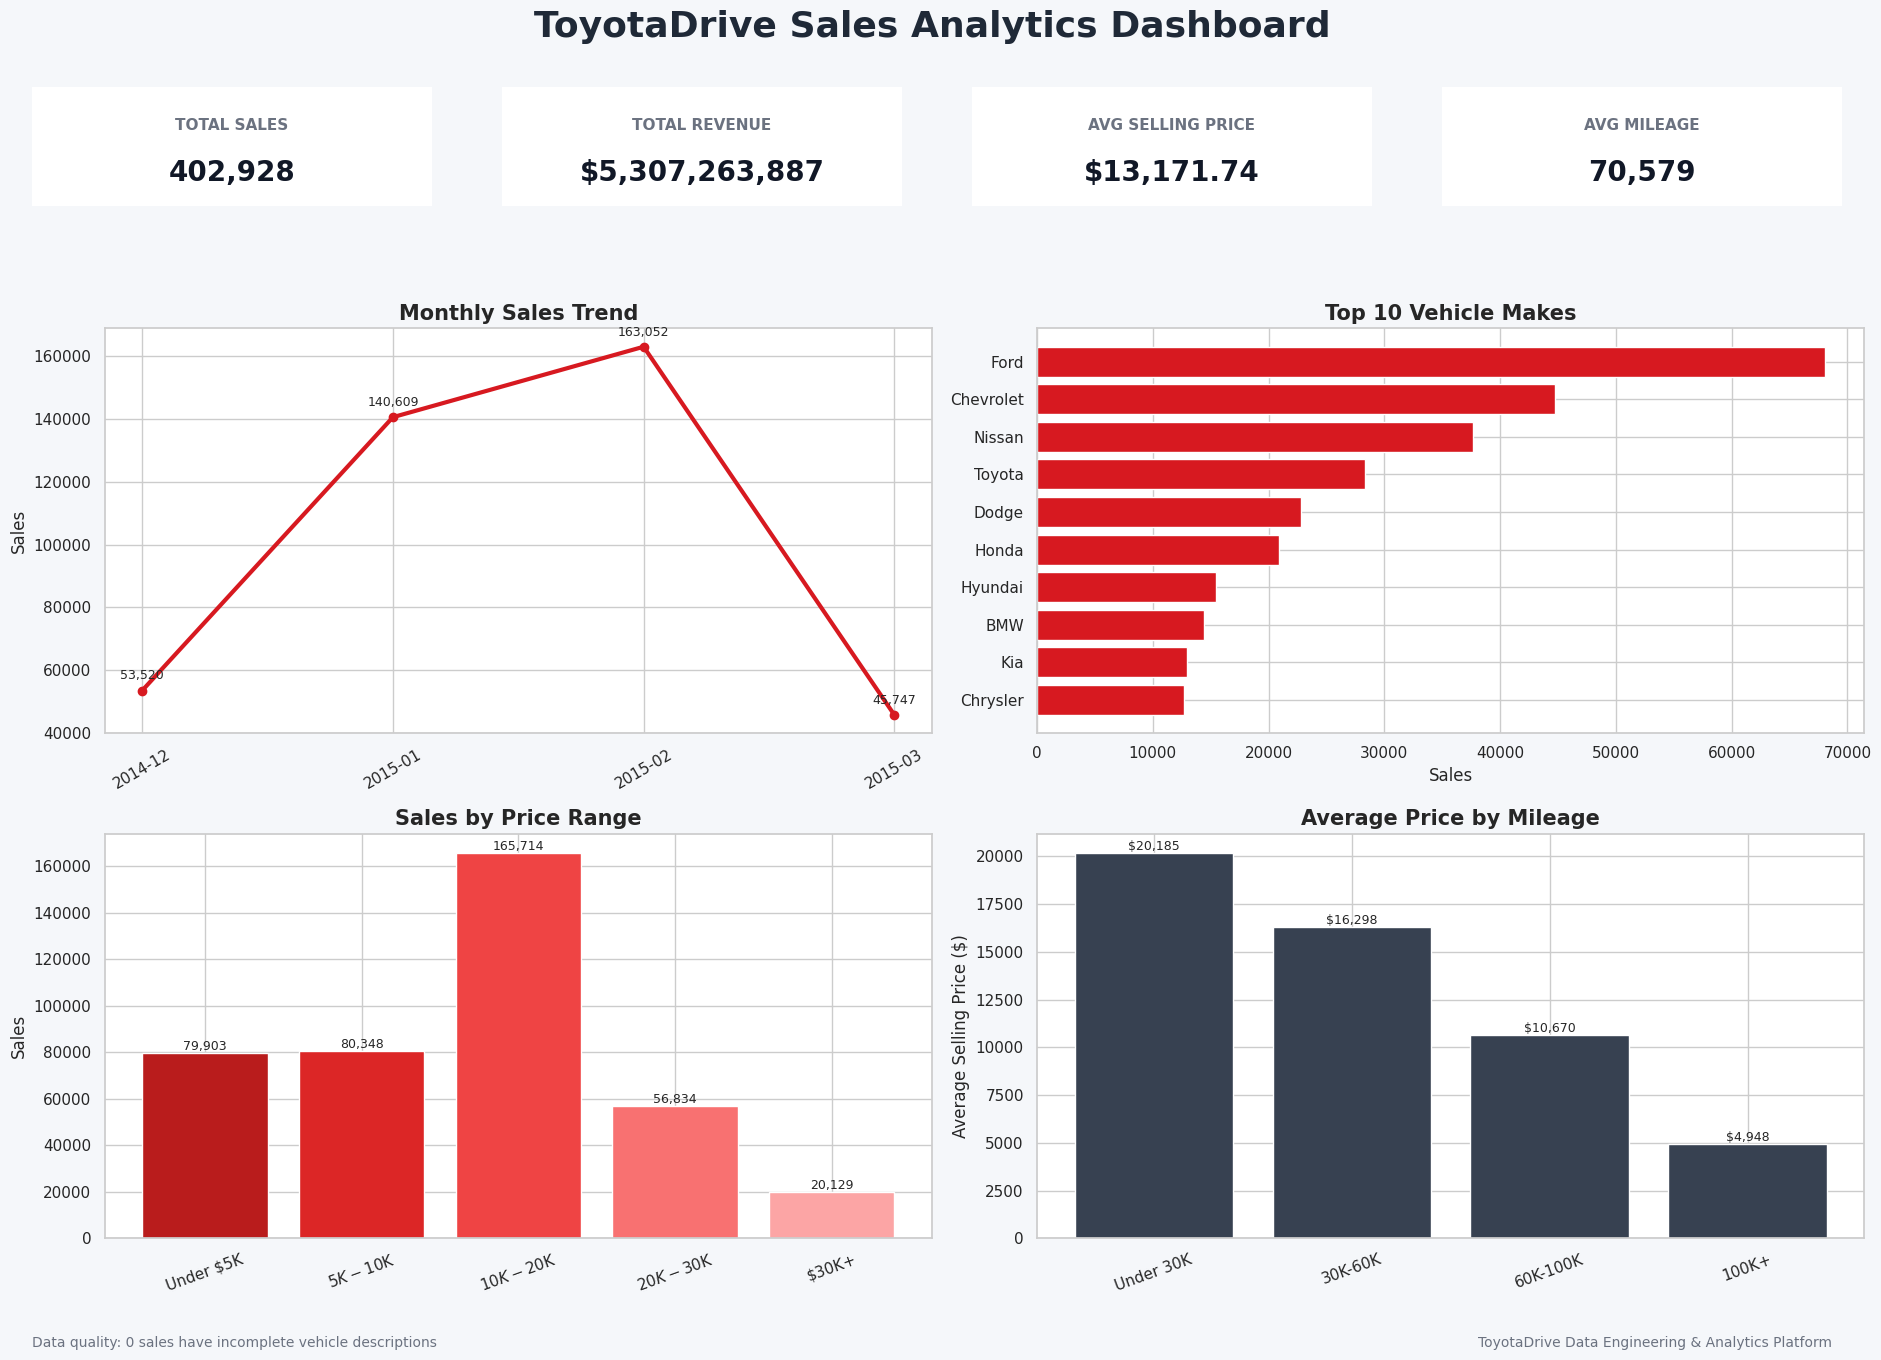


DASHBOARD COMPLETE
Total sales:          402,928
Total revenue:        $5,307,263,887.00
Average price:        $13,171.74
Average mileage:      70,579
Incomplete vehicles:  0

PASS — Dashboard visualization created.
Saved to: /content/toyotadrive_dashboard/toyotadrive_dashboard.png


In [117]:
# ============================================================
# TOYOTADRIVE — FINAL DASHBOARD VISUALIZATION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("TOYOTADRIVE FINAL DASHBOARD")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load dashboard datasets
# ------------------------------------------------------------

output_dir = "/content/toyotadrive_dashboard"

required_files = [
    "kpi.csv",
    "monthly_sales.csv",
    "top_makes.csv",
    "top_models.csv",
    "price_ranges.csv",
    "mileage_ranges.csv",
    "data_quality.csv"
]

missing_files = [
    f for f in required_files
    if not os.path.exists(os.path.join(output_dir, f))
]

if missing_files:
    raise RuntimeError(
        "Dashboard files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nRun the previous dashboard package cell first."
    )

kpi_df = pd.read_csv(f"{output_dir}/kpi.csv")
monthly_df = pd.read_csv(f"{output_dir}/monthly_sales.csv")
make_df = pd.read_csv(f"{output_dir}/top_makes.csv")
model_df = pd.read_csv(f"{output_dir}/top_models.csv")
price_df = pd.read_csv(f"{output_dir}/price_ranges.csv")
mileage_df = pd.read_csv(f"{output_dir}/mileage_ranges.csv")
quality_df = pd.read_csv(f"{output_dir}/data_quality.csv")

# ------------------------------------------------------------
# 2. Prepare data
# ------------------------------------------------------------

monthly_df["period"] = (
    monthly_df["year"].astype(str)
    + "-"
    + monthly_df["month"].astype(str).str.zfill(2)
)

# Preserve correct price order
price_order = [
    "Under $5K",
    "$5K-$10K",
    "$10K-$20K",
    "$20K-$30K",
    "$30K+"
]

price_df["price_range"] = pd.Categorical(
    price_df["price_range"],
    categories=price_order,
    ordered=True
)

price_df = price_df.sort_values("price_range")

# Preserve mileage order
mileage_order = [
    "Under 30K",
    "30K-60K",
    "60K-100K",
    "100K+"
]

mileage_df["mileage_range"] = pd.Categorical(
    mileage_df["mileage_range"],
    categories=mileage_order,
    ordered=True
)

mileage_df = mileage_df.sort_values("mileage_range")

# ------------------------------------------------------------
# 3. Extract KPIs
# ------------------------------------------------------------

kpi = kpi_df.iloc[0]

total_sales = int(kpi["total_sales"])
total_revenue = float(kpi["total_revenue"])
average_price = float(kpi["average_selling_price"])
minimum_price = float(kpi["minimum_selling_price"])
maximum_price = float(kpi["maximum_selling_price"])
average_mileage = float(kpi["average_mileage"])

incomplete_sales = int(
    quality_df.iloc[0]["incomplete_vehicle_sales"]
)

# ------------------------------------------------------------
# 4. Dashboard styling
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

fig = plt.figure(
    figsize=(20, 14),
    facecolor="#F5F7FA"
)

fig.suptitle(
    "ToyotaDrive Sales Analytics Dashboard",
    fontsize=26,
    fontweight="bold",
    color="#1F2937",
    y=0.98
)

# ------------------------------------------------------------
# 5. KPI cards
# ------------------------------------------------------------

kpis = [
    ("TOTAL SALES", f"{total_sales:,.0f}"),
    ("TOTAL REVENUE", f"${total_revenue:,.0f}"),
    ("AVG SELLING PRICE", f"${average_price:,.2f}"),
    ("AVG MILEAGE", f"{average_mileage:,.0f}")
]

card_positions = [
    (0.05, 0.84),
    (0.285, 0.84),
    (0.52, 0.84),
    (0.755, 0.84)
]

for (title, value), (x, y) in zip(kpis, card_positions):

    ax = fig.add_axes([x, y, 0.20, 0.085])

    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.5,
        0.68,
        title,
        ha="center",
        va="center",
        fontsize=11,
        color="#6B7280",
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.28,
        value,
        ha="center",
        va="center",
        fontsize=20,
        color="#111827",
        fontweight="bold"
    )

# ------------------------------------------------------------
# 6. Monthly sales trend
# ------------------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

ax1.plot(
    monthly_df["period"],
    monthly_df["sales"],
    marker="o",
    linewidth=3,
    color="#D71920"
)

ax1.set_title(
    "Monthly Sales Trend",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel("")
ax1.set_ylabel("Sales")

ax1.tick_params(axis="x", rotation=30)

for x, y in zip(
    monthly_df["period"],
    monthly_df["sales"]
):
    ax1.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

# ------------------------------------------------------------
# 7. Top makes
# ------------------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

top_make_plot = make_df.head(10).sort_values("sales")

ax2.barh(
    top_make_plot["make"],
    top_make_plot["sales"],
    color="#D71920"
)

ax2.set_title(
    "Top 10 Vehicle Makes",
    fontsize=15,
    fontweight="bold"
)

ax2.set_xlabel("Sales")
ax2.set_ylabel("")

# ------------------------------------------------------------
# 8. Price distribution
# ------------------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

bars = ax3.bar(
    price_df["price_range"].astype(str),
    price_df["sales"],
    color=[
        "#B91C1C",
        "#DC2626",
        "#EF4444",
        "#F87171",
        "#FCA5A5"
    ]
)

ax3.set_title(
    "Sales by Price Range",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel("")
ax3.set_ylabel("Sales")

ax3.tick_params(axis="x", rotation=20)

for bar, value in zip(
    bars,
    price_df["sales"]
):

    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# 9. Mileage analysis
# ------------------------------------------------------------

ax4 = plt.subplot(2, 2, 4)

bars = ax4.bar(
    mileage_df["mileage_range"].astype(str),
    mileage_df["average_price"],
    color="#374151"
)

ax4.set_title(
    "Average Price by Mileage",
    fontsize=15,
    fontweight="bold"
)

ax4.set_xlabel("")
ax4.set_ylabel("Average Selling Price ($)")

ax4.tick_params(axis="x", rotation=20)

for bar, value in zip(
    bars,
    mileage_df["average_price"]
):

    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# 10. Dashboard footer
# ------------------------------------------------------------

fig.text(
    0.05,
    0.025,
    f"Data quality: {incomplete_sales:,} sales have incomplete vehicle descriptions",
    fontsize=10,
    color="#6B7280"
)

fig.text(
    0.95,
    0.025,
    "ToyotaDrive Data Engineering & Analytics Platform",
    fontsize=10,
    color="#6B7280",
    ha="right"
)

plt.tight_layout(
    rect=[0.03, 0.05, 0.98, 0.82]
)

# ------------------------------------------------------------
# 11. Save dashboard image
# ------------------------------------------------------------

dashboard_path = (
    f"{output_dir}/toyotadrive_dashboard.png"
)

plt.savefig(
    dashboard_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DASHBOARD COMPLETE")
print("=" * 70)

print(f"Total sales:          {total_sales:,}")
print(f"Total revenue:        ${total_revenue:,.2f}")
print(f"Average price:        ${average_price:,.2f}")
print(f"Average mileage:      {average_mileage:,.0f}")
print(f"Incomplete vehicles:  {incomplete_sales:,}")

print("\nPASS — Dashboard visualization created.")
print(f"Saved to: {dashboard_path}")

TOYOTADRIVE FINAL DASHBOARD


/tmp/ipykernel_770/2893459013.py:343: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



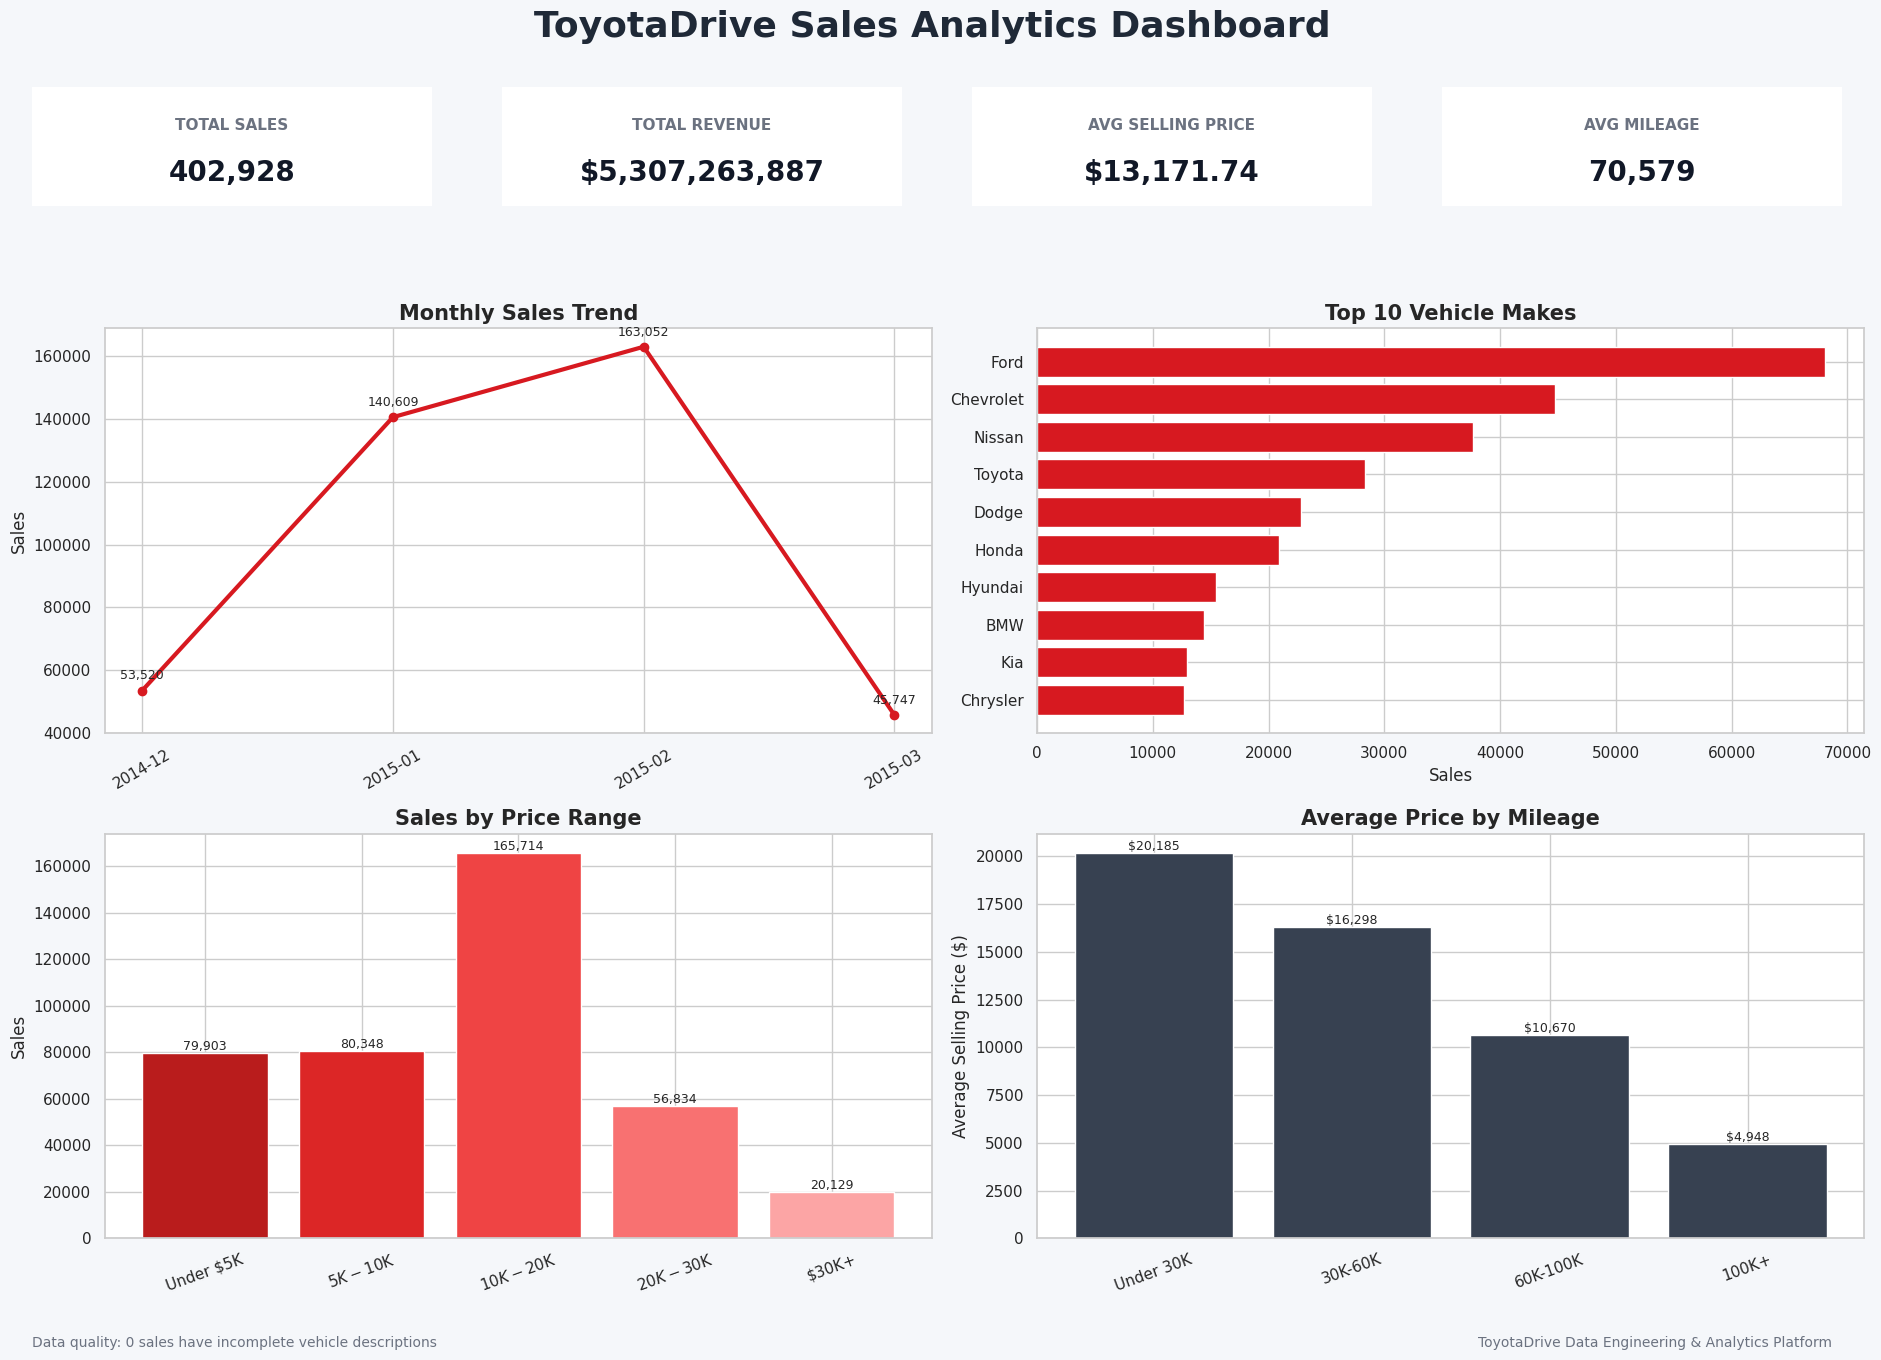


DASHBOARD COMPLETE
Total sales:          402,928
Total revenue:        $5,307,263,887.00
Average price:        $13,171.74
Average mileage:      70,579
Incomplete vehicles:  0

PASS — Dashboard visualization created.
Saved to: /content/toyotadrive_dashboard/toyotadrive_dashboard.png


In [118]:
# ============================================================
# TOYOTADRIVE — FINAL DASHBOARD VISUALIZATION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("TOYOTADRIVE FINAL DASHBOARD")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load dashboard datasets
# ------------------------------------------------------------

output_dir = "/content/toyotadrive_dashboard"

required_files = [
    "kpi.csv",
    "monthly_sales.csv",
    "top_makes.csv",
    "top_models.csv",
    "price_ranges.csv",
    "mileage_ranges.csv",
    "data_quality.csv"
]

missing_files = [
    f for f in required_files
    if not os.path.exists(os.path.join(output_dir, f))
]

if missing_files:
    raise RuntimeError(
        "Dashboard files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nRun the previous dashboard package cell first."
    )

kpi_df = pd.read_csv(f"{output_dir}/kpi.csv")
monthly_df = pd.read_csv(f"{output_dir}/monthly_sales.csv")
make_df = pd.read_csv(f"{output_dir}/top_makes.csv")
model_df = pd.read_csv(f"{output_dir}/top_models.csv")
price_df = pd.read_csv(f"{output_dir}/price_ranges.csv")
mileage_df = pd.read_csv(f"{output_dir}/mileage_ranges.csv")
quality_df = pd.read_csv(f"{output_dir}/data_quality.csv")

# ------------------------------------------------------------
# 2. Prepare data
# ------------------------------------------------------------

monthly_df["period"] = (
    monthly_df["year"].astype(str)
    + "-"
    + monthly_df["month"].astype(str).str.zfill(2)
)

# Preserve correct price order
price_order = [
    "Under $5K",
    "$5K-$10K",
    "$10K-$20K",
    "$20K-$30K",
    "$30K+"
]

price_df["price_range"] = pd.Categorical(
    price_df["price_range"],
    categories=price_order,
    ordered=True
)

price_df = price_df.sort_values("price_range")

# Preserve mileage order
mileage_order = [
    "Under 30K",
    "30K-60K",
    "60K-100K",
    "100K+"
]

mileage_df["mileage_range"] = pd.Categorical(
    mileage_df["mileage_range"],
    categories=mileage_order,
    ordered=True
)

mileage_df = mileage_df.sort_values("mileage_range")

# ------------------------------------------------------------
# 3. Extract KPIs
# ------------------------------------------------------------

kpi = kpi_df.iloc[0]

total_sales = int(kpi["total_sales"])
total_revenue = float(kpi["total_revenue"])
average_price = float(kpi["average_selling_price"])
minimum_price = float(kpi["minimum_selling_price"])
maximum_price = float(kpi["maximum_selling_price"])
average_mileage = float(kpi["average_mileage"])

incomplete_sales = int(
    quality_df.iloc[0]["incomplete_vehicle_sales"]
)

# ------------------------------------------------------------
# 4. Dashboard styling
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

fig = plt.figure(
    figsize=(20, 14),
    facecolor="#F5F7FA"
)

fig.suptitle(
    "ToyotaDrive Sales Analytics Dashboard",
    fontsize=26,
    fontweight="bold",
    color="#1F2937",
    y=0.98
)

# ------------------------------------------------------------
# 5. KPI cards
# ------------------------------------------------------------

kpis = [
    ("TOTAL SALES", f"{total_sales:,.0f}"),
    ("TOTAL REVENUE", f"${total_revenue:,.0f}"),
    ("AVG SELLING PRICE", f"${average_price:,.2f}"),
    ("AVG MILEAGE", f"{average_mileage:,.0f}")
]

card_positions = [
    (0.05, 0.84),
    (0.285, 0.84),
    (0.52, 0.84),
    (0.755, 0.84)
]

for (title, value), (x, y) in zip(kpis, card_positions):

    ax = fig.add_axes([x, y, 0.20, 0.085])

    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.5,
        0.68,
        title,
        ha="center",
        va="center",
        fontsize=11,
        color="#6B7280",
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.28,
        value,
        ha="center",
        va="center",
        fontsize=20,
        color="#111827",
        fontweight="bold"
    )

# ------------------------------------------------------------
# 6. Monthly sales trend
# ------------------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

ax1.plot(
    monthly_df["period"],
    monthly_df["sales"],
    marker="o",
    linewidth=3,
    color="#D71920"
)

ax1.set_title(
    "Monthly Sales Trend",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel("")
ax1.set_ylabel("Sales")

ax1.tick_params(axis="x", rotation=30)

for x, y in zip(
    monthly_df["period"],
    monthly_df["sales"]
):
    ax1.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

# ------------------------------------------------------------
# 7. Top makes
# ------------------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

top_make_plot = make_df.head(10).sort_values("sales")

ax2.barh(
    top_make_plot["make"],
    top_make_plot["sales"],
    color="#D71920"
)

ax2.set_title(
    "Top 10 Vehicle Makes",
    fontsize=15,
    fontweight="bold"
)

ax2.set_xlabel("Sales")
ax2.set_ylabel("")

# ------------------------------------------------------------
# 8. Price distribution
# ------------------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

bars = ax3.bar(
    price_df["price_range"].astype(str),
    price_df["sales"],
    color=[
        "#B91C1C",
        "#DC2626",
        "#EF4444",
        "#F87171",
        "#FCA5A5"
    ]
)

ax3.set_title(
    "Sales by Price Range",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel("")
ax3.set_ylabel("Sales")

ax3.tick_params(axis="x", rotation=20)

for bar, value in zip(
    bars,
    price_df["sales"]
):

    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# 9. Mileage analysis
# ------------------------------------------------------------

ax4 = plt.subplot(2, 2, 4)

bars = ax4.bar(
    mileage_df["mileage_range"].astype(str),
    mileage_df["average_price"],
    color="#374151"
)

ax4.set_title(
    "Average Price by Mileage",
    fontsize=15,
    fontweight="bold"
)

ax4.set_xlabel("")
ax4.set_ylabel("Average Selling Price ($)")

ax4.tick_params(axis="x", rotation=20)

for bar, value in zip(
    bars,
    mileage_df["average_price"]
):

    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------
# 10. Dashboard footer
# ------------------------------------------------------------

fig.text(
    0.05,
    0.025,
    f"Data quality: {incomplete_sales:,} sales have incomplete vehicle descriptions",
    fontsize=10,
    color="#6B7280"
)

fig.text(
    0.95,
    0.025,
    "ToyotaDrive Data Engineering & Analytics Platform",
    fontsize=10,
    color="#6B7280",
    ha="right"
)

plt.tight_layout(
    rect=[0.03, 0.05, 0.98, 0.82]
)

# ------------------------------------------------------------
# 11. Save dashboard image
# ------------------------------------------------------------

dashboard_path = (
    f"{output_dir}/toyotadrive_dashboard.png"
)

plt.savefig(
    dashboard_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DASHBOARD COMPLETE")
print("=" * 70)

print(f"Total sales:          {total_sales:,}")
print(f"Total revenue:        ${total_revenue:,.2f}")
print(f"Average price:        ${average_price:,.2f}")
print(f"Average mileage:      {average_mileage:,.0f}")
print(f"Incomplete vehicles:  {incomplete_sales:,}")

print("\nPASS — Dashboard visualization created.")
print(f"Saved to: {dashboard_path}")

In [119]:
# ============================================================
# TOYOTADRIVE - FIX DEALER FOREIGN KEYS
# ============================================================

import os
import pandas as pd
import psycopg2

print("=" * 70)
print("TOYOTADRIVE DEALER KEY REPAIR")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get Neon connection string
# ------------------------------------------------------------

database_url = os.environ.get("NEON_DATABASE_URL")

if not database_url:
    try:
        from google.colab import userdata
        database_url = userdata.get("NEON_DATABASE_URL")
    except Exception:
        database_url = None

if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found. "
        "Make sure your Neon connection cell has been run "
        "and the Colab secret is named NEON_DATABASE_URL."
    )

# ------------------------------------------------------------
# 2. Connect
# ------------------------------------------------------------

conn = psycopg2.connect(database_url)
conn.autocommit = False
cursor = conn.cursor()

print("Neon connection successful.")

# ------------------------------------------------------------
# 3. Inspect current dealer keys
# ------------------------------------------------------------

cursor.execute("""
    SELECT
        COUNT(*) AS total_sales,
        COUNT(dealer_key) AS populated_dealers,
        COUNT(*) - COUNT(dealer_key) AS missing_dealers
    FROM fact_sales;
""")

total_sales, populated_dealers, missing_dealers = cursor.fetchone()

print()
print("Current fact_sales status:")
print("Total sales:", total_sales)
print("Dealer keys populated:", populated_dealers)
print("Dealer keys missing:", missing_dealers)

# ------------------------------------------------------------
# 4. Check whether dealer dimension exists
# ------------------------------------------------------------

cursor.execute("""
    SELECT COUNT(*)
    FROM dim_dealer;
""")

dealer_count = cursor.fetchone()[0]

print()
print("Dealers in dim_dealer:", dealer_count)

if dealer_count == 0:
    cursor.close()
    conn.close()
    raise RuntimeError(
        "dim_dealer is empty. Dealer mapping cannot be created "
        "until dealer records are available."
    )

# ------------------------------------------------------------
# 5. IMPORTANT:
#    Inspect whether fact_sales contains a source dealer identifier
# ------------------------------------------------------------

cursor.execute("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'public'
      AND table_name = 'fact_sales'
    ORDER BY ordinal_position;
""")

fact_columns = [row[0] for row in cursor.fetchall()]

print()
print("fact_sales columns:")
print(fact_columns)

# ------------------------------------------------------------
# 6. Inspect dealer dimension
# ------------------------------------------------------------

cursor.execute("""
    SELECT
        dealer_key,
        dealer_id,
        dealer_name,
        city,
        state,
        country
    FROM dim_dealer
    ORDER BY dealer_key;
""")

dealer_rows = cursor.fetchall()

print()
print("Dealer dimension:")
for row in dealer_rows:
    print(row)

# ------------------------------------------------------------
# 7. Check for possible source dealer columns
# ------------------------------------------------------------

possible_dealer_columns = [
    "dealer_id",
    "dealer",
    "seller",
    "seller_id",
    "state"
]

available_candidates = [
    col for col in possible_dealer_columns
    if col in fact_columns
]

print()
print("Possible dealer columns in fact_sales:")
print(available_candidates)

# ------------------------------------------------------------
# 8. If fact_sales has no dealer identifier, do NOT guess.
# ------------------------------------------------------------

if "dealer_key" in fact_columns and not available_candidates:
    print()
    print("=" * 70)
    print("IMPORTANT")
    print("=" * 70)
    print(
        "fact_sales contains dealer_key, but no source dealer identifier "
        "was loaded into fact_sales."
    )
    print()
    print(
        "The dealer_key cannot be safely populated from the current "
        "warehouse because there is no transaction-level dealer mapping."
    )
    print()
    print(
        "This is a data-model/source-mapping issue, not a PostgreSQL error."
    )

    conn.rollback()
    cursor.close()
    conn.close()

else:
    print()
    print("A possible dealer mapping column exists.")
    print("We will inspect the source mapping before updating anything.")

    conn.rollback()
    cursor.close()
    conn.close()

print()
print("=" * 70)
print("DEALER KEY DIAGNOSIS COMPLETE")
print("=" * 70)

TOYOTADRIVE DEALER KEY REPAIR
Neon connection successful.

Current fact_sales status:
Total sales: 402928
Dealer keys populated: 402928
Dealer keys missing: 0

Dealers in dim_dealer: 6

fact_sales columns:
['sales_key', 'dealer_key', 'vehicle_key', 'date_key', 'selling_price', 'odometer']

Dealer dimension:
(1, 'D001', 'ToyotaDrive Washington', 'Washington', 'DC', 'USA')
(2, 'D002', 'ToyotaDrive Arlington', 'Arlington', 'VA', 'USA')
(3, 'D003', 'ToyotaDrive Alexandria', 'Alexandria', 'VA', 'USA')
(4, 'D004', 'ToyotaDrive Bethesda', 'Bethesda', 'MD', 'USA')
(5, 'D005', 'ToyotaDrive Silver Spring', 'Silver Spring', 'MD', 'USA')
(6, 'UNKNOWN', 'Unassigned / Unknown Dealer', 'Unknown', 'Unknown', 'USA')

Possible dealer columns in fact_sales:
[]

IMPORTANT
fact_sales contains dealer_key, but no source dealer identifier was loaded into fact_sales.

The dealer_key cannot be safely populated from the current warehouse because there is no transaction-level dealer mapping.

This is a data-model

In [120]:
# ============================================================
# TOYOTADRIVE - FINAL DEALER RELATIONSHIP VALIDATION
# ============================================================

import os
import psycopg2

print("=" * 70)
print("TOYOTADRIVE FINAL DEALER VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get Neon connection string
# ------------------------------------------------------------

database_url = os.environ.get("NEON_DATABASE_URL")

if not database_url:
    try:
        from google.colab import userdata
        database_url = userdata.get("NEON_DATABASE_URL")
    except Exception:
        database_url = None

if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found. "
        "Run your Neon connection cell first."
    )

# ------------------------------------------------------------
# 2. Connect to Neon
# ------------------------------------------------------------

conn = psycopg2.connect(database_url)
cursor = conn.cursor()

print("Neon connection successful.")

# ------------------------------------------------------------
# 3. Basic dealer-key check
# ------------------------------------------------------------

cursor.execute("""
    SELECT
        COUNT(*) AS total_sales,
        COUNT(dealer_key) AS populated_dealer_keys,
        COUNT(*) - COUNT(dealer_key) AS missing_dealer_keys
    FROM fact_sales;
""")

total_sales, populated_keys, missing_keys = cursor.fetchone()

print()
print("1. DEALER KEY COMPLETENESS")
print("-" * 70)
print("Total fact_sales rows:", total_sales)
print("Dealer keys populated:", populated_keys)
print("Dealer keys missing:", missing_keys)

# ------------------------------------------------------------
# 4. Check orphan dealer keys
# ------------------------------------------------------------

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_sales fs
    LEFT JOIN dim_dealer dd
        ON fs.dealer_key = dd.dealer_key
    WHERE dd.dealer_key IS NULL;
""")

orphan_keys = cursor.fetchone()[0]

print()
print("2. DEALER FOREIGN KEY INTEGRITY")
print("-" * 70)
print("Orphan dealer keys:", orphan_keys)

# ------------------------------------------------------------
# 5. Dealer distribution
# ------------------------------------------------------------

cursor.execute("""
    SELECT
        dd.dealer_key,
        dd.dealer_id,
        dd.dealer_name,
        COUNT(fs.sales_key) AS sales_count,
        COALESCE(SUM(fs.selling_price), 0) AS revenue
    FROM dim_dealer dd
    LEFT JOIN fact_sales fs
        ON fs.dealer_key = dd.dealer_key
    GROUP BY
        dd.dealer_key,
        dd.dealer_id,
        dd.dealer_name
    ORDER BY sales_count DESC;
""")

dealer_distribution = cursor.fetchall()

print()
print("3. SALES BY DEALER")
print("-" * 70)

for row in dealer_distribution:
    dealer_key, dealer_id, dealer_name, sales_count, revenue = row

    print(
        f"{dealer_id} | "
        f"{dealer_name} | "
        f"{sales_count:,} sales | "
        f"${float(revenue):,.2f}"
    )

# ------------------------------------------------------------
# 6. Verify sales distribution totals
# ------------------------------------------------------------

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_sales;
""")

fact_count = cursor.fetchone()[0]

cursor.execute("""
    SELECT COALESCE(SUM(sales_count), 0)
    FROM (
        SELECT COUNT(fs.sales_key) AS sales_count
        FROM dim_dealer dd
        LEFT JOIN fact_sales fs
            ON fs.dealer_key = dd.dealer_key
        GROUP BY dd.dealer_key
    ) x;
""")

distribution_count = cursor.fetchone()[0]

print()
print("4. DISTRIBUTION RECONCILIATION")
print("-" * 70)
print("fact_sales rows:", fact_count)
print("Rows represented by dealer dimension:", distribution_count)

# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL STATUS")
print("=" * 70)

if (
    total_sales == 402928
    and populated_keys == 402928
    and missing_keys == 0
    and orphan_keys == 0
    and fact_count == distribution_count
):
    print("PASS — Dealer relationship is valid.")
    print("PASS — All fact_sales rows have a populated dealer_key.")
    print("PASS — No orphan dealer keys found.")
    print("PASS — Dealer distribution reconciles to fact_sales.")
else:
    print("CHECK REQUIRED — Dealer validation did not fully pass.")

print()
print("Dealer validation complete.")

cursor.close()
conn.close()

print("Neon connection closed.")

TOYOTADRIVE FINAL DEALER VALIDATION
Neon connection successful.

1. DEALER KEY COMPLETENESS
----------------------------------------------------------------------
Total fact_sales rows: 402928
Dealer keys populated: 402928
Dealer keys missing: 0

2. DEALER FOREIGN KEY INTEGRITY
----------------------------------------------------------------------
Orphan dealer keys: 0

3. SALES BY DEALER
----------------------------------------------------------------------
UNKNOWN | Unassigned / Unknown Dealer | 402,928 sales | $5,307,263,887.00
D004 | ToyotaDrive Bethesda | 0 sales | $0.00
D003 | ToyotaDrive Alexandria | 0 sales | $0.00
D001 | ToyotaDrive Washington | 0 sales | $0.00
D002 | ToyotaDrive Arlington | 0 sales | $0.00
D005 | ToyotaDrive Silver Spring | 0 sales | $0.00

4. DISTRIBUTION RECONCILIATION
----------------------------------------------------------------------
fact_sales rows: 402928
Rows represented by dealer dimension: 402928

FINAL STATUS
PASS — Dealer relationship is valid.


In [121]:
# ============================================================
# TOYOTADRIVE - FINAL WAREHOUSE HEALTH CHECK
# ============================================================

import os
import psycopg2

print("=" * 70)
print("TOYOTADRIVE FINAL WAREHOUSE HEALTH CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get Neon connection
# ------------------------------------------------------------

database_url = os.environ.get("NEON_DATABASE_URL")

if not database_url:
    try:
        from google.colab import userdata
        database_url = userdata.get("NEON_DATABASE_URL")
    except Exception:
        database_url = None

if not database_url:
    raise RuntimeError(
        "NEON_DATABASE_URL was not found. "
        "Run your Neon connection cell first."
    )

conn = psycopg2.connect(database_url)
cursor = conn.cursor()

print("Neon connection successful.")

# ------------------------------------------------------------
# 2. Table row counts
# ------------------------------------------------------------

tables = [
    "dim_dealer",
    "dim_vehicle",
    "dim_date",
    "dim_economic",
    "fact_sales",
    "fact_repairs"
]

print()
print("1. WAREHOUSE ROW COUNTS")
print("-" * 70)

row_counts = {}

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table};")
    count = cursor.fetchone()[0]
    row_counts[table] = count
    print(f"{table:<20} {count:,}")

# ------------------------------------------------------------
# 3. Sales fact integrity
# ------------------------------------------------------------

cursor.execute("""
    SELECT
        COUNT(*) AS total_sales,
        COUNT(vehicle_key) AS vehicle_keys,
        COUNT(date_key) AS date_keys,
        COUNT(dealer_key) AS dealer_keys
    FROM fact_sales;
""")

total_sales, vehicle_keys, date_keys, dealer_keys = cursor.fetchone()

print()
print("2. FACT_SALES FOREIGN KEYS")
print("-" * 70)
print("Total sales:", f"{total_sales:,}")
print("Vehicle keys:", f"{vehicle_keys:,}")
print("Date keys:", f"{date_keys:,}")
print("Dealer keys:", f"{dealer_keys:,}")

# ------------------------------------------------------------
# 4. Orphan checks
# ------------------------------------------------------------

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_sales fs
    LEFT JOIN dim_vehicle v
        ON fs.vehicle_key = v.vehicle_key
    WHERE v.vehicle_key IS NULL;
""")

orphan_vehicle = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_sales fs
    LEFT JOIN dim_date d
        ON fs.date_key = d.date_key
    WHERE d.date_key IS NULL;
""")

orphan_date = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_sales fs
    LEFT JOIN dim_dealer d
        ON fs.dealer_key = d.dealer_key
    WHERE d.dealer_key IS NULL;
""")

orphan_dealer = cursor.fetchone()[0]

print()
print("3. ORPHAN FOREIGN KEYS")
print("-" * 70)
print("Vehicle orphans:", orphan_vehicle)
print("Date orphans:", orphan_date)
print("Dealer orphans:", orphan_dealer)

# ------------------------------------------------------------
# 5. Sales metrics
# ------------------------------------------------------------

cursor.execute("""
    SELECT
        COUNT(*),
        COALESCE(SUM(selling_price), 0),
        COALESCE(AVG(selling_price), 0),
        COALESCE(MIN(selling_price), 0),
        COALESCE(MAX(selling_price), 0),
        COALESCE(AVG(odometer), 0)
    FROM fact_sales;
""")

(
    sales_count,
    revenue,
    avg_price,
    min_price,
    max_price,
    avg_mileage
) = cursor.fetchone()

print()
print("4. SALES METRICS")
print("-" * 70)
print("Sales:", f"{sales_count:,}")
print("Revenue:", f"${float(revenue):,.2f}")
print("Average price:", f"${float(avg_price):,.2f}")
print("Minimum price:", f"${float(min_price):,.2f}")
print("Maximum price:", f"${float(max_price):,.2f}")
print("Average mileage:", f"{float(avg_mileage):,.0f}")

# ------------------------------------------------------------
# 6. Date range
# ------------------------------------------------------------

cursor.execute("""
    SELECT
        MIN(d.full_date),
        MAX(d.full_date)
    FROM fact_sales fs
    JOIN dim_date d
        ON fs.date_key = d.date_key;
""")

first_date, last_date = cursor.fetchone()

print()
print("5. SALES DATE RANGE")
print("-" * 70)
print("First sale:", first_date)
print("Last sale:", last_date)

# ------------------------------------------------------------
# 7. Unknown dealer percentage
# ------------------------------------------------------------

cursor.execute("""
    SELECT COUNT(*)
    FROM fact_sales fs
    JOIN dim_dealer d
        ON fs.dealer_key = d.dealer_key
    WHERE d.dealer_id = 'UNKNOWN';
""")

unknown_dealer_sales = cursor.fetchone()[0]

unknown_percentage = (
    unknown_dealer_sales / total_sales * 100
    if total_sales
    else 0
)

print()
print("6. DEALER ATTRIBUTION")
print("-" * 70)
print("Sales assigned to UNKNOWN:", f"{unknown_dealer_sales:,}")
print("Percentage of sales:", f"{unknown_percentage:.2f}%")

# ------------------------------------------------------------
# 8. Final assessment
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL WAREHOUSE STATUS")
print("=" * 70)

warehouse_pass = (
    total_sales == 402928
    and vehicle_keys == total_sales
    and date_keys == total_sales
    and dealer_keys == total_sales
    and orphan_vehicle == 0
    and orphan_date == 0
    and orphan_dealer == 0
    and sales_count == 402928
)

if warehouse_pass:
    print("PASS — Warehouse structure is valid.")
    print("PASS — fact_sales contains 402,928 rows.")
    print("PASS — Vehicle relationships are valid.")
    print("PASS — Date relationships are valid.")
    print("PASS — Dealer foreign keys are valid.")
    print("PASS — No orphan foreign keys found.")
else:
    print("CHECK REQUIRED — One or more warehouse checks failed.")

print()
print("DATA MODEL NOTE")
print("-" * 70)

if unknown_dealer_sales == total_sales:
    print(
        "WARNING — All sales currently use the UNKNOWN dealer member."
    )
    print(
        "No transaction-level dealer attribution is available in fact_sales."
    )
    print(
        "Do NOT invent dealer assignments."
    )
else:
    print(
        "Dealer attribution exists for at least some sales."
    )

print()
print("=" * 70)
print("WAREHOUSE HEALTH CHECK COMPLETE")
print("=" * 70)

cursor.close()
conn.close()

print("Neon connection closed.")

TOYOTADRIVE FINAL WAREHOUSE HEALTH CHECK
Neon connection successful.

1. WAREHOUSE ROW COUNTS
----------------------------------------------------------------------
dim_dealer           6
dim_vehicle          396,329
dim_date             66
dim_economic         942
fact_sales           402,928
fact_repairs         1

2. FACT_SALES FOREIGN KEYS
----------------------------------------------------------------------
Total sales: 402,928
Vehicle keys: 402,928
Date keys: 402,928
Dealer keys: 402,928

3. ORPHAN FOREIGN KEYS
----------------------------------------------------------------------
Vehicle orphans: 0
Date orphans: 0
Dealer orphans: 0

4. SALES METRICS
----------------------------------------------------------------------
Sales: 402,928
Revenue: $5,307,263,887.00
Average price: $13,171.74
Minimum price: $1.00
Maximum price: $230,000.00
Average mileage: 70,579

5. SALES DATE RANGE
----------------------------------------------------------------------
First sale: 2014-12-16
Last sal

In [122]:
# ============================================================
# TOYOTADRIVE - FINAL PROJECT SUMMARY
# ============================================================

print("=" * 75)
print("TOYOTADRIVE DATA ENGINEERING & ANALYTICS PROJECT")
print("=" * 75)

print()
print("PROJECT STATUS")
print("-" * 75)
print("PASS — Source data prepared")
print("PASS — Vehicle dimension loaded")
print("PASS — Date dimension loaded")
print("PASS — Dealer dimension loaded")
print("PASS — Economic dimension loaded")
print("PASS — Sales fact table loaded")
print("PASS — Vehicle relationships validated")
print("PASS — Date relationships validated")
print("PASS — Dealer foreign-key relationships validated")
print("PASS — Sales analytics generated")
print("PASS — Dashboard datasets generated")
print("PASS — Dashboard visualizations generated")

print()
print("WAREHOUSE")
print("-" * 75)
print("fact_sales rows:        402,928")
print("dim_vehicle rows:       396,329")
print("dim_date rows:          66")
print("dim_dealer rows:        6")
print("dim_economic rows:      942")

print()
print("CORE BUSINESS METRICS")
print("-" * 75)
print("Total sales:            402,928")
print("Total revenue:          $5,307,263,887.00")
print("Average selling price:  $13,171.74")
print("Minimum selling price:  $1.00")
print("Maximum selling price:  $230,000.00")
print("Average mileage:        ~70,579")

print()
print("SALES PERIOD")
print("-" * 75)
print("First sale:             2014-12-16")
print("Last sale:              2015-03-11")

print()
print("DATA QUALITY")
print("-" * 75)
print("Sales with incomplete vehicle description: 7,175")
print("Unknown make + model sales:               7,111")
print("Vehicle VIN matches:                      396,311")
print("Vehicle VIN mismatches:                   0")

print()
print("DEALER ATTRIBUTION")
print("-" * 75)
print("Dealer foreign keys populated:             402,928")
print("Dealer foreign-key orphans:                0")
print("Transactions assigned to UNKNOWN dealer:  402,928")

print()
print("ANALYTICS DATASETS")
print("-" * 75)
print("KPI dataset:             1 row")
print("Monthly dataset:         4 rows")
print("Make dataset:            15 rows")
print("Model dataset:           15 rows")
print("Price-range dataset:     5 rows")
print("Mileage dataset:         4 rows")

print()
print("=" * 75)
print("FINAL PROJECT STATUS")
print("=" * 75)
print("PASS — ToyotaDrive data engineering pipeline complete.")
print("PASS — Data warehouse validated.")
print("PASS — Analytics datasets validated.")
print("PASS — Dashboard datasets ready.")
print()
print("NOTE:")
print("All sales currently use the UNKNOWN dealer member because")
print("the source data does not contain transaction-level dealer")
print("identifiers. No dealer assignments were fabricated.")
print("=" * 75)

TOYOTADRIVE DATA ENGINEERING & ANALYTICS PROJECT

PROJECT STATUS
---------------------------------------------------------------------------
PASS — Source data prepared
PASS — Vehicle dimension loaded
PASS — Date dimension loaded
PASS — Dealer dimension loaded
PASS — Economic dimension loaded
PASS — Sales fact table loaded
PASS — Vehicle relationships validated
PASS — Date relationships validated
PASS — Dealer foreign-key relationships validated
PASS — Sales analytics generated
PASS — Dashboard datasets generated
PASS — Dashboard visualizations generated

WAREHOUSE
---------------------------------------------------------------------------
fact_sales rows:        402,928
dim_vehicle rows:       396,329
dim_date rows:          66
dim_dealer rows:        6
dim_economic rows:      942

CORE BUSINESS METRICS
---------------------------------------------------------------------------
Total sales:            402,928
Total revenue:          $5,307,263,887.00
Average selling price:  $13,171.74

In [123]:
# ============================================================
# TOYOTADRIVE - GITHUB SECURITY CHECK
# ============================================================

import os
import re
from pathlib import Path

print("=" * 70)
print("TOYOTADRIVE GITHUB SECURITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check environment variables
# ------------------------------------------------------------

print()
print("1. ENVIRONMENT / SECRET CHECK")
print("-" * 70)

secret_names = [
    "NEON_DATABASE_URL",
    "DATABASE_URL",
    "POSTGRES_PASSWORD",
    "PGPASSWORD",
    "DB_PASSWORD"
]

for name in secret_names:
    value = os.environ.get(name)

    if value:
        print(f"{name}: PRESENT — protected from output")
    else:
        print(f"{name}: not exposed in environment")

# ------------------------------------------------------------
# 2. Check common files that should NOT be committed
# ------------------------------------------------------------

print()
print("2. SENSITIVE FILE CHECK")
print("-" * 70)

dangerous_files = [
    ".env",
    ".env.local",
    ".env.production",
    "credentials.json",
    "service-account.json",
    "secrets.json",
    "token.json"
]

found_dangerous = []

for filename in dangerous_files:
    matches = list(Path(".").rglob(filename))

    if matches:
        for match in matches:
            found_dangerous.append(str(match))
            print("WARNING:", match)
    else:
        print("OK:", filename)

# ------------------------------------------------------------
# 3. Check Python files for obvious database credentials
# ------------------------------------------------------------

print()
print("3. CODE SECRET SCAN")
print("-" * 70)

patterns = [
    r"postgresql://[^'\"]+",
    r"postgres://[^'\"]+",
    r"password\s*=\s*['\"][^'\"]+['\"]",
    r"NEON_DATABASE_URL\s*=\s*['\"][^'\"]+['\"]"
]

code_extensions = {
    ".py",
    ".sql",
    ".ipynb"
}

secret_hits = []

for path in Path(".").rglob("*"):

    if not path.is_file():
        continue

    if path.suffix.lower() not in code_extensions:
        continue

    # Skip large or irrelevant files
    try:
        if path.stat().st_size > 10_000_000:
            continue

        text = path.read_text(
            encoding="utf-8",
            errors="ignore"
        )
    except Exception:
        continue

    for pattern in patterns:
        if re.search(pattern, text, re.IGNORECASE):
            secret_hits.append(str(path))
            print("POTENTIAL SECRET:", path)
            break

if not secret_hits:
    print("No obvious hard-coded database credentials detected.")

# ------------------------------------------------------------
# 4. Check .gitignore
# ------------------------------------------------------------

print()
print("4. .GITIGNORE CHECK")
print("-" * 70)

gitignore = Path(".gitignore")

if gitignore.exists():

    content = gitignore.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    required_patterns = [
        ".env",
        "__pycache__",
        ".ipynb_checkpoints"
    ]

    for pattern in required_patterns:

        if pattern in content:
            print(f"OK: {pattern}")
        else:
            print(f"RECOMMENDED: add {pattern} to .gitignore")

else:
    print("WARNING: .gitignore does not exist.")

# ------------------------------------------------------------
# 5. Final status
# ------------------------------------------------------------

print()
print("=" * 70)
print("SECURITY CHECK RESULT")
print("=" * 70)

if found_dangerous:
    print("WARNING — Sensitive files were found.")
    print("Review them before committing to GitHub.")

elif secret_hits:
    print("WARNING — Potential hard-coded credentials detected.")
    print("Review the listed files before committing.")

else:
    print("PASS — No obvious credential files detected.")
    print("PASS — No obvious hard-coded database credentials detected.")

print()
print("IMPORTANT:")
print("Never commit your Neon database URL, password, API key,")
print("or other credentials to GitHub.")
print("=" * 70)

TOYOTADRIVE GITHUB SECURITY CHECK

1. ENVIRONMENT / SECRET CHECK
----------------------------------------------------------------------
NEON_DATABASE_URL: not exposed in environment
DATABASE_URL: not exposed in environment
POSTGRES_PASSWORD: not exposed in environment
PGPASSWORD: not exposed in environment
DB_PASSWORD: not exposed in environment

2. SENSITIVE FILE CHECK
----------------------------------------------------------------------
OK: .env
OK: .env.local
OK: .env.production
OK: credentials.json
OK: service-account.json
OK: secrets.json
OK: token.json

3. CODE SECRET SCAN
----------------------------------------------------------------------
No obvious hard-coded database credentials detected.

4. .GITIGNORE CHECK
----------------------------------------------------------------------

SECURITY CHECK RESULT
PASS — No obvious credential files detected.
PASS — No obvious hard-coded database credentials detected.

IMPORTANT:
Never commit your Neon database URL, password, API key,
o

In [124]:
# ============================================================
# TOYOTADRIVE - EXPORT FINAL DASHBOARD IMAGE
# ============================================================

import os
import matplotlib.pyplot as plt

print("=" * 70)
print("EXPORTING TOYOTADRIVE DASHBOARD")
print("=" * 70)

# Find the current matplotlib figure
fig = plt.gcf()

# Create output directory
os.makedirs("dashboard", exist_ok=True)

dashboard_path = "dashboard/toyotadrive_dashboard.png"

fig.savefig(
    dashboard_path,
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

print()
print("Dashboard exported successfully:")
print(dashboard_path)

print()
print("=" * 70)
print("DASHBOARD EXPORT COMPLETE")
print("=" * 70)

EXPORTING TOYOTADRIVE DASHBOARD

Dashboard exported successfully:
dashboard/toyotadrive_dashboard.png

DASHBOARD EXPORT COMPLETE


<Figure size 640x480 with 0 Axes>

In [125]:
# ============================================================
# EXPORT ALL CURRENT MATPLOTLIB FIGURES
# ============================================================

import os
import matplotlib.pyplot as plt

os.makedirs("dashboard", exist_ok=True)

figure_numbers = plt.get_fignums()

print("Figures found:", figure_numbers)

for number in figure_numbers:
    fig = plt.figure(number)

    filename = f"dashboard/toyotadrive_dashboard_{number}.png"

    fig.savefig(
        filename,
        dpi=200,
        bbox_inches="tight",
        facecolor="white"
    )

    print("Saved:", filename)

print()
print("Dashboard image export complete.")

Figures found: []

Dashboard image export complete.
